# Uncertainties in the sub-grid transport of CO2 in IFS


In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import pandas as pd
import re
import numpy as np
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import pint
from pint import UnitRegistry
ureg = UnitRegistry()
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor

In [2]:
dir_in       = "/perm/paaa/IFS/netherlands"
dir_obs         = "/perm/paaa/observations"
dir_out       = "/perm/paaa/images/CATRINE"


# # name | dir | label
# exp_names = [
#     ('ctrl'     , 'itvc_ctrl_flxntend'       ,  'Control'),
#     # ('TKE'      , 'iupe_TKE_flxntend'        ,  'TKE'),
#     # ('dryMF'    , 'iu8c_dryMF_flxntend'      ,  'dry MF'),
#     # ('reorder'  , 'ius9_reorder_flxntend'    ,  'reorder'),
#     # ('TKEv2'    , 'ivps_TKEv2_flxntend'        ,  'TKEv2'),
#     ('ctrl_9km' , 'ivln_9km_flxntend'   ,  'Control 9 km'),
#     ('ctrl_49r2b','iyw7_ctrl_49r2b'   ,  'Control 49r2b'),
#     ('half_diffusion','j1kz_half_ZCFC_everywhere_49r2b'   ,  'Half diffusion'),
#     ('half_diff_stable','j1m9_half_ZCFC_everywhere_stable_49r2b'   ,  'Half diff stable'),
#     ('half_diff_unstable','j1rv_half_ZCFC_inABL_unstable_49r2b'   ,  'Half diff unstable') 
# ]
# nemo_exp_names = [
#     ('SPP_all',     'iqpa_SPP_noIC'       , 'SPP all'   , 'grey'),
#     ('SPP_conv',    'iqs0_SPP_noIC_conv'  , 'SPP conv'  , 'red'),
#     ('SPP_diff',    'issq_SPP_noIC_turb'  , 'SPP turb'  , 'green'),
#     ('SPP_rad',     'issr_SPP_noIC_rad'   , 'SPP rad'   , 'blue'),
# ]

exp_names = [
    # ('ctrl'                 , 'itvc_ctrl_flxntend'                      , '49r1 tco399'                 ,'#7C1472'),
    # ('ctrl_9km'             , 'ivln_9km_flxntend'                       , '49r1 tco1279 '               ,'#06CA8C'),

    ('ctrl_49r2b'               , 'iyw7_ctrl_49r2b'                         , 'Control'                     ,'#D04848'),
    ('9km_49r2b'                , 'j1rw_9km_49r2b'                          , 'Hres_9km'                     ,"#07AD78"),
    # ('dryMF_arctan'             , 'j5tj_dryMF_arctan'                       , 'dryMF'                       ,'#7C1471'), # not extracted yet
    # ('half_diffusion'           , 'j1kz_half_ZCFC_everywhere_49r2b'         , '0.5 diff'                    ,'#6895D2'),
    ('half_diff_stable'         , 'j1m9_half_ZCFC_everywhere_stable'        , 'Red_diff_stab'            ,'#F3B95F'),
    ('half_diff_unstable'       , 'j1t7_half_ZCFC_everywhere_notStable'     , 'Red_diff_nonstab'          ,"#72E9F9"),
    # ('half_diff_unstable_abl'   , 'j1rv_half_ZCFC_inABL_notStable'          , '0.5 diff, unstable,\ninABL ' ,'#59981A')
    
]


nemo_exp_names = [
    ('SPP_all'               , 'j4it_SPP_all'                            , 'SPP all'              ,'grey'), 
    ('SPP_turb'              , 'j6d0_SPP_turb'                           , 'SPP turb'             ,'blue'), 
    ('SPP_rkap'              , 'j6d5_SPP_rkap'                           , 'SPP rkap'             ,'green'), 

]

sty = ['-','--',':', '-.']

In [3]:
levels = ['z','srf']
lead_time = 0 # do you want to analayse FC day1 (leasd_time = 0) or FC day2 (leasd_time = 24) ? 

str_time = '2022-05-15T03:00'
end_time = '2022-05-21T02:00'

UTC_to_LT = +2 #hours from UTC

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")

cabauw ={
        "lat": 51.971,
        "lon": 4.927,
        "z": [5, 60, 100, 180]
    }

loobos ={
        "lat": 52.166,
        "lon": 5.744,
        "z": [24]
    }

day_hours   = [8, 19]
night_hours = [8, 20]

In [4]:
#####  open input to DALES #####
dir_in_dales = '/perm/paaa/Les/Cases/Catrine/Martin/'
## input 
input = xr.open_mfdataset(dir_in_dales+'input/les_input_catrine_15_18.nc')
input['time'] = input['time'] + np.timedelta64(2,'h')

input['wspd'] = np.sqrt(input['u']**2 + input['v']**2)  # wind speed in m/s
input['wdir'] = np.arctan2(input['v'], input['u'])

In [5]:

#####################
### DALES profiles ###
dir_dales       = "/perm/paaa/Les/Cases/Catrine/Arseni"

files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'profiles' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_prof    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':1000})#.sel(time=slice(str_time,end_time))
dales_prof['time'] = dales_prof['time'].astype('datetime64[ns]') - np.timedelta64(1,'D') + np.timedelta64(UTC_to_LT,'h')
dales_prof = dales_prof.sel(time=slice(str_time,end_time))
## Interpolate half levels to full levels
for var in dales_prof.data_vars:
    if 'zm' in dales_prof[var].coords:
        # Interpolate the variable along the 'zm' coordinate
        dales_prof[var] = dales_prof[var].interp(zm=dales_prof.zt)
    
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_prof[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_prof[var]/1000000) # ????????
        dales_prof[var+'_ppm'].attrs['units'] = 'PPM'
        dales_prof[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# Drop the unnecessary dimensions and coordinates
dales_prof = dales_prof.drop_dims(["zm"])
dales_prof = dales_prof.sel(zt=slice(0,7000))
dales_prof_hr = dales_prof.resample(time='1h',label='left').mean().chunk({'time':-1,'zt':-1})


#####################
### DALES 3d fields ###
## domain limit:

files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'loobos_' in f and '_3d' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_3d    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':24,'zt':4,'xt':-1,'yt':-1})
# convert UTC to local time (+2 hours)
dales_3d['time'] = dales_3d['time'].astype('datetime64[ns]') + np.timedelta64(2,'D') + np.timedelta64(UTC_to_LT,'h')
dales_3d = dales_3d.sel(time=slice(str_time,end_time))

for var in dales_3d.data_vars:
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_3d[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_3d[var]/1000000) # ???????
        dales_3d[var+'_ppm'].attrs['units'] = 'PPM'
        dales_3d[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# Select tower location
dales_cabauw = dales_3d.where((dales_3d['lat']>cabauw['lat']-0.005).compute() & (dales_3d['lat']<cabauw['lat']+0.005).compute() &
                          (dales_3d['lon']>cabauw['lon']-0.005).compute() & (dales_3d['lon']<cabauw['lon']+0.005).compute(),drop=True)

dales_3d_loobos = dales_3d.where((dales_3d['lat']>loobos['lat']-0.005).compute() & (dales_3d['lat']<loobos['lat']+0.005).compute() &
                          (dales_3d['lon']>loobos['lon']-0.005).compute() & (dales_3d['lon']<loobos['lon']+0.005).compute(),drop=True)

dales_2d    = dales_3d.mean(('xt','yt'))
dales_2d = dales_2d.chunk({'time':-1,'zt':-1})
dales_cabauw    = dales_cabauw.mean(('xt','yt'))
dales_3d_loobos = dales_3d_loobos.mean(('xt','yt'))

Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/profiles.001.nc']
Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv004_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_buoy_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_thl_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_w_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_v_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv001_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_u_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv002_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_ql_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_loobos_sv003_3d.nc']


In [6]:
##### open new Areseni's DALES #####

# ## import DALES profile at Loobos from 3d for qt
# ## import DALES profiles at Loobos from 3d for ta
# # convert ta to th using presh at cener of domain already in dales_prof. 
# #  
# dales_qt = xr.open_dataset(f"{dir_dales}/ruisdael_domain_dales_3d_16_18_05_2022_100m_qt.nc")
# dales_ta = xr.open_dataset(f"{dir_dales}/ruisdael_domain_dales_3d_16_18_05_2022_100m_ta.nc")

# dales_qt_cabauw = dales_qt.where((dales_qt['lat']>cabauw['lat']-0.005).compute() & (dales_qt['lat']<cabauw['lat']+0.005).compute() &
#                           (dales_qt['lon']>cabauw['lon']-0.005).compute() & (dales_qt['lon']<cabauw['lon']+0.005).compute(),drop=True)
# dales_ta_cabauw = dales_ta.where((dales_ta['lat']>cabauw['lat']-0.005).compute() & (dales_ta['lat']<cabauw['lat']+0.005).compute() &
#                           (dales_ta['lon']>cabauw['lon']-0.005).compute() & (dales_ta['lon']<cabauw['lon']+0.005).compute(),drop=True)

# dales_qt_loobos = dales_qt.where((dales_qt['lat']>loobos['lat']-0.005).compute() & (dales_qt['lat']<loobos['lat']+0.005).compute() &
#                           (dales_qt['lon']>loobos['lon']-0.005).compute() & (dales_qt['lon']<loobos['lon']+0.005).compute(),drop=True)
# dales_ta_loobos = dales_ta.where((dales_ta['lat']>loobos['lat']-0.005).compute() & (dales_ta['lat']<loobos['lat']+0.005).compute() &
#                           (dales_ta['lon']>loobos['lon']-0.005).compute() & (dales_ta['lon']<loobos['lon']+0.005).compute(),drop=True)

# dales_ta_loobos = dales_ta_loobos.mean(('xt','yt'))
# dales_qt_loobos = dales_qt_loobos.mean(('xt','yt'))

# dales_ta_cabauw = dales_ta_cabauw.mean(('xt','yt'))
# dales_qt_cabauw = dales_qt_cabauw.mean(('xt','yt'))

# dales_ta_loobos['th'] = mfun.calc_th(dales_ta_loobos['ta'],dales_prof['presh'])
# dales_ta_cabauw['th'] = mfun.calc_th(dales_ta_cabauw['ta'],dales_prof['presh'])

In [7]:
def interp_pblh(Ri, zt, threshold=0.25):
    # Difference from threshold
    diff = Ri - threshold

    # Condition: Ri > 0.25
    mask = diff > 0

    # Find index along zt where Ri first exceeds threshold
    ri_ind = mask.argmax(dim="zt")

    # Gather values just before and after the threshold crossing
    ri_low = Ri.isel(zt=ri_ind - 1)
    ri_high = Ri.isel(zt=ri_ind)

    zt_low = zt.isel(zt=ri_ind - 1)
    zt_high = zt.isel(zt=ri_ind)

    # Linear interpolation to where Ri == threshold
    pblh = zt_low + (zt_high - zt_low) * ((threshold - ri_low) / (ri_high - ri_low))

    return pblh

In [8]:
#### Not accurate! you need the surface values! this lowest level is about 12 m ####
thv_surf = dales_prof_hr['thv'].sel(zt=0,method='nearest') +2.5 ####?????????????
z_surf  = dales_prof_hr['zt'].sel(zt=0,method='nearest') -10
u_surf  = dales_prof_hr['u'].sel(zt=0,method='nearest') *0.2
v_surf  = dales_prof_hr['v'].sel(zt=0,method='nearest') *0.2
####################

num = mfun.g/(thv_surf) * (dales_prof_hr['thv'] - (thv_surf)) * (dales_prof_hr['zt']-(z_surf))
den = (dales_prof_hr['u'] - (u_surf))**2 + (dales_prof_hr['v'] - (v_surf))**2

# num = mfun.g/dales_prof_hr['thv'] * (dales_prof_hr['thv'].diff('zt')) * (dales_prof_hr['zt'].diff('zt'))
# den = (dales_prof_hr['u'].diff('zt'))**2 + (dales_prof_hr['v'].diff('zt'))**2

Ri  = num/den 

pblh = interp_pblh(Ri.compute(),dales_prof_hr['zt'],0.25)

pblh['time'] = pblh['time'].astype('datetime64[ns]') + np.timedelta64(3,'h')

In [9]:
#####  open IFS forecasts #####

# map dataset categories to filename suffix
categories = {
    "":        "_processed.nc",   # 3D + surface full datasets
    "slab":    "_slab.nc",
    "cabauw":  "_cabauw.nc",
    "loobos":  "_loobos.nc",
}

# initialise dictionaries
IFS = {cat: {"z": {}, "srf": {}} for cat in categories}

for exp, exp_longname, _,_ in exp_names:
    for cat, suffix in categories.items():
        tag = f"t{lead_time}{suffix}"
        for level in ["z", "srf"]:
            files = [
                os.path.join(dir_in, "fc", f)
                for f in os.listdir(os.path.join(dir_in, "fc"))
                if exp_longname + f"_{level}" in f and f.endswith(tag)
            ]
            print(f"Reading {cat or 'processed'} {level} files:")
            print(files)
            IFS[cat][level][exp] = xr.open_mfdataset(files, combine="by_coords")
            IFS[cat][level][exp] = IFS[cat][level][exp].sel(time=slice(t0, t1))
            # remove time duplicates (required for .sel(..., method="nearest"))
            if "time" in IFS[cat][level][exp].dims:
                IFS[cat][level][exp] = IFS[cat][level][exp].sortby("time")
                _t_index = IFS[cat][level][exp].indexes.get("time")
                if _t_index is not None and not _t_index.is_unique:
                    IFS[cat][level][exp] = IFS[cat][level][exp].isel(time=~_t_index.duplicated())
            if level == 'z':
                IFS[cat][level][exp]['th'] = mfun.calc_th(IFS[cat][level][exp]['t'],IFS[cat][level][exp]['p'])
                IFS[cat][level][exp]['thl'] = mfun.calc_thl(IFS[cat][level][exp]['th'],IFS[cat][level][exp]['clwc'],IFS[cat][level][exp]['p'])
                
            

Reading processed z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_processed.nc']
Reading processed srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_processed.nc']
Reading slab z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_slab.nc']
Reading slab srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_slab.nc']
Reading cabauw z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_cabauw.nc']
Reading cabauw srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_cabauw.nc']
Reading loobos z files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_z_t0_loobos.nc']
Reading loobos srf files:
['/perm/paaa/IFS/netherlands/fc/iyw7_ctrl_49r2b_srf_t0_loobos.nc']
Reading processed z files:
['/perm/paaa/IFS/netherlands/fc/j1rw_9km_49r2b_z_t0_processed.nc']
Reading processed srf files:
['/perm/paaa/IFS/netherlands/fc/j1rw_9km_49r2b_srf_t0_processed.nc']
Reading slab z files:
['/perm/paaa/IFS/netherlands/fc/j1rw_9km_49r2b_z_t0_sl

In [10]:
## If you still need to deaccumulate or process something....

# ds_z_slab['uflx_conv'] = mfun.deacc_variable(ds_z_slab['uflx_conv'],restart=1)
# ds_z_slab['uflx_diff'] = mfun.deacc_variable(ds_z_slab['uflx_diff'],restart=1)
# ds_z_slab['uflx_dyn'] = mfun.deacc_variable(ds_z_slab['uflx_dyn'],restart=1)


for exp, _, _,_ in exp_names:
    for cat, suffix in categories.items():
        # rename temperature 
        if 't' in IFS[cat]['z'][exp].data_vars:
            IFS[cat]['z'][exp] = IFS[cat]['z'][exp].rename({'t':'T'})
        # for var in ['u','v','T','q','co2','ch4']:
        for var in ['u','v','T','q','co2']:
            IFS[cat]['z'][exp][f'd{var}dt_tot'].attrs = IFS['slab']['z'][exp][f'd{var}dt_dyn'].attrs.copy()
        
        # if co2_flx_dyn is avaiable rename it as co2flx_dyn
        try:
            ds = IFS[cat]['z'][exp]
            if 'co2_flx_dyn' in ds.data_vars:
                ds = ds.rename({'co2_flx_dyn': 'co2flx_dyn'})
                IFS[cat]['z'][exp] = ds
        except KeyError:
            print(f"co2flx_dyn {exp} already named.")

        # for var in IFS[cat]['z'][exp].data_vars:
        #     if 'co2flx' in var:
        #         old_units = IFS['slab']['z'][exp][var].attrs['units']
        #         print(exp,cat, var, old_units)
                # IFS[cat]['z'][exp][var] = mfun.concentration_to_ppm('co2', IFS[cat]['z'][exp][var] / 1000)
                # IFS[cat]['z'][exp][var].attrs['units'] = old_units.replace('g', 'PPM')

In [11]:
## compute tendency as difference between final and intial co2 profiles
for var in ['u','v','T','q','co2','ch4']:
    for exp, exp_longname, label,_ in exp_names:
     IFS['slab']['z'][exp][f'd{var}dt_diff_check'] = (IFS['slab']['z'][exp][var].diff('time') / 1)#hr   # in ppm/hour

In [12]:
#####  open IFS nemo experiments #####
IFS_nemo = {cat: {"z": {}, "srf": {}} for cat in categories}

for exp, exp_longname, _, _ in nemo_exp_names:
    for cat, suffix in categories.items():
        tag = f"t{lead_time}{suffix}"
        for level in ["z", "srf"]:
            files = [
                os.path.join(dir_in, "pf", f)
                for f in os.listdir(os.path.join(dir_in, "pf"))
                if exp_longname + f"_{level}" in f and f.endswith(tag)
            ]
            print(f"Reading {cat or 'processed'} {level} files:")
            print(files)
            IFS_nemo[cat][level][exp] = xr.open_mfdataset(files, combine="by_coords")
            IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].sel(time=slice(t0, t1))
            # remove time duplicates (required for .sel(..., method="nearest"))
            if "time" in IFS_nemo[cat][level][exp].dims:
                IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].sortby("time")
                _t_index = IFS_nemo[cat][level][exp].indexes.get("time")
                if _t_index is not None and not _t_index.is_unique:
                    IFS_nemo[cat][level][exp] = IFS_nemo[cat][level][exp].isel(time=~_t_index.duplicated())
            if level =='z':    
                IFS_nemo[cat][level][exp]['co2_ppm'] = mfun.concentration_to_ppm('co2',IFS_nemo[cat][level][exp]['co2'])



Reading processed z files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_z_t0_processed.nc']
Reading processed srf files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_srf_t0_processed.nc']
Reading slab z files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_z_t0_slab.nc']
Reading slab srf files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_srf_t0_slab.nc']
Reading cabauw z files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_z_t0_cabauw.nc']
Reading cabauw srf files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_srf_t0_cabauw.nc']
Reading loobos z files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_z_t0_loobos.nc']
Reading loobos srf files:
['/perm/paaa/IFS/netherlands/pf/j4it_SPP_all_srf_t0_loobos.nc']
Reading processed z files:
['/perm/paaa/IFS/netherlands/pf/j6d0_SPP_turb_z_t0_processed.nc']
Reading processed srf files:
['/perm/paaa/IFS/netherlands/pf/j6d0_SPP_turb_srf_t0_processed.nc']
Reading slab z files:
['/perm/paaa/IFS/netherlands/pf/j6d0_SPP_turb_z_t0_slab.nc']
Reading slab srf fi

In [13]:
################
#####  OPEN OBSERVATIONS #####
################

#### CABAUW ####
################
ds_cabauw = {}

cabauw_heights = np.array([27, 67, 127, 207])
cabauw_heights_da = xr.DataArray(cabauw_heights, dims=["cabauw_height"])

print('-- Cabauw datasets --')

# 1) #######################
####  obs_surf_flx  ####
########################
# Surface
print ('Dataset name: obs_surf_flx')
obs_name = "cesar_surface_flux"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_surf_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_surf_flx['time'] = obs_surf_flx['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
ds_cabauw['obs_surf_flx'] = obs_surf_flx.resample(time='1h',label='right').mean()  ## Label right or left??????
################################################

# 2) ########################
####  obs_tower_flx  ####
#########################
# Tower
print ('Dataset name: obs_tower_flx')
obs_name = "cesar_tower_flux"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_flx    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
# obs_tower_flx['time'] = obs_tower_flx['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
# obs_tower_flx = obs_tower_flx.resample(time='1h',label='right').mean()  ## Label right or left??????
ds_cabauw['obs_tower_flx'] = obs_tower_flx.rolling(time=6, center=True).mean()
################################################


# 3) ############################
####  Cabauw_CO2_May2022 ####
#############################
### import CO2 concentration ## 
file = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if 'CO2' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[30:-4])
# Read the first two rows separately
headers =  pd.read_csv(file, nrows=1).columns.tolist()

# Read the actual data, skipping the units row
df = pd.read_csv(file)
df.columns.values[0] = "time"
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()
for var in ds.variables:
    if var =='time':
        continue
    elif 'flag' in var:
        ds[var].attrs["units"] = ''
    else: 
        ds[var].attrs["units"] = 'PPM'
# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(UTC_to_LT,'h') # to LT (CEST)
# # Now you can assign it to your dict:
ds_cabauw[file[30:-4]] = ds
################################################

# 1) #######################
####  obs_tower_meteo  ####
########################
# Surface
print ('Dataset name: obs_tower_meteo')
obs_name = "cesar_tower_meteo"
datestamp = "2022"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and datestamp in f and f.endswith('.nc')]
obs_tower_meteo    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))
# convert UTC to local time (+2 hours)
obs_tower_meteo['time'] = obs_tower_meteo['time'].astype('datetime64[ns]') + np.timedelta64(UTC_to_LT,'h')
ds_cabauw['obs_tower_meteo'] = obs_tower_meteo.resample(time='1h',label='right').mean()  ## Label right or left??????
################################################



# 4) #######################
#### BLH StratFinder ####
#
obs_name = "eprofile_L2B_STRATFINDER_cabauw_chm15k-A_v01_2022_15min"
files = [os.path.join(dir_obs+'/Cesar', f) for f in os.listdir(dir_obs+'/Cesar') if f.startswith(obs_name) and f.endswith('.nc')]
blh_cabauw    = xr.open_mfdataset(files,combine='by_coords').sel(time=slice(str_time,end_time))


Dataset name: obs_surf_flx


Dataset name: obs_tower_flx
Dataset name: Cabauw_CO2_May2022
Dataset name: obs_tower_meteo


In [14]:
# List the levels you want to process
levels = ['27m', '67m', '127m', '207m']

for lvl in levels:
    co2_var = f'co2_{lvl}'
    flag_var = f'co2_flag_{lvl}'
    
    # Mask with NaN where flag is 'N'
    ds_cabauw['Cabauw_CO2_May2022'][co2_var] = ds_cabauw['Cabauw_CO2_May2022'][co2_var].where(
        ds_cabauw['Cabauw_CO2_May2022'][flag_var] != 'N'
    )

# Convert direction to radians
theta = np.deg2rad(ds_cabauw['obs_tower_meteo']['D'])
# Optionally, add to dataset
ds_cabauw['obs_tower_meteo']['u'] = -ds_cabauw['obs_tower_meteo']['F']  * np.sin(theta)  # zonal wind (positive eastward)
ds_cabauw['obs_tower_meteo']['v'] = -ds_cabauw['obs_tower_meteo']['F']  * np.cos(theta)  # meridional wind (positive northward)

In [15]:
# -- Compute CO2 gradient from observations
ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'] = xr.full_like(ds_cabauw['Cabauw_CO2_May2022']['time'], fill_value=np.nan, dtype=np.float64)
for time in ds_cabauw['Cabauw_CO2_May2022']['time']:
    x= np.array([ds_cabauw['Cabauw_CO2_May2022']['co2_27m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_67m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_127m'].sel(time=time),
                 ds_cabauw['Cabauw_CO2_May2022']['co2_207m'].sel(time=time)])
    # Mask NaNs
    mask = ~np.isnan(x) & ~np.isnan(cabauw_heights)
    x_clean = x[mask]
    y_clean = cabauw_heights[mask]

    # Only fit if at least 3 points remain
    if len(x_clean) >= 3:
        ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'].loc[time] = np.polyfit(x_clean, y_clean, 1)[0]
    else:
        ds_cabauw['Cabauw_CO2_May2022']['co2_gradient'].loc[time] = np.nan

In [16]:
# Vars you should consider using:
# Friction velocity (ds_cabauw['obs_tower_flx']['USA005])
# CO2 flux (ds_cabauw['obs_tower_flx']['WC005'])
# Specific humidity flux (ds_cabauw['obs_tower_flx']['WQ005'])
# CO2 density flux (ds_cabauw['obs_tower_flx']['FC005'])

In [94]:
#### LOOBOS ####
################
def csv_to_xarray(path: str) -> xr.Dataset:
    """
    Read a CSV where:
      - Row 1 is header
      - Col 1 ignored
      - Col 2 is date (dimension 'date')
      - Col 3 is height Alt (dimension 'Alt')
      - Col 4 is the data variable (uses its header as the variable name)
    Returns an xarray.Dataset with dims ('date', 'Alt').
    """
    # Read full CSV to keep the real header names
    df = pd.read_csv(path, header=0)

    # Grab the name of the 4th column to preserve the variable's real name
    var_name = df.columns[3]

    # Keep only columns 2,3,4 and normalize names
    df = df.iloc[:, [1, 2, 3]].copy()
    df.columns = ['date', 'Alt', var_name]

    # Parse types
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['Alt'] = pd.to_numeric(df['Alt'], errors='coerce')
    df[var_name] = pd.to_numeric(df[var_name], errors='coerce')

    # Drop rows with missing dimension coords
    df = df.dropna(subset=['date', 'Alt'])
    df = df.drop_duplicates(keep="first")
    # Set index for conversion to xarray
    # df = df.set_index(['date', 'Alt']).sort_index()
    df = df.set_index(['date']).sort_index()


    # Convert to xarray (DataArray) then to Dataset
    # da = df[var_name].to_xarray()
    # ds = da.to_dataset(name=var_name)

    ds = df.to_xarray()
    # ds = da.to_dataset(name=var_name)

    return ds

obs_name = "Loobos_"

files = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if f.startswith(obs_name) and f.endswith('.csv')]

ds_loobos = {}
print('-- Loobos datasets --')
for file in files:
    print ('Dataset name: '+file[38:-4])
    # print(file)
    if file[38:-4] in ['Aircraft_morn_flux','Aircraft_aft_flux']:
        print('skipping '+file[38:-4]+' for now, need to check the format')
        continue
    # loobos[file[38:-4]] = pd.read_csv(file,skiprows=[1])
    # loobos[file[38:-4]] = loobos[file[38:-4]].to_xarray()

    # First row for headers
    skiprows = 0
    headers = pd.read_csv(file, nrows=0).columns.tolist()
    if file[38:-4] in ['Meteorology','Loobos_Fluxes','Air_Quality','Fluxes']:
        skiprows = 1
        # some files have units in the second row, so we read them separately
        units = pd.read_csv(file, nrows=1).iloc[0].tolist()
    if file[38:-4] in ['Aircraft_co2_mol',]:
        ds = csv_to_xarray(file)
        ds_loobos[file[38:-4]] = ds
        continue

    # Read the actual data, skipping the units row
    df = pd.read_csv(file, skiprows=skiprows)

    # Set correct headers
    df.columns = headers

    # Convert to xarray
    ds = df.to_xarray()

    if skiprows == 1:
        # Assign units as attributes to the DataArray variables
        for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
            if var_name in ds:
                ds[var_name].attrs["units"] = unit
    # Optional: parse the time if it's not already datetime
 
    ds["time"] = pd.to_datetime(df[df.columns[0]])
    
    ds['index'] = ds['time']
    
    ds = ds.drop_vars('time')
    ds = ds.drop_vars('dim_0')
    ds = ds.rename({'index': 'time'})
    ds = ds.set_coords("time")
    # ds = ds.rename({'dim_0': 'index'})
    ds = ds.swap_dims({'dim_0': 'time'})
    # Now you can assign it to your dict:
    ds_loobos[file[38:-4]] = ds

mmgas=44.0095
ds_loobos['Fluxes']['co2_flux'] = ds_loobos['Fluxes']['co2_flux'] * (mmgas/10**3 ) # mmgas=44.0095 g/mol
ds_loobos['Fluxes']['co2_flux'].attrs['units'] = 'mg m-2 s-1'

-- Loobos datasets --
Dataset name: Meteorology
/perm/paaa/observations/Loobos/Loobos_Meteorology.csv
Dataset name: Tower_co2_flux
/perm/paaa/observations/Loobos/Loobos_Tower_co2_flux.csv
Dataset name: airsamples_O2_CO2
/perm/paaa/observations/Loobos/Loobos_airsamples_O2_CO2.csv
Dataset name: Aircraft_morn_flux
/perm/paaa/observations/Loobos/Loobos_Aircraft_morn_flux.csv
skipping Aircraft_morn_flux for now, need to check the format
Dataset name: Air_Quality
/perm/paaa/observations/Loobos/Loobos_Air_Quality.csv
Dataset name: Fluxes
/perm/paaa/observations/Loobos/Loobos_Fluxes.csv
Dataset name: airsamples_vertical_all
/perm/paaa/observations/Loobos/Loobos_airsamples_vertical_all.csv
Dataset name: Aircraft_co2_mol
/perm/paaa/observations/Loobos/Loobos_Aircraft_co2_mol.csv
Dataset name: Aircraft_aft_flux
/perm/paaa/observations/Loobos/Loobos_Aircraft_aft_flux.csv
skipping Aircraft_aft_flux for now, need to check the format


In [18]:
### import BLH ## 
file = [os.path.join(dir_obs+'/Loobos', f) for f in os.listdir(dir_obs+'/Loobos') if 'BLH' in f and f.endswith('.csv')][0]
print ('Dataset name: '+file[31:-4])
# Read the first two rows separately
headers = ['time','BLH_radio','BLH_plane']
units   = ['','m','m']

# Read the actual data, skipping the units row
df = pd.read_csv(file)

# # Set correct headers
df.columns = headers
df = df.set_index("time")

# # Convert to xarray
ds = df.to_xarray()

# Assign units as attributes to the DataArray variables
for var_name, unit in zip(headers[1:], units[1:]):  # skip Timestamp
    if var_name in ds:
        ds[var_name].attrs["units"] = unit

# # Optional: parse the time if it's not already datetime
ds["time"] = pd.to_datetime(df.index) + np.timedelta64(1, 'h') # convert to LT (CEST)

# # Now you can assign it to your dict:
ds_loobos[file[31:-4]] = ds

Dataset name: BLH


In [19]:
## define legs within the flights in Aircraft_co2_mol. Each leg is either ascending or descending, and you can use the time limits to select the corresponding data for comparison with the model.
legs = {
    # 17 May
    'leg1' : ('2022-05-17T06:30', '2022-05-17T06:40'),
    'leg2' : ('2022-05-17T06:40', '2022-05-17T07:30'),
    'leg3' : ('2022-05-17T08:00', '2022-05-17T08:50'),
    'leg4' : ('2022-05-17T11:50', '2022-05-17T12:10'),
    'leg5' : ('2022-05-17T12:10', '2022-05-17T12:35'),
    'leg6' : ('2022-05-17T14:00', '2022-05-17T14:20'),
    # 18 May
    'leg7' : ('2022-05-18T06:30', '2022-05-18T06:45'),
    'leg8' : ('2022-05-18T06:45', '2022-05-18T07:05'),
    'leg9' : ('2022-05-18T07:55', '2022-05-18T08:10'),
    'leg10': ('2022-05-18T11:35', '2022-05-18T11:58'),
    'leg11': ('2022-05-18T11:58', '2022-05-18T12:20'),
    'leg12': ('2022-05-18T13:40', '2022-05-18T14:15'),
}

# Precompute mid-times (used for both per-leg and mean profiles)
leg_names = [leg for leg in list(legs.keys()) if leg != 'leg6']

midd_times = {
    leg: pd.to_datetime(legs[leg][0])
    + (pd.to_datetime(legs[leg][1]) - pd.to_datetime(legs[leg][0])) / 2
    for leg in leg_names
}

In [20]:
temp_radio = {}
files = [os.path.join(dir_obs, "Loobos/Radiosondes", f) 
         for f in os.listdir(os.path.join(dir_obs, "Loobos/Radiosondes")) 
         if f.endswith(".csv")]

# define a standard pressure grid
p_grid = np.arange(101700, 47912, -20)
z_grid = np.arange(0, 7000, 5)  # standard height grid in meters

vertical_coordinate = "Height" # or "Pressure", depending on your choice

for file in files:
    # --- extract time from filename ---
    fname = os.path.basename(file).replace(".edited.csv", "")
    # e.g. 2022-05-17_0656_0456UTC
    match = re.match(r"(\d{4}-\d{2}-\d{2})_(\d{4})", fname)
    if match:
        date, hhmm = match.groups()
        file_time = pd.to_datetime(f"{date} {hhmm}", format="%Y-%m-%d %H%M")
    else:
        file_time = pd.NaT  # fallback

    print("Dataset name:", fname, "time:", file_time)

    # --- read the CSV ---
    df = pd.read_csv(file)
    df = df.drop(df.columns[0], axis=1)
    273,15

    if vertical_coordinate == "Pressure":
        ## option 1
        # --- use Pressure as vertical coordinate ---
        df = df.set_index(" Pressure (Pascal)")
        ds = df.to_xarray()
        ds = ds.rename({" Pressure (Pascal)": "Pressure"})  # cleaner name
        ds['Pressure'].attrs["units"] = 'Pa'
        # --- average duplicates along Pressure
        ds_avg = ds.groupby("Pressure").mean(dim="Pressure", skipna=True)
        ds_avg = ds_avg.sortby("Pressure", ascending=False)  # descending for vertical
        # --- interpolate to the standard pressure grid ---
        ds_interp = ds_avg.interp(Pressure=p_grid,kwargs={"fill_value": np.nan})
    elif vertical_coordinate == "Height":
        ## option 2
        # --- use Altitude as vertical coordinate ---
        df = df.set_index("Altitude (m MSL)")
        ds = df.to_xarray()
        ds = ds.rename({"Altitude (m MSL)": "Height"})  # cleaner name
        ds['Height'].attrs["units"] = 'm'
        # --- average duplicates along Pressure
        ds_avg = ds.groupby("Height").mean(dim="Height", skipna=True)
        ds_avg = ds_avg.sortby("Height", ascending=False)  # descending for vertical
        # --- interpolate to the standard pressure grid ---
        ds_interp = ds_avg.interp(Height=z_grid,kwargs={"fill_value": np.nan})

    # --- add time as a new dimension ---
    ds_interp = ds_interp.expand_dims("time").assign_coords(time=[file_time])

    # --- (optional) split variable names and units ---
    for column in df.columns:
        if "(" in column and ")" in column:
            name, unit = column.split("(", 1)
            name, unit = name.strip(), unit.strip(") ")
            ds_interp = ds_interp.rename({column: name})
            ds_interp[name].attrs["units"] = unit

    temp_radio[fname] = ds_interp

loobos_radio = xr.concat(temp_radio.values(), dim="time")
loobos_radio = loobos_radio.sortby("time")

## fix some variables
loobos_radio['T'] = loobos_radio['Temperature'] + 273.15  # convert to Kelvin
loobos_radio['T'].attrs["units"] = 'K'
loobos_radio['u'] = -loobos_radio['u']
loobos_radio['v'] = -loobos_radio['v']

Dataset name: 2022-05-18_0707_0507UTC time: 2022-05-18 07:07:00


Dataset name: 2022-05-17_1449_1249UTC time: 2022-05-17 14:49:00
Dataset name: 2022-05-17_0925_0725UTC time: 2022-05-17 09:25:00
Dataset name: 2022-05-17_1825_1625UTC time: 2022-05-17 18:25:00
Dataset name: 2022-05-18_1804_1604UTC time: 2022-05-18 18:04:00
Dataset name: 2022-05-17_1122_0922UTC time: 2022-05-17 11:22:00
Dataset name: 2022-05-18_1530_1330UTC time: 2022-05-18 15:30:00
Dataset name: 2022-05-17_0656_0456UTC time: 2022-05-17 06:56:00
Dataset name: 2022-05-18_1253_1053UTC time: 2022-05-18 12:53:00
Dataset name: 2022-05-18_0916_0716UTC time: 2022-05-18 09:16:00
Dataset name: 2022-05-17_1319_1119UTC time: 2022-05-17 13:19:00


In [21]:
# --------------------------------------------
# Helper functions
# --------------------------------------------
def get_closest_height(available_heights, target_height):
    """Find the closest model height to a given target height."""
    return available_heights[np.abs(available_heights - target_height).argmin()]

def shade_daytime(ax, time_array, start_hour=None, end_hour=None, color='lightgrey', alpha=0.3):
    """Add shaded regions for daytime periods between start_hour and end_hour."""
    if start_hour is None: start_hour = night_hours[0]
    if end_hour   is None: end_hour   = night_hours[1]
    # Convert to pandas DatetimeIndex (ensures easy handling of days)
    times = pd.to_datetime(time_array)
    unique_days = np.unique(times.date)

    for day in unique_days:
        start = pd.Timestamp(day) + pd.Timedelta(hours=start_hour)
        end = pd.Timestamp(day) + pd.Timedelta(hours=end_hour)
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)  # behind the data

def concentration_to_ppm(gas,concentration):
    """
    Convert concentration of co2 to ppm 
    Input:
         gas = name of the gas 
         concentration    = concentration in g/g
    """
    if gas == 'co2':
        mmgas=44.0095 # g/mol
    elif gas =='ra':
        mmgas=222 # g/mol
    elif gas =='ch4':
        mmgas=16.04 # g/mol
    else:
        raise ValueError("Gas wrongly specified or not known.")
    
    mmair=28.9644 #g/mol # assumption of dry air
    ppm = 10**6 *concentration * mmair/mmgas 
    return ppm

## PLOTTING

In [ ]:
#####  Evolution of Standard variables at 100m at Cabauw  #####
################################################################

# add latent heat flux for an idea of surface stability 
# add shaded areas for nighttime 
# add a thick vertical line for times with flight legs (if desired)

######################################################
def nee_in_ppm(exp, var='fco2nee'):
    old_units = IFS['']['srf'][exp]['fco2nee'].attrs['units']

    # lnsp is logarithm of surface pressure, so exp(lnsp) gives surface pressure in Pa. To convert to hPa, divide by 100.
    p_surf = np.exp(IFS['cabauw']['z'][exp]['lnsp'])

    if 'kg m**-2 s**-1' in old_units:
        print(f"converting {old_units} to PPM m/s for variable {var}, assumption on (surface?) density, careful!")
        # rho = mfun.calc_rho(p_surf,ds['t'],ds['q']/1000)#kg/m3
        rho=1.245#kg/m3
        # print(f"rho near the surface: {rho.sel(height=0,method='nearest').isel(time=1).values}")
        IFS['cabauw']['srf'][exp][f'{var}_ppm'] = mfun.concentration_to_ppm('co2', IFS['cabauw']['srf'][exp][var]/rho)
        IFS['cabauw']['srf'][exp][f'{var}_ppm'].attrs['units'] = old_units.replace('kg m**-2$', 'PPM m/s')
    return IFS['cabauw']['srf'][exp][f'{var}_ppm']
######################################################

# plot_exps = [ '9km_49r2b','ctrl_49r2b','half_diff_stable']  # experiments to plot
plot_exps = ['ctrl_49r2b','9km_49r2b']  # experiments to plot

for exp in plot_exps:
    IFS['cabauw']['srf'][exp]['fco2nee_ppm']=nee_in_ppm(exp, var='fco2nee')



location = 'cabauw'
add_loobos = True
sel_z = 200 #m
# Include 'NEE' as the last variable
vars = ['T', 'q', 'u', 'v', 'co2', 'fco2nee']
vars = ['T', 'q', 'u', 'v', 'fco2nee', 'H']
fig, axes = plt.subplots(len(vars), 1, figsize=(15, 4 * len(vars)), sharex=True)

if len(vars) == 1:
    axes = [axes]

# Generate midnight ticks between t0 and t1
midnights = []
dt = t0.replace(hour=0, minute=0, second=0, microsecond=0)
while dt <= t1 + timedelta(hours=26):
    midnights.append(dt)
    dt += timedelta(days=1)


## plot DALES
# dales_ta_cabauw['ta'].sel(zt=sel_z,method='nearest').plot( ax=axes[0], label='DALES',lw=2)
(dales_prof['thl']).sel(zt=sel_z,method='nearest').plot( ax=axes[0], label='DALES',lw=2)
# (1000*dales_qt_cabauw['qt']).sel(zt=sel_z,method='nearest').plot( ax=axes[1], label='DALES',lw=2)
(1000*dales_prof['qt']).sel(zt=sel_z,method='nearest').plot( ax=axes[1], label='DALES',lw=2)
dales_cabauw['u'].sel(zt=sel_z,method='nearest').plot( ax=axes[2], label='DALES',lw=2)
dales_cabauw['v'].sel(zt=sel_z,method='nearest').plot( ax=axes[3], label='DALES',lw=2)
# dales_cabauw['sv004_ppm'].sel(zt=sel_z,method='nearest').plot( ax=axes[4], label='DALES',lw=2)
# dales_cabauw['sv004'].sel(zt=sel_z,method='nearest').plot( ax=axes[4], label='DALES')


def format_units(u):
    """Convert CF-style units to matplotlib LaTeX superscripts, e.g. m s**-1 -> m s$^{-1}$."""
    import re
    u = re.sub(r'(\w+)\*\*(-?\d+)', lambda m: m.group(1) + '$^{' + m.group(2) + '}$', u)
    return u

# Friendly display names for variable titles
_display_names = {
    'T': 'Temperature',
    'q': 'Specific humidity',
    'u': 'Zonal wind',
    'v': 'Meridional wind',
}

# Loop over all variables
for i, (ax, var) in enumerate(zip(axes, vars)):

    if var in ['fco2nee','fco2rec','fco2gpp']:
        ## plot observations
        if location == 'cabauw':
            # need to fix the units
            srf_flx_cabauw = mfun.concentration_to_ppm('co2', ds_cabauw['obs_surf_flx']['FC']/1000)
            ax.scatter(ds_cabauw['obs_surf_flx']['time'],srf_flx_cabauw/3600,
                    c='k',label=f'Cabauw',alpha=0.8)
        if add_loobos:
            srf_flx_loobos = mfun.concentration_to_ppm('co2', ds_loobos['Fluxes']['co2_flux']/1000).resample(time='1h').mean()
            ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(),srf_flx_loobos/3600,
                    c='k',label=f'Loobos',alpha=0.3)

        
        ## plot IFS
        # Surface dataset
        first_exp = plot_exps[0]
        units = 'ppm m s$^{-1}$'
        var_long = getattr(IFS['slab']['srf'][first_exp][var], 'long_name', var)
        var_long = "CO$_2$ net ecosystem exchange"

        for ide, (exp, _, label,color) in enumerate(exp_names):
            if exp not in plot_exps:
                continue
            if exp == 'ctrl_49r2b':
                lw =3.5
            else:              
                lw=2
            slab = -IFS[location]['srf'][exp][f"{var}_ppm"]
            slab.plot(x='time', ax=ax, label=label if i == 0 else None, c=color,lw=lw)

    elif var == 'H':
        ## plot observations
        if location == 'cabauw':
            ax.scatter(ds_cabauw['obs_surf_flx']['time'], ds_cabauw['obs_surf_flx']['H'],
                       c='k', label='Cabauw', alpha=0.8)
        if add_loobos:
            ax.scatter(ds_loobos['Fluxes']['time'].resample(time='1h').mean(), ds_loobos['Fluxes']['H'].resample(time='1h').mean(),
                       c='k', label='Loobos', alpha=0.3)

        ## plot IFS
        # Surface dataset (sshf: accumulated J/m2 per hour -> divide by 3600 for W/m2; sign flip for upward positive)
        units = 'W m$^{-2}$'
        var_long = 'Surface sensible heat flux'

        for ide, (exp, _, label, color) in enumerate(exp_names):
            if exp not in plot_exps:
                continue
            if exp == 'ctrl_49r2b':
                lw = 3.5
            else:
                lw = 2
            slab = -IFS[location]['srf'][exp]['sshf'] / 3600
            slab.plot(x='time', ax=ax, label=label if i == 0 else None, c=color, lw=lw)

    else:
        ## plot observations
        if location == 'cabauw':
            if var == 'co2':
                # Available Cabauw measurement heights
                heights = np.array([27, 67, 127, 207])
                # Find the height closest to sel_z
                closest_height = heights[np.abs(heights - sel_z).argmin()]
                # Dynamically select the correct variable name
                co2_var = f'co2_{closest_height}m'
                ax.scatter(ds_cabauw['Cabauw_CO2_May2022']['time'],ds_cabauw['Cabauw_CO2_May2022'][co2_var],
                           c='k',label=f'Cabauw',alpha=0.8)
            elif var == 't' or var =='T':
                closest_height = ds_cabauw['obs_tower_meteo'].sel(z=sel_z,method='nearest')['z'].values
                ax.scatter(ds_cabauw['obs_tower_meteo']['time'],ds_cabauw['obs_tower_meteo'].sel(z=closest_height)['TA'],
                           c='k',label=f'Cabauw',alpha=0.8)
            elif var == 'q':
                closest_height = ds_cabauw['obs_tower_meteo'].sel(z=sel_z,method='nearest')['z'].values
                ax.scatter(ds_cabauw['obs_tower_meteo']['time'],ds_cabauw['obs_tower_meteo'].sel(z=closest_height)['Q'],
                           c='k',label=f'Cabauw',alpha=0.8)
            elif var in ['u','v']:
                closest_height = ds_cabauw['obs_tower_meteo'].sel(z=sel_z,method='nearest')['z'].values
                ax.scatter(ds_cabauw['obs_tower_meteo']['time'],ds_cabauw['obs_tower_meteo'].sel(z=closest_height)[var],
                           c='k',
                        #    label=f'Cabauw ({closest_height}m)',
                           alpha=0.8)




        # else:  
        #     if var == 't':
        #         (ds_loobos['Meteorology']['TA_1_1_1']+273.15).plot(x='time', ax=ax, label='Obs', c='k',ls='--')
        #     elif var == 'u':
        #         (ds_loobos['Meteorology']['WS_2_1_1']).plot(x='time', ax=ax, label='Obs', c='k',ls='--')


        ## plot IFS
        # 3D (height-dependent) dataset
        first_exp = plot_exps[0]
        units = getattr(IFS['']['z'][first_exp][var], 'units', '')
        var_long = _display_names.get(var, getattr(IFS[location]['z'][first_exp][var], 'long_name', var)) + f" at {sel_z} m"

        for exp, _, label,color in exp_names:
            if exp not in plot_exps:
                continue
            if exp == 'ctrl_49r2b':
                lw =3.5
            else:              
                lw=2
            slab = IFS[location]['z'][exp][var].sel(height=sel_z, method='nearest')
            slab.plot(x='time', ax=ax, label=label if i == 0 else None, c=color,lw=lw)

    if var in ['u', 'v', 'fco2nee', 'H']:
        ax.axhline(0, color='black', linewidth=0.5)



    # Add nighttime shading (00:00–night_hours[0] and night_hours[1]–24:00)
    for dt in midnights:
        ax.axvspan(dt, dt + timedelta(hours=night_hours[0]),
                   color='grey', alpha=0.4, zorder=0, linewidth=0)
        ax.axvspan(dt + timedelta(hours=night_hours[1]), dt + timedelta(hours=24),
                   color='grey', alpha=0.4, zorder=0, linewidth=0)

    ax.set_xlim(t0 + timedelta(hours=24), t1 )
    ax.set_xlabel('')
    ax.set_ylabel(format_units(units))
    # ax.set_title(f"{var_long} at {location}", fontsize=20)
    ax.set_title(f"{var_long}", fontsize=20)

    for leg_key in midd_times:
        ax.axvline(midd_times[leg_key],c='k',ls='-',lw=1)
    for radio_time in loobos_radio['time'].values:
        ax.axvline(radio_time,c='k',ls='--',lw=1)



# Collect unique legend handles/labels from all axes and place a single shared legend
_handles, _labels = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in _labels:
            _handles.append(h)
            _labels.append(l)
fig.legend(_handles, _labels, loc='lower center', bbox_to_anchor=(0.5, 0.0),
           ncol=min(len(_labels), 5), fontsize=17, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.06)
plt.savefig(os.path.join(dir_out, f"ctrl_timeseries_{location}_z{sel_z}m.png"), dpi=300, bbox_inches='tight')

In [64]:
# ── Classify legs into DAY / NIGHT by LT hour of mid-time ──────────────────
day_legs   = []
night_legs = []
other_legs = []

print("Leg classification (LT):")
print(f"  DAY   : {day_hours[0]:02d}:00 – {day_hours[1]:02d}:00 LT")
print(f"  NIGHT : hour < {night_hours[0]:02d}:00 or hour >= {night_hours[1]:02d}:00 LT")
print()

for leg in leg_names:
    t_mid    = pd.Timestamp(midd_times[leg])
    lt_hour = t_mid.hour
    if day_hours[0] <= lt_hour <= day_hours[1]:
        day_legs.append(leg)
        tag = 'DAY'
    elif lt_hour < night_hours[0] or lt_hour >= night_hours[1]:
        night_legs.append(leg)
        tag = 'NIGHT'
    else:
        other_legs.append(leg)
        tag = 'transition'
    print(f"  {leg:10s}  mid-time LT: {t_mid}  LT hour: {lt_hour:02d}  → {tag}")

print(f"\nDAY   legs ({len(day_legs)}):   {day_legs}")
print(f"NIGHT legs ({len(night_legs)}): {night_legs}")
if other_legs:
    print(f"Transition legs (not plotted): {other_legs}")

Leg classification (LT):
  DAY   : 08:00 – 19:00 LT
  NIGHT : hour < 08:00 or hour >= 20:00 LT

  leg1        mid-time LT: 2022-05-17 06:35:00  LT hour: 06  → NIGHT
  leg2        mid-time LT: 2022-05-17 07:05:00  LT hour: 07  → NIGHT
  leg3        mid-time LT: 2022-05-17 08:25:00  LT hour: 08  → DAY
  leg4        mid-time LT: 2022-05-17 12:00:00  LT hour: 12  → DAY
  leg5        mid-time LT: 2022-05-17 12:22:30  LT hour: 12  → DAY
  leg7        mid-time LT: 2022-05-18 06:37:30  LT hour: 06  → NIGHT
  leg8        mid-time LT: 2022-05-18 06:55:00  LT hour: 06  → NIGHT
  leg9        mid-time LT: 2022-05-18 08:02:30  LT hour: 08  → DAY
  leg10       mid-time LT: 2022-05-18 11:46:30  LT hour: 11  → DAY
  leg11       mid-time LT: 2022-05-18 12:09:00  LT hour: 12  → DAY
  leg12       mid-time LT: 2022-05-18 13:57:30  LT hour: 13  → DAY

DAY   legs (7):   ['leg3', 'leg4', 'leg5', 'leg9', 'leg10', 'leg11', 'leg12']
NIGHT legs (4): ['leg1', 'leg2', 'leg7', 'leg8']


In [65]:
# ── Classify radiosonde launch times into DAY / NIGHT ─────────────────────────
# day_hours   = [8, 19]  → daytime  : day_hours[0]  <= LT_hour <= day_hours[1]
# night_hours = [8, 20]  → nighttime: LT_hour < night_hours[0]
#                                       OR LT_hour >= night_hours[1]

all_radio_times   = loobos_radio.time.values
day_radio_times   = [t for t in all_radio_times
                     if day_hours[0] <= pd.Timestamp(t).hour <= day_hours[1]]
night_radio_times = [t for t in all_radio_times
                     if pd.Timestamp(t).hour < night_hours[0]
                     or pd.Timestamp(t).hour >= night_hours[1]]

print(f"Radiosonde DAY   ({len(day_radio_times)}): {[str(t)[:16] for t in day_radio_times]}")
print(f"Radiosonde NIGHT ({len(night_radio_times)}): {[str(t)[:16] for t in night_radio_times]}")


Radiosonde DAY   (9): ['2022-05-17T09:25', '2022-05-17T11:22', '2022-05-17T13:19', '2022-05-17T14:49', '2022-05-17T18:25', '2022-05-18T09:16', '2022-05-18T12:53', '2022-05-18T15:30', '2022-05-18T18:04']
Radiosonde NIGHT (2): ['2022-05-17T06:56', '2022-05-18T07:07']


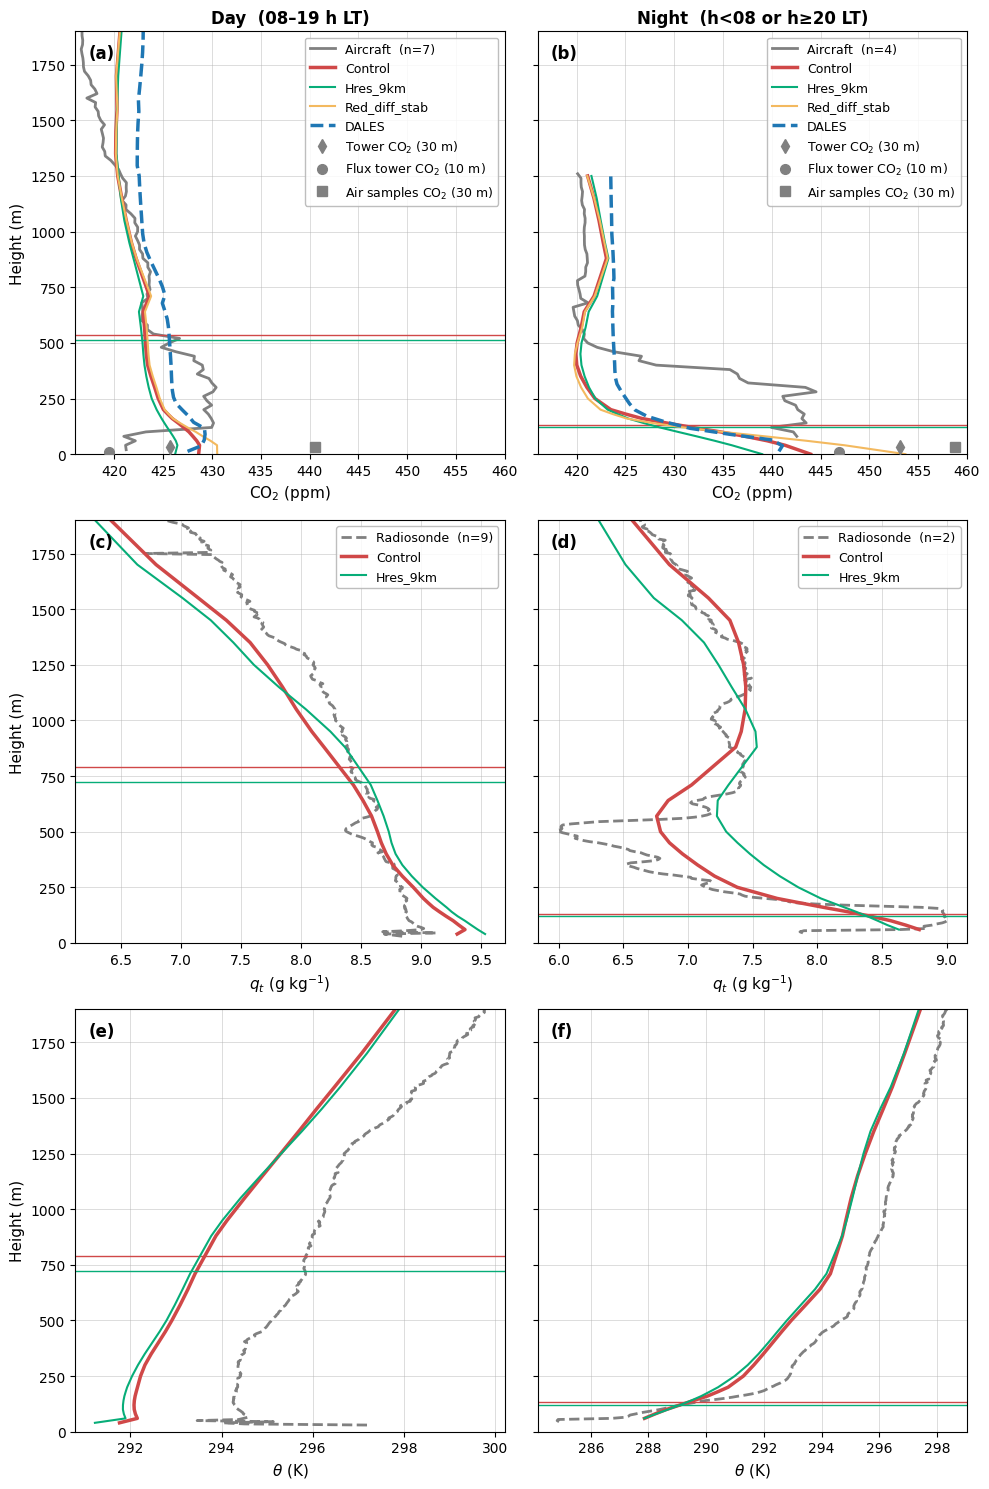

In [152]:
# ── Combined publication figure: CO2 + qt + θ profiles (Day / Night) ──────────
# Layout : 3 rows × 2 columns
#   row 0 : CO2  — aircraft observations   (solid black)
#   row 1 : qt   — radiosonde observations (dashed black)
#   row 2 : θ    — radiosonde observations (dashed black)
# ctrl_49r2b is drawn thicker than other experiments.
# half_diff_stable is only shown in row 0 (CO2).

# --- same settings as cell 31 ---

# ── Styling constants ─────────────────────────────────────────────────────────
CTRL_EXP  = 'ctrl_49r2b'
CO2_EXPS  = ['ctrl_49r2b', '9km_49r2b', 'half_diff_stable']  # row 0 only
MET_EXPS  = ['ctrl_49r2b', '9km_49r2b']                       # rows 1–2
site_key  = 'loobos'
LW_CTRL   = 2.5    # control experiment
LW_OTHER  = 1.5    # other experiments
LW_OBS    = 2.0    # observations
MAX_H     = 1900   # max plotted height (m)
FS        = 11     # base font size
FS_TITLE  = 12
FS_PANEL  = 12
# Common altitude grid
z_common = np.arange(0, 2101, 20)

# Radiosonde variable maps
_rv_obs  = {'qt': 'q',     'th': 'theta'}
_rv_ifs  = {'qt': 'q',     'th': 'th'}
_rfac    = {'qt': 1000,    'th': 1}
_rxlab   = {'qt': r'$q_t$ (g kg$^{-1}$)', 'th': r'$\theta$ (K)'}

# ── Column groupings ──────────────────────────────────────────────────────────
legs_by_col  = [day_legs,        night_legs]
radio_by_col = [day_radio_times, night_radio_times]
col_titles_p = [
    f'Day  ({day_hours[0]:02d}–{day_hours[1]:02d} h LT)',
    f'Night  (h<{night_hours[0]:02d} or h≥{night_hours[1]:02d} LT)',
]

# ── DALES CO2 variable selection ─────────────────────────────────────────────
dales_ds = None
try:
    dales_ds = dales_3d_loobos
except NameError:
    dales_ds = None
dales_co2_var = None
if dales_ds is not None:
    preferred = ['sv004_ppm', 'sv003_ppm', 'sv002_ppm', 'sv001_ppm']
    for v in preferred:
        if v in dales_ds.data_vars:
            dales_co2_var = v
            break
    if dales_co2_var is None:
        for v in dales_ds.data_vars:
            if not str(v).endswith('_ppm'):
                continue
            ln = str(dales_ds[v].attrs.get('long_name', '')).lower()
            if 'carbon dioxide' in ln or ln == 'carbon dioxide':
                dales_co2_var = v
                break

# ── Figure ────────────────────────────────────────────────────────────────────
fig_pub, axes_pub = plt.subplots(3, 2, figsize=(10, 15), sharey=True)

# ─────────────────────────────────────────────────────────────────────────────
# ROW 0 : CO2  (aircraft, solid black line)
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    ax       = axes_pub[0, icol]
    legs_sub = legs_by_col[icol]

    # Aircraft mean
    _airprof  = []
    _alt_rngs = {}
    for leg in legs_sub:
        _sa  = ds_loobos['Aircraft_co2_mol'].sel(date=slice(legs[leg][0], legs[leg][1]))
        _alt = np.asarray(_sa['Alt'].values)
        _co2 = np.asarray(_sa['CO2_7815'].values)
        _msk = np.isfinite(_alt) & np.isfinite(_co2)
        if _msk.sum() < 2:
            continue
        _aa = _alt[_msk][np.argsort(_alt[_msk])]
        _ca = _co2[_msk][np.argsort(_alt[_msk])]
        _alt_rngs[leg] = (float(_aa.min()), float(_aa.max()))
        _airprof.append(np.interp(z_common, _aa, _ca, left=np.nan, right=np.nan))

    if _airprof:
        _arr = np.vstack(_airprof)
        _cnt = np.sum(np.isfinite(_arr), axis=0)
        with np.errstate(invalid='ignore', divide='ignore'):
            _mean_air = np.nansum(_arr, axis=0) / _cnt
        ax.plot(np.where(_cnt > 0, _mean_air, np.nan), z_common,
                color='grey', lw=LW_OBS, ls='-',
                label=f'Aircraft  (n={len(_airprof)})')

    # IFS mean — CO2 only (incl. half_diff_stable)
    for exp, exp_longname, label, color in exp_names:
        if exp not in CO2_EXPS:
            continue
        lw = LW_CTRL if exp == CTRL_EXP else LW_OTHER
        _lco2 = []
        for leg in legs_sub:
            if leg not in _alt_rngs:
                continue
            _zmin, _zmax = _alt_rngs[leg]
            _zmin = 0
            _dse = (IFS[site_key]['z'][exp]
                    .sel(time=midd_times[leg], method='nearest')
                    .sel(height=slice(0, 2200)))
            _lco2.append(_dse['co2'].where(
                (_dse['height'] >= _zmin) & (_dse['height'] <= _zmax)
            ))
        if _lco2:
            _mifs = xr.concat(_lco2, dim='leg').mean('leg', skipna=True)
            ax.plot(_mifs.values, _mifs['height'].values,
                    color=color, lw=lw, label=label)
            _blh_vals = []
            for leg in legs_sub:
                if leg not in _alt_rngs:
                    continue
                try:
                    _srf = IFS[site_key]['srf'][exp].sel(time=midd_times[leg], method='nearest')
                    _blh_vals.append(float(_srf['blh'].values))
                except Exception:
                    pass
            if _blh_vals:
                if exp in MET_EXPS:
                    ax.axhline(np.nanmean(_blh_vals), color=color, lw=1)

    # DALES mean (if available)
    if (dales_ds is not None) and (dales_co2_var is not None):
        _lda = []
        for leg in legs_sub:
            if leg not in _alt_rngs:
                continue
            _zmin, _zmax = _alt_rngs[leg]
            _zmin = 0
            try:
                _dl = (dales_ds[dales_co2_var]
                       .sel(time=midd_times[leg], method='nearest')
                       .sel(zt=slice(0, 2200)))
                _lda.append(_dl.where((_dl['zt'] >= _zmin) & (_dl['zt'] <= _zmax)))
            except Exception:
                pass
        if _lda:
            _mda = xr.concat(_lda, dim='leg').mean('leg', skipna=True)
            ax.plot(_mda.values, _mda['zt'].values,
                    color='C0', ls='--', lw=LW_CTRL, label='DALES')

    # Surface instruments — black dots averaged over the same leg time windows
    loobos_tower_height  = 30   # m  (Air_Quality tower)
    loobos_fluxes_height = 10   # m  (Flux tower)
    _surf_sources = [
        (ds_loobos['Air_Quality']['co2_mixing_ratio'], loobos_tower_height,  'Tower CO$_2$ (30 m)','d'),
        (ds_loobos['Fluxes']['co2_mole_fraction'],     loobos_fluxes_height, 'Flux tower CO$_2$ (10 m)','o'),
        (ds_loobos['airsamples_O2_CO2']['CO2.pic'], loobos_tower_height, 'Air samples CO$_2$ (30 m)','s'),
    ]
    for _da, _h, _lbl, _marker in _surf_sources:
        _per_leg = []
        for leg in legs_sub:
            try:
                _t0 = pd.Timestamp(legs[leg][0]) - pd.Timedelta(minutes=10)
                _t1 = pd.Timestamp(legs[leg][1]) + pd.Timedelta(minutes=10)
                _seg = _da.sel(time=slice(_t0, _t1))
                _val = float(_seg.mean(skipna=True).values)
                if np.isfinite(_val):
                    _per_leg.append(_val)
            except Exception:
                pass
        if _per_leg:
            ax.plot(float(np.nanmean(_per_leg)), _h,
                    _marker, c='grey', ms=7, zorder=5,
                    label=_lbl #if icol == 0 else '_nolegend_'
                    )

    ax.set_xlabel('CO$_2$ (ppm)', fontsize=FS)
    ax.set_xlim(416, 460)
    ax.grid(True, lw=0.5, alpha=0.6)

# ─────────────────────────────────────────────────────────────────────────────
# ROWS 1–2 : qt and θ  (radiosonde, dashed black line)
# ─────────────────────────────────────────────────────────────────────────────
for ivar, var in enumerate(['qt', 'th']):
    var_obs = _rv_obs[var]
    var_ifs = _rv_ifs[var]
    fac     = _rfac[var]

    for icol in range(2):
        ax   = axes_pub[ivar + 1, icol]
        tset = radio_by_col[icol]

        if tset:
            # Radiosonde mean (dashed black)
            _rs   = loobos_radio.sel(time=tset).sel(Height=slice(0, MAX_H))
            _mrad = fac * _rs[var_obs].mean('time')
            ax.plot(_mrad, _rs['Height'],
                    color='grey', lw=LW_OBS, ls='--',
                    label=f'Radiosonde  (n={len(tset)})')

            # IFS mean — masked to valid radiosonde range per time
            for exp, exp_longname, label, color in exp_names:
                if exp not in MET_EXPS:
                    continue
                lw = LW_CTRL if exp == CTRL_EXP else LW_OTHER
                _lmod = []
                for t in tset:
                    _rt  = loobos_radio.sel(time=t).sel(Height=slice(0, MAX_H))
                    _ov  = _rt[var_obs].values
                    _hv  = _rt['Height'].values
                    _vld = np.isfinite(fac * _ov)
                    if _vld.sum() < 2:
                        continue
                    _zmin = float(_hv[_vld].min())
                    _zmax = float(_hv[_vld].max())
                    _mt   = (IFS['loobos']['z'][exp]
                              .sel(time=t, method='nearest')
                              .sel(height=slice(0, MAX_H)))
                    _lmod.append(_mt[var_ifs].where(
                        (_mt['height'] >= _zmin) & (_mt['height'] <= _zmax)
                    ))
                if _lmod:
                    _mm = xr.concat(_lmod, dim='time').mean('time', skipna=True)
                    ax.plot(_mm.values, _mm['height'].values,
                            color=color, lw=lw, label=label)
                    _blh_ts = []
                    for t in tset:
                        try:
                            _srf = IFS['loobos']['srf'][exp].sel(time=t, method='nearest')
                            _blh_ts.append(float(_srf['blh'].values))
                        except Exception:
                            pass
                    if _blh_ts:
                        ax.axhline(np.nanmean(_blh_ts), color=color, lw=1)

        ax.set_xlabel(_rxlab[var], fontsize=FS)
        ax.grid(True, lw=0.5, alpha=0.6)

# ─────────────────────────────────────────────────────────────────────────────
# Column titles, y-labels, panel letters, legends
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    axes_pub[0, icol].set_title(col_titles_p[icol], fontsize=FS_TITLE, fontweight='bold')

for irow in range(3):
    axes_pub[irow, 0].set_ylabel('Height (m)', fontsize=FS)
    for icol in range(2):
        ax     = axes_pub[irow, icol]
        letter = 'abcdef'[irow * 2 + icol]
        ax.set_ylim(0, MAX_H)
        ax.tick_params(labelsize=10)
        ax.text(0.03, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=FS_PANEL, fontweight='bold', va='top', ha='left')
        if irow < 2:
            ax.legend(fontsize=9, loc='best', framealpha=0.85,
                      edgecolor='0.7')

import os
os.makedirs(dir_out, exist_ok=True)
fig_pub.tight_layout()
plt.savefig(f'{dir_out}/mean_profiles_loobos_day_night.png', dpi=250, bbox_inches='tight')
plt.show()


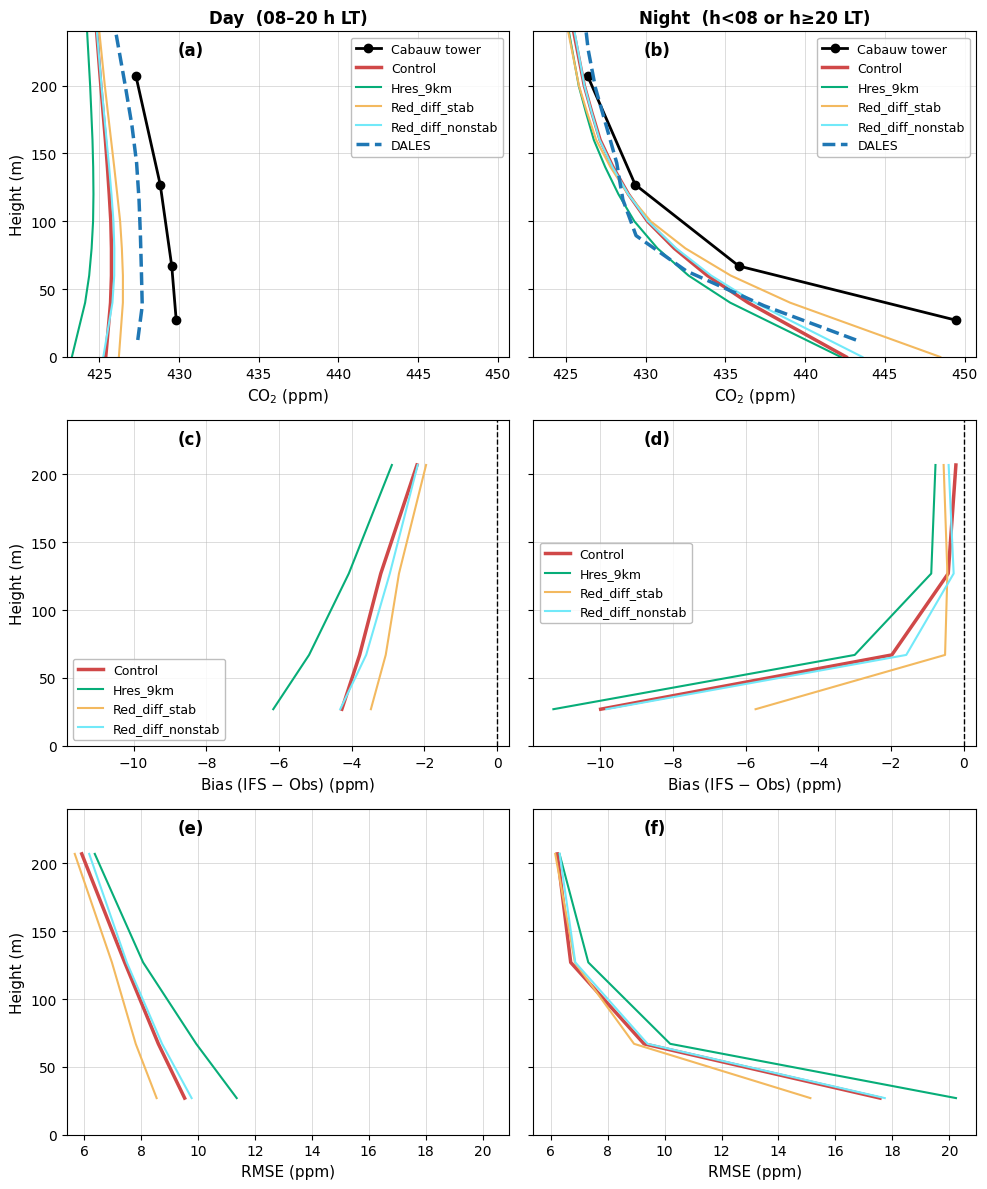

In [138]:

# ── Cabauw CO2 profiles: Obs & IFS & DALES, Bias, RMSE (Day / Night) ─────────
# Layout : 3 rows × 2 columns
#   row 0 : CO2  — tower obs (markers) + IFS native grid + DALES native grid
#   row 1 : Bias (IFS − Obs)  — at Cabauw tower heights
#   row 2 : RMSE              — at Cabauw tower heights
# Day on left column, Night on right column.
# ctrl_49r2b is drawn thicker than other experiments.

# ── Settings ──────────────────────────────────────────────────────────────────
plot_exps = ['half_diff_stable', 'half_diff_unstable', 'ctrl_49r2b', '9km_49r2b']

cabauw_heights = np.array([27, 67, 127, 207])
site_key  = 'cabauw'
obs_ds    = ds_cabauw['Cabauw_CO2_May2022']

CTRL_EXP  = 'ctrl_49r2b'
LW_CTRL   = 2.5
LW_OTHER  = 1.5
LW_OBS    = 2.0
FS        = 11
FS_TITLE  = 12
FS_PANEL  = 12

# Time subset
time_slice = slice('2022-05-14T00:00', '2022-05-23T00:00')

obs_time  = obs_ds['time'].sel(time=time_slice)
obs_time  = pd.to_datetime(obs_time.values)

# Daytime / nighttime masks
day_mask   = (obs_time.hour >= 8) & (obs_time.hour < 20)
night_mask = ~day_mask

# ── Column titles ──────────────────────────────────────────────────────────────
col_titles_p = [
    'Day  (08–20 h LT)',
    'Night  (h<08 or h≥20 LT)',
]

# ── Helper: bias / RMSE at tower heights ──────────────────────────────────────
def compute_profiles(mask):
    obs_profiles  = []
    bias_profiles = {exp: [] for exp in plot_exps}
    rmse_profiles = {exp: [] for exp in plot_exps}
    blh_profiles  = {exp: None for exp in plot_exps}

    times_mask = obs_time[mask]

    first_exp = next(exp for exp, *_ in exp_names if exp in plot_exps)
    ifs_ref_times = pd.to_datetime(
        IFS[site_key]['z'][first_exp]['co2'].sel(time=time_slice)['time'].values)
    common_times = np.intersect1d(times_mask, ifs_ref_times)

    for sel_z in cabauw_heights:
        obs_var  = f'co2_{sel_z}m'
        obs_vals = obs_ds[obs_var].sel(time=common_times).values
        obs_profiles.append(obs_vals.mean())
    obs_profiles = np.array(obs_profiles)

    for (exp, exp_longname, label, color) in exp_names:
        if exp not in plot_exps:
            continue
        ifs_data  = IFS[site_key]['z'][exp]['co2'].sel(time=time_slice)
        ifs_times = pd.to_datetime(ifs_data['time'].values)
        exp_common_times = np.intersect1d(times_mask, ifs_times)

        bias_list = []
        rmse_list = []
        for sel_z in cabauw_heights:
            obs_var  = f'co2_{sel_z}m'
            obs_vals = obs_ds[obs_var].sel(time=exp_common_times).values
            closest_height = get_closest_height(ifs_data.height.values, sel_z)
            ifs_common = ifs_data.sel(
                time=exp_common_times, height=closest_height, method='nearest').values
            bias_list.append((ifs_common - obs_vals).mean())
            rmse_list.append(np.sqrt(((ifs_common - obs_vals)**2).mean()))

        bias_profiles[exp] = np.array(bias_list)
        rmse_profiles[exp] = np.array(rmse_list)

        ifs_blh_times = pd.to_datetime(
            IFS[site_key]['srf'][exp]['blh']['time'].values)
        common_blh_times = np.intersect1d(exp_common_times, ifs_blh_times)
        if len(common_blh_times) > 0:
            mask_blh = np.isin(ifs_blh_times, common_blh_times)
            ifs_blh  = IFS[site_key]['srf'][exp]['blh'].values[mask_blh]
            blh_profiles[exp] = np.mean(ifs_blh)

    return obs_profiles, bias_profiles, rmse_profiles, blh_profiles

# ── Compute bias / RMSE ───────────────────────────────────────────────────────
day_obs,   day_bias,   day_rmse,   day_blh   = compute_profiles(day_mask)
night_obs, night_bias, night_rmse, night_blh = compute_profiles(night_mask)

obs_by_col  = [day_obs,   night_obs]
bias_by_col = [day_bias,  night_bias]
rmse_by_col = [day_rmse,  night_rmse]

# ── Native IFS CO2 profiles for row 0 (native height grid, 0–250 m) ──────────
ifs_co2_by_col = {exp: [None, None] for exp in plot_exps}
for exp, exp_longname, label, color in exp_names:
    if exp not in plot_exps:
        continue
    for icol, mask in enumerate([day_mask, night_mask]):
        times_mask   = obs_time[mask]
        ifs_data     = IFS[site_key]['z'][exp]['co2'].sel(time=time_slice)
        ifs_times    = pd.to_datetime(ifs_data['time'].values)
        common_times = np.intersect1d(times_mask, ifs_times)
        if len(common_times) == 0:
            continue
        prof = (ifs_data.sel(time=common_times)
                        .sel(height=slice(0, 250))
                        .mean('time', skipna=True))
        ifs_co2_by_col[exp][icol] = prof

# ── DALES CO2 profiles for row 0 (native zt grid, 0–250 m) ───────────────────
_dales_co2_var = None
_preferred_dales = ['sv004_ppm', 'sv003_ppm', 'sv002_ppm', 'sv001_ppm']
for _v in _preferred_dales:
    if _v in dales_cabauw.data_vars:
        _dales_co2_var = _v
        break
if _dales_co2_var is None:
    for _v in dales_cabauw.data_vars:
        if not str(_v).endswith('_ppm'):
            continue
        _ln = str(dales_cabauw[_v].attrs.get('long_name', '')).lower()
        if 'carbon dioxide' in _ln:
            _dales_co2_var = _v
            break

dales_co2_by_col = [None, None]
if _dales_co2_var is not None:
    for icol, mask in enumerate([day_mask, night_mask]):
        times_mask   = obs_time[mask]
        dales_times  = pd.to_datetime(dales_cabauw['time'].values)
        common_times = np.intersect1d(times_mask, dales_times)
        if len(common_times) == 0:
            continue
        _dp = (dales_cabauw[_dales_co2_var]
               .sel(time=common_times)
               .sel(zt=slice(0, 300))
               .mean('time', skipna=True))
        dales_co2_by_col[icol] = _dp

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharey=True)

# ─────────────────────────────────────────────────────────────────────────────
# ROW 0 : CO2  (Obs at tower heights, IFS & DALES at native grids)
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    ax      = axes[0, icol]
    obs_col = obs_by_col[icol]

    ax.plot(obs_col, cabauw_heights, color='black', lw=LW_OBS, ls='-', marker='o', label='Cabauw tower')
    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue
        lw   = LW_CTRL if exp == CTRL_EXP else LW_OTHER
        prof = ifs_co2_by_col[exp][icol]
        if prof is not None:
            ax.plot(prof.values, prof['height'].values, color=color, lw=lw, label=label)

    if dales_co2_by_col[icol] is not None:
        _dp = dales_co2_by_col[icol]
        ax.plot(_dp.values, _dp['zt'].values,
                color='C0', ls='--', lw=LW_CTRL, label='DALES')

    ax.set_xlabel('CO$_2$ (ppm)', fontsize=FS)

# ─────────────────────────────────────────────────────────────────────────────
# ROW 1 : Bias (IFS − Obs)
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    ax       = axes[1, icol]
    bias_col = bias_by_col[icol]

    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue
        lw = LW_CTRL if exp == CTRL_EXP else LW_OTHER
        ax.plot(bias_col[exp], cabauw_heights, color=color, lw=lw, label=label)

    ax.axvline(0, color='k', lw=1.0, ls='--')
    ax.set_xlabel('Bias (IFS $-$ Obs) (ppm)', fontsize=FS)

# ─────────────────────────────────────────────────────────────────────────────
# ROW 2 : RMSE
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    ax       = axes[2, icol]
    rmse_col = rmse_by_col[icol]

    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue
        lw = LW_CTRL if exp == CTRL_EXP else LW_OTHER
        ax.plot(rmse_col[exp], cabauw_heights, color=color, lw=lw, label=label)

    ax.set_xlabel('RMSE (ppm)', fontsize=FS)

# ── Enforce consistent x-limits per row across day / night columns ────────────
for irow in range(3):
    xlims = [axes[irow, icol].get_xlim() for icol in range(2)]
    xmin  = min(xl[0] for xl in xlims)
    xmax  = max(xl[1] for xl in xlims)
    for icol in range(2):
        axes[irow, icol].set_xlim(xmin, xmax)

# ─────────────────────────────────────────────────────────────────────────────
# Column titles, y-labels, panel letters, legends, grid
# ─────────────────────────────────────────────────────────────────────────────
for icol in range(2):
    axes[0, icol].set_title(col_titles_p[icol], fontsize=FS_TITLE, fontweight='bold')

for irow in range(3):
    axes[irow, 0].set_ylabel('Height (m)', fontsize=FS)
    for icol in range(2):
        ax     = axes[irow, icol]
        letter = 'abcdef'[irow * 2 + icol]
        ax.set_ylim(0, 240)
        ax.tick_params(labelsize=10)
        ax.text(0.25, 0.97, f'({letter})', transform=ax.transAxes,
                fontsize=FS_PANEL, fontweight='bold', va='top', ha='left')
        if irow < 2:
            ax.legend(fontsize=9, loc='best', framealpha=0.85, edgecolor='0.7')
        ax.grid(True, lw=0.5, alpha=0.6)  # called after legend to prevent override

import os
os.makedirs(dir_out, exist_ok=True)
fig.tight_layout()
# plt.savefig(f'{dir_out}/cabauw_co2_profiles_day_night.png', dpi=250, bbox_inches='tight')
plt.show()


In [103]:
for height in cabauw_heights:
    co2 = ds_cabauw['Cabauw_CO2_May2022'][f'co2_{height}m'].sortby('time')

    # Compute differences and time steps (in hours)
    dco2 = co2.diff('time')
    dt_hours = co2['time'].diff('time') / np.timedelta64(1, 'h')

    # Mask out time steps longer than 1 hour
    valid = dt_hours <= 1.0
    dco2dt = xr.where(valid, dco2 / dt_hours, np.nan)

    # Assign midpoint time coordinates and attributes
    dco2dt = dco2dt.assign_coords(time=co2['time'][1:])
    dco2dt.name = f'dco2dt_{height}'
    dco2dt.attrs['units'] = 'ppm h⁻¹'

    ds_cabauw['Cabauw_CO2_May2022'][dco2dt.name] = dco2dt


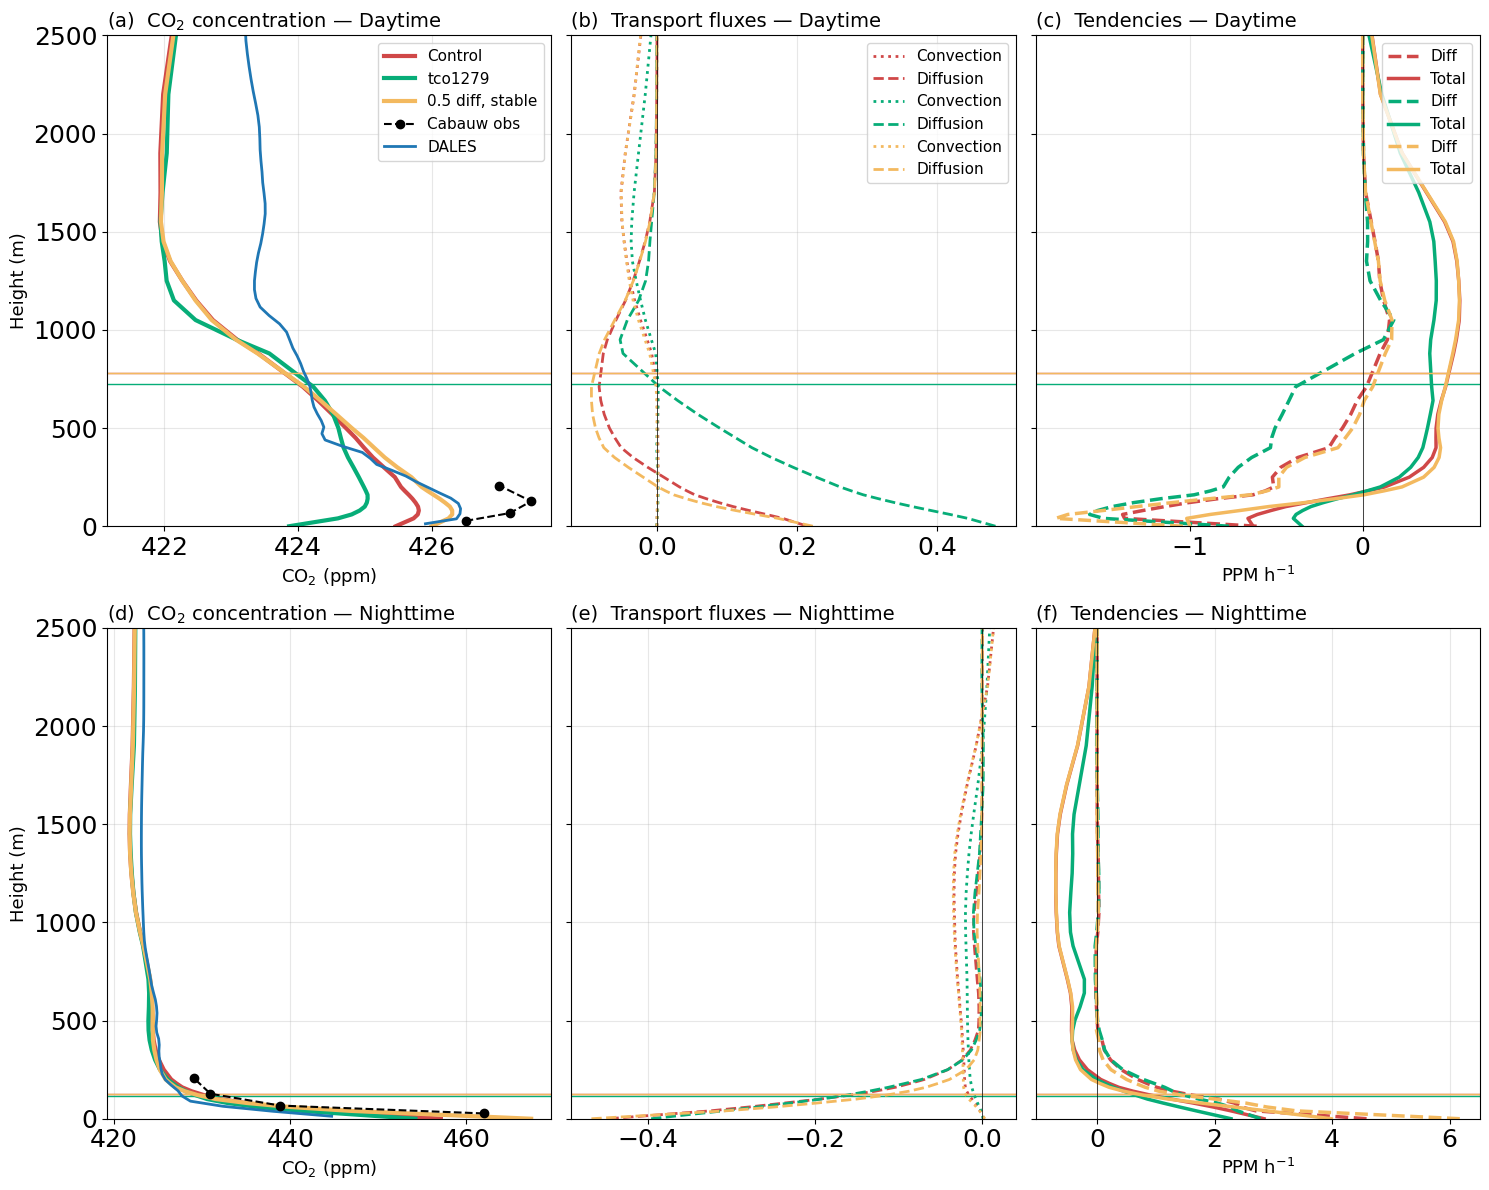

In [ ]:
### Flux profiles and Budgets — Day (top) & Night (bottom) ###
var = 'co2'
plot_exps = ['ctrl_49r2b','half_diff_stable','half_diff_unstable','9km_49r2b']

plot_spp_exps = []
spp_var = 'co2_ppm'

site_key = 'cabauw'
plot_dales = True
ylim = 2500

row_configs = [
    ("Daytime",  "day",   day_hours),
    ("Nighttime","night", night_hours),
]

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- 2x3 figure ---
fig, all_axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 12), sharey=True)

for irow, (row_title, time_selection, daytime) in enumerate(row_configs):
    axes = all_axes[irow]

    # --- Filter observations for this row ---
    if site_key == 'cabauw':
        obs_ds_row = ds_cabauw['Cabauw_CO2_May2022']
        obs_flx_row = mfun.concentration_to_ppm(
            'co2', -ds_cabauw['obs_tower_flx'][['FC005','FC060','FC100','FC180']] * 10**-6)

        if time_selection == "day":
            obs_ds_row  = obs_ds_row.sel(time=obs_ds_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            obs_flx_row = obs_flx_row.sel(time=obs_flx_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_dales:
                ds_dales_row = dales_cabauw.sel(time=dales_cabauw['time'].dt.hour.isin(range(daytime[0], daytime[1])))
        elif time_selection == "night":
            obs_ds_row  = obs_ds_row.sel(time=~obs_ds_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            obs_flx_row = obs_flx_row.sel(time=~obs_flx_row['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            if plot_dales:
                ds_dales_row = dales_cabauw.sel(time=~dales_cabauw['time'].dt.hour.isin(range(daytime[0], daytime[1])))

        obs_time = obs_ds_row['time']

    spp_plotted = False

    # --- Loop through experiments ---
    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue

        ds = IFS[site_key]['z'][exp]
        ds_srf = IFS[site_key]['srf'][exp]

        if time_selection == "day":
            ds     = ds.sel(time=ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            ds_srf = ds_srf.sel(time=ds_srf['time'].dt.hour.isin(range(daytime[0], daytime[1])))
        elif time_selection == "night":
            ds     = ds.sel(time=~ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
            ds_srf = ds_srf.sel(time=~ds_srf['time'].dt.hour.isin(range(daytime[0], daytime[1])))

        if site_key == 'cabauw' and plot_dales:
            common_times = np.intersect1d(
                np.intersect1d(ds['time'].values, obs_time.values),
                ds_dales_row['time'].values)
            ds     = ds.sel(time=common_times)
            ds_srf = ds_srf.sel(time=common_times)
            ds_dales_row = ds_dales_row.sel(time=common_times)
        elif site_key == 'cabauw':
            common_times = np.intersect1d(ds['time'].values, obs_time.values)
            ds     = ds.sel(time=common_times)
            ds_srf = ds_srf.sel(time=common_times)

        # SPP envelope
        if (not spp_plotted) and len(plot_spp_exps) > 0:
            spp_exp = plot_spp_exps[0]
            spp_ds = IFS_nemo.get(site_key, {}).get('z', {}).get(spp_exp, None)
            if spp_ds is not None and (spp_var in spp_ds):
                if time_selection == "day":
                    spp_ds = spp_ds.sel(time=spp_ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
                elif time_selection == "night":
                    spp_ds = spp_ds.sel(time=~spp_ds['time'].dt.hour.isin(range(daytime[0], daytime[1])))
                if site_key == 'cabauw':
                    spp_ds = spp_ds.sel(time=common_times)
                spp_mean = spp_ds[spp_var].sel(height=slice(0, ylim)).mean('time')
                if 'number' in spp_mean.dims:
                    spp_min = spp_mean.min('number')
                    spp_max = spp_mean.max('number')
                    spp_color = next((t[3] for t in nemo_exp_names if len(t) >= 4 and t[0] == spp_exp), 'grey')
                    spp_label = next((t[2] for t in nemo_exp_names if len(t) >= 3 and t[0] == spp_exp), 'SPP')
                    axes[0].fill_betweenx(
                        spp_min['height'].values, spp_min.values, spp_max.values,
                        color=spp_color, alpha=0.16, label=spp_label)
                    spp_plotted = True

        # Concentration profile
        ds[var].mean('time').plot(
            y='height', ax=axes[0], label=f'{label}', color=color, lw=3)
        axes[0].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)

        # Flux profiles
        axes[1].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)
        ds[f'{var}flx_conv'].mean('time').plot(
            y='height', ax=axes[1], label='Convection', color=color, linestyle=':', lw=2)
        ds[f'{var}flx_diff'].mean('time').plot(
            y='height', ax=axes[1], label='Diffusion', color=color, linestyle='--', lw=2)

        # Tendencies
        axes[2].axhline(ds_srf['blh'].mean('time'), color=color, lw=1)
        ds[f'd{var}dt_diff'].mean('time').plot(
            y='height', ax=axes[2], label='Diff', color=color, linestyle='--', lw=2.5)
        (ds[f'd{var}dt_diff'] + ds[f'd{var}dt_conv'] + ds[f'd{var}dt_dyn']).mean('time').plot(
            y='height', ax=axes[2], label='Total', color=color, linestyle='-', lw=2.5)

    # --- Observations ---
    if site_key == 'cabauw':
        obs_mean = obs_ds_row.sel(time=common_times).mean('time')
        obs_conc = np.array([obs_mean[f'co2_{z}m'].values for z in cabauw_heights])
        axes[0].plot(obs_conc, cabauw_heights, 'ko--', label='Cabauw obs', zorder=5)

        tend_vars = [f'dco2dt_{z}' for z in cabauw_heights if f'dco2dt_{z}' in obs_mean]
        if tend_vars:
            obs_tend = np.array([obs_mean[v].values for v in tend_vars])
            tend_heights = [int(v.split('_')[-1].replace('m', '')) for v in tend_vars]
            axes[2].plot(obs_tend, tend_heights, 'ko--', label='Cabauw obs', zorder=5)

    # --- DALES ---
    if site_key == 'cabauw' and plot_dales:
        dales_ppm = ds_dales_row['sv004_ppm'].mean('time')
        dales_ppm.plot(ax=axes[0], y='zt', lw=2, label='DALES')

    # --- Axis styling ---
    unit_tend = ds[f'd{var}dt_tot'].attrs.get("units", " ")
    unit_flx  = ds[f'{var}flx_conv'].attrs.get("units", " ")

    axes[0].set_ylim([0, ylim])
    axes[0].set_xlabel('CO$_2$ (ppm)', fontsize=13)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(
        f'{panel_labels[irow*3]}  CO$_2$ concentration \u2014 {row_title}',
        fontsize=14, loc='left')
    axes[0].set_ylabel('Height (m)', fontsize=13)

    axes[1].axvline(0, c='k', lw=0.5)
    axes[1].set_ylim([0, ylim])
    axes[1].set_xlabel(unit_flx, fontsize=13)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('')
    axes[1].set_title(
        f'{panel_labels[irow*3+1]}  Transport fluxes \u2014 {row_title}',
        fontsize=14, loc='left')

    axes[2].axvline(0, c='k', lw=0.5)
    axes[2].set_ylim([0, ylim])
    axes[2].set_xlabel(unit_tend, fontsize=13)
    axes[2].set_ylabel('')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_title(
        f'{panel_labels[irow*3+2]}  Tendencies \u2014 {row_title}',
        fontsize=14, loc='left')

    # Legend only on top row
    if irow == 0:
        axes[0].legend(fontsize=11, loc='upper right')
        axes[1].legend(fontsize=11, loc='upper right')
        axes[2].legend(fontsize=11, loc='upper right')

plt.tight_layout()
fig.savefig(f'{dir_out}/co2_profiles_{site_key}_day_night.png', dpi=300)
plt.show()


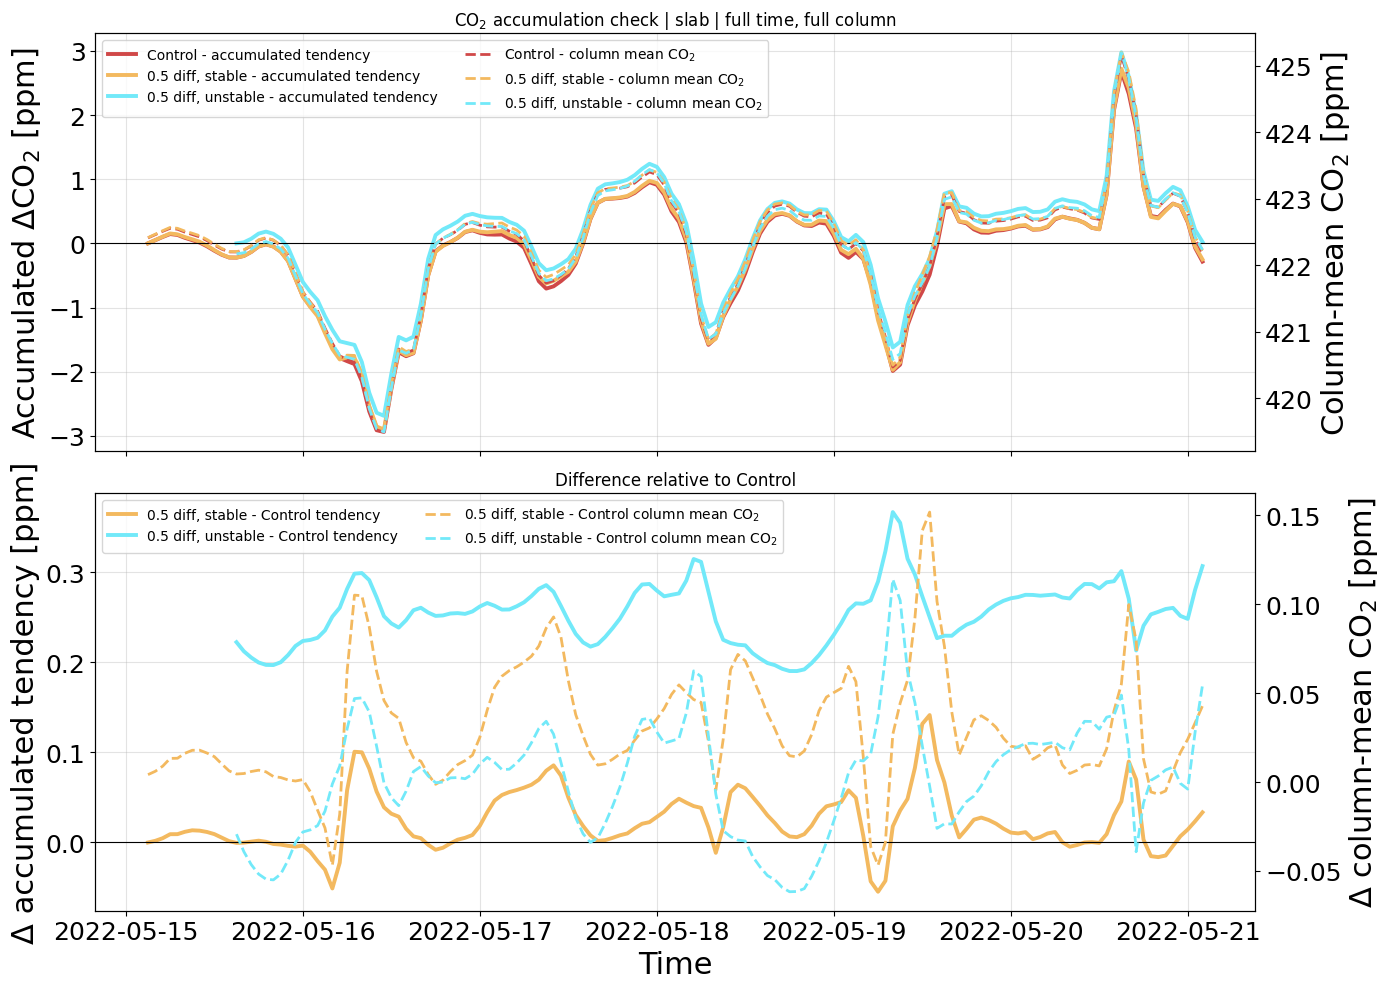

In [135]:
## plot accumulated tendencies to check that the co2 is not lost but just redistributed.

var = 'co2'
site_key = 'slab'
plot_exps = ['ctrl_49r2b','half_diff_stable','half_diff_unstable']  # experiments to plot


def vertical_mean(da, height_name='height', zmax=None):
    da_sel = da if zmax is None else da.sel({height_name: slice(0, zmax)})
    z = da_sel[height_name]
    depth = float(z.max() - z.min())
    if depth == 0:
        return da_sel.isel({height_name: 0})
    return da_sel.integrate(height_name) / depth

def accumulate_tendency(da):
    da = da.sortby('time')
    if da.sizes.get('time', 0) < 2:
        return da * 0

    dt_hours = xr.DataArray(
        da['time'].diff('time') / np.timedelta64(1, 'h'),
        coords={'time': da['time'][1:]},
        dims='time',
    )
    valid = dt_hours <= 1.5
    increments = xr.where(valid, da.isel(time=slice(1, None)) * dt_hours, 0.0)
    cumulative = xr.concat([da.isel(time=0) * 0.0, increments.cumsum('time')], dim='time')
    cumulative = cumulative.assign_coords(time=da['time'])
    return cumulative

process_specs = [
    'dco2dt_diff',
    'dco2dt_conv',
    'dco2dt_dyn',
]

def get_exp_style(exp):
    exp_label = exp
    exp_color = 'tab:blue'
    for exp_name, exp_longname, label, color in exp_names:
        if exp_name == exp:
            exp_label = label
            exp_color = color
            break
    return exp_label, exp_color

def get_column_series(exp):
    ds_exp = IFS[site_key]['z'][exp].sortby('time')
    co2_column = vertical_mean(ds_exp[var])

    component_sum = None
    for tend_name in process_specs:
        if tend_name not in ds_exp:
            continue
        column_tendency = vertical_mean(ds_exp[tend_name])
        if component_sum is None:
            component_sum = column_tendency.copy()
        else:
            component_sum = component_sum + column_tendency

    if component_sum is None:
        return None, None

    accumulated_total = accumulate_tendency(component_sum)
    return accumulated_total, co2_column

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
ax_top = axes[0]
ax_bot = axes[1]
ax_top2 = ax_top.twinx()
ax_bot2 = ax_bot.twinx()

exp_series = {}
for exp in plot_exps:
    accumulated_total, co2_column = get_column_series(exp)
    if accumulated_total is None:
        continue
    exp_series[exp] = {
        'accumulated': accumulated_total,
        'co2_column': co2_column,
    }

for exp in plot_exps:
    if exp not in exp_series:
        continue

    exp_label, exp_color = get_exp_style(exp)
    accumulated_total = exp_series[exp]['accumulated']
    co2_column = exp_series[exp]['co2_column']

    ax_top.plot(
        accumulated_total['time'],
        accumulated_total,
        color=exp_color,
        lw=2.8,
        linestyle='-',
        label=f'{exp_label} - accumulated tendency',
    )
    ax_top2.plot(
        co2_column['time'],
        co2_column,
        color=exp_color,
        lw=2.0,
        linestyle='--',
        label=f'{exp_label} - column mean CO$_2$',
    )

baseline_exp = None
if plot_exps:
    if plot_exps[0] in exp_series:
        baseline_exp = plot_exps[0]

if baseline_exp is not None:
    baseline_acc = exp_series[baseline_exp]['accumulated']
    baseline_co2 = exp_series[baseline_exp]['co2_column']
    baseline_label, _ = get_exp_style(baseline_exp)

    for exp in plot_exps[1:]:
        if exp not in exp_series:
            continue

        exp_label, exp_color = get_exp_style(exp)
        exp_acc = exp_series[exp]['accumulated']
        exp_co2 = exp_series[exp]['co2_column']

        common_time_acc = np.intersect1d(exp_acc['time'].values, baseline_acc['time'].values)
        common_time_co2 = np.intersect1d(exp_co2['time'].values, baseline_co2['time'].values)

        if len(common_time_acc) > 0:
            acc_diff = exp_acc.sel(time=common_time_acc) - baseline_acc.sel(time=common_time_acc)
            ax_bot.plot(
                acc_diff['time'],
                acc_diff,
                color=exp_color,
                lw=2.8,
                linestyle='-',
                label=f'{exp_label} - {baseline_label} tendency',
            )

        if len(common_time_co2) > 0:
            co2_diff = exp_co2.sel(time=common_time_co2) - baseline_co2.sel(time=common_time_co2)
            ax_bot2.plot(
                co2_diff['time'],
                co2_diff,
                color=exp_color,
                lw=2.0,
                linestyle='--',
                label=f'{exp_label} - {baseline_label} column mean CO$_2$',
            )

ax_top.axhline(0, color='k', lw=0.8)
ax_top.grid(True, alpha=0.35)
ax_top.set_ylabel('Accumulated ΔCO$_2$ [ppm]')
ax_top.set_title(f'CO$_2$ accumulation check | {site_key} | full time, full column')
ax_top2.set_ylabel('Column-mean CO$_2$ [ppm]')

ax_bot.axhline(0, color='k', lw=0.8)
ax_bot.grid(True, alpha=0.35)
ax_bot.set_ylabel('Δ accumulated tendency [ppm]')
ax_bot.set_xlabel('Time')
if baseline_exp is not None:
    baseline_label, _ = get_exp_style(baseline_exp)
    ax_bot.set_title(f'Difference relative to {baseline_label}')
else:
    ax_bot.set_title('Difference relative to first experiment')
ax_bot2.set_ylabel('Δ column-mean CO$_2$ [ppm]')

handles_top_1, labels_top_1 = ax_top.get_legend_handles_labels()
handles_top_2, labels_top_2 = ax_top2.get_legend_handles_labels()
ax_top.legend(handles_top_1 + handles_top_2, labels_top_1 + labels_top_2, fontsize=10, ncol=2, loc='best')

handles_bot_1, labels_bot_1 = ax_bot.get_legend_handles_labels()
handles_bot_2, labels_bot_2 = ax_bot2.get_legend_handles_labels()
ax_bot.legend(handles_bot_1 + handles_bot_2, labels_bot_1 + labels_bot_2, fontsize=10, ncol=2, loc='best')

plt.tight_layout()
plt.show()

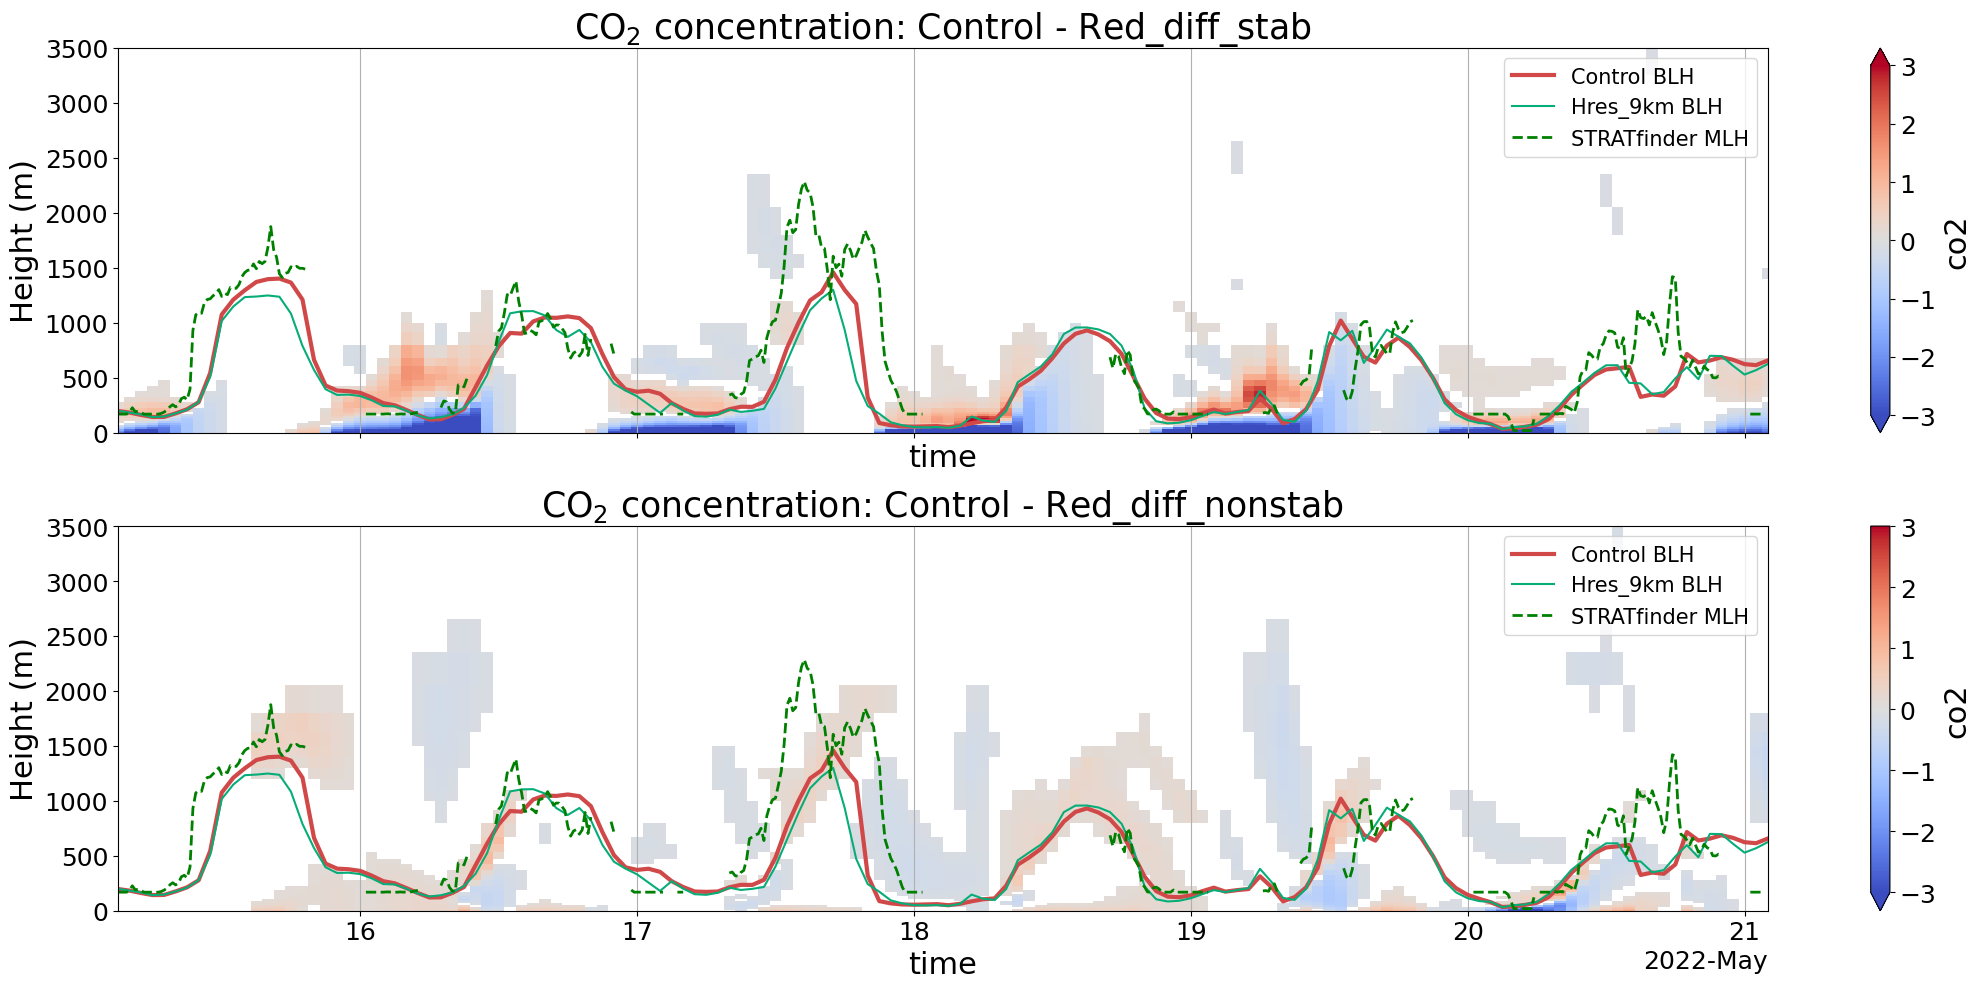

In [290]:
##############################################
#####   Difference between experiments  #####
##############################################
import matplotlib.colors as mcolors

# Experiments to compare
exp1 = 'ctrl_49r2b'
exp2 = ['half_diff_stable', 'half_diff_unstable',]

location ='cabauw'
add_loobos = False

# Variables to plot: (variable_name, plot title)
vars_to_plot = [
    # ('dco2dt_dyn',  'CO2 tendency from dynamics'),
    # ('dco2dt_conv', 'CO2 tendency from convection'),
    # ('dco2dt_diff', 'CO2 tendency from diffusion'),
    ('co2', r'CO$_2$ concentration'),
    # ('clwc', 'cloud liquid water'),
    # ('T', 'Temperature'),
]

# Colormap limits (set to None for automatic scaling)
vmin = -3
vmax = +3

n_rows = len(exp2) * len(vars_to_plot)

# Create a figure with rows equal to number of exp2 members * number of variables
fig, axes = plt.subplots(nrows=n_rows, ncols=1, figsize=(22, n_rows*4+2), sharex=True)

# Make sure axes is always iterable
if n_rows == 1:
    axes = [axes]

ax_idx = 0
# Loop through each exp2 experiment and each variable
for exp2_exp in exp2:
    for var, title in vars_to_plot:
        ax = axes[ax_idx]
        ax_idx += 1

        # Calculate difference between experiments
        data_diff = IFS[location]['z'][exp1][var] - IFS[location]['z'][exp2_exp][var]

        masked = data_diff.where(np.abs(data_diff) >= 0.1)
        cmap = plt.get_cmap("coolwarm").copy()
        cmap.set_bad("white")

        # Norm centred exactly at 0 → 0 is always white
        norm_colors = mcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

        # Plot the difference
        masked.plot(
            ax=ax,
            y='height',
            cmap=cmap,
            norm=norm_colors,
        )

        # Add boundary layer height lines for both experiments
        for blh_exp in [exp1,'9km_49r2b']:
            if blh_exp =='ctrl_49r2b':
                lw =3
            else: lw=1.5
            blh_color = next((t[3] for t in exp_names if t[0] == blh_exp), 'k')
            blh_label = next((t[2] for t in exp_names if t[0] == blh_exp), blh_exp)
            IFS[location]['srf'][blh_exp]['blh'].plot(ax=ax, x='time', c=blh_color, lw=lw, label=f'{blh_label} BLH')

        if location == 'cabauw':
            blh_cabauw['MLH'].sel(station_name='CABAUW,NETHERLANDS            ').plot(ax=ax, c='g', ls='--', lw=2, label='STRATfinder MLH')

        if add_loobos:
            ds_loobos['BLH']['BLH_radio'].plot.scatter(ax=ax, c='k', alpha=0.3, label='Radiosondes', s=100, marker='d')
            ds_loobos['BLH']['BLH_plane'].plot.scatter(ax=ax, c='k',alpha=0.3, label='Plane', s=100, marker='o')

        # Formatting
        ax.set_ylim(0, 3500)
        ax.set_xlim(
            datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M"),
            datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")
        )
        ax.set_ylabel('Height (m)')
        exp1_label = next((t[2] for t in exp_names if t[0] == exp1), exp1)
        exp2_label = next((t[2] for t in exp_names if t[0] == exp2_exp), exp2_exp)
        ax.set_title(f'{title}: {exp1_label} - {exp2_label}', fontsize=25)
        ax.legend(fontsize=15)
        ax.grid(axis='x')

# Adjust layout for readability
plt.tight_layout()
plt.savefig(os.path.join(dir_out, f"diff_{exp1}_vs_{'_'.join(exp2)}.png"), dpi=300, bbox_inches='tight')


plotting SPP_all, column 0
plotting SPP_turb, column 0
plotting SPP_rkap, column 0
plotting SPP_all, column 1
plotting SPP_turb, column 1
plotting SPP_rkap, column 1


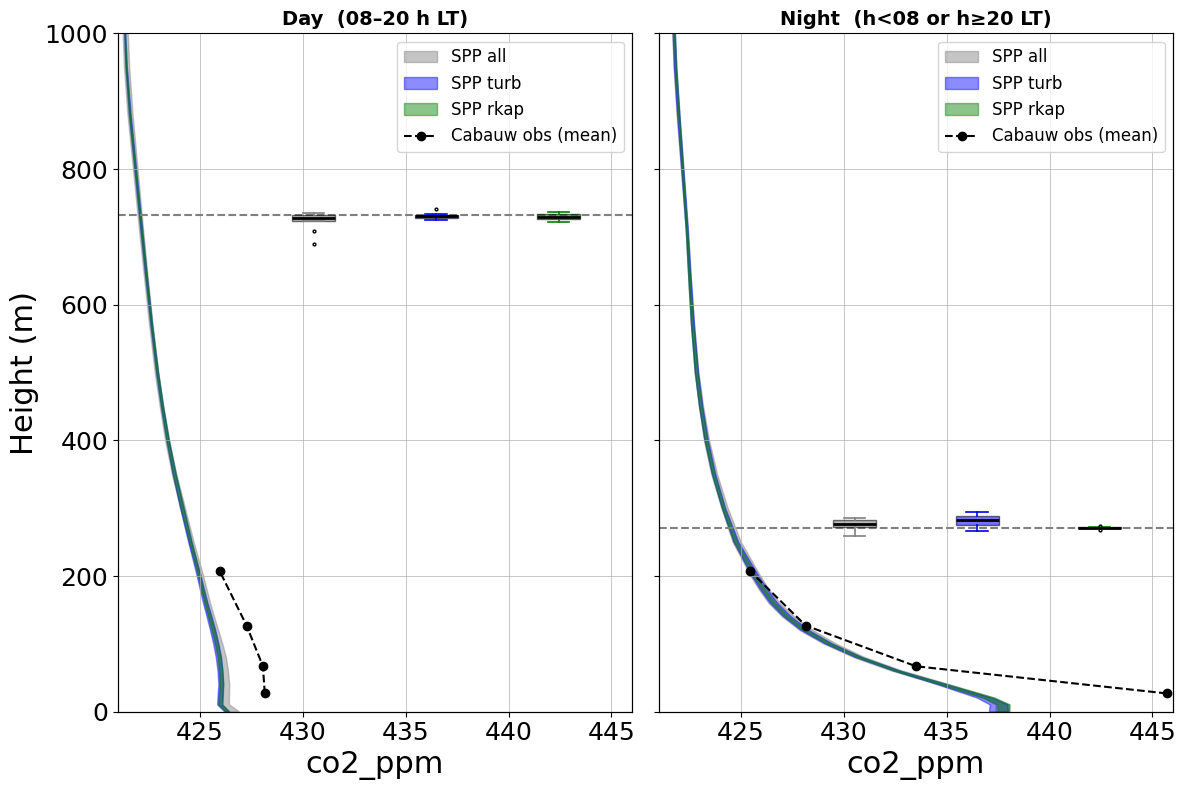

In [170]:
var_nemo = 'co2_ppm'
region   = 'slab'   # or 'cabauw' or 'loobos'

plot_spp_exps   = ['SPP_turb', 'SPP_all', 'SPP_rkap']

plot_memebr0    = False
plot_obs_cabauw = True   # overlay Cabauw tower CO2 profile (4 heights)

# ── Day / Night time definition (same as cell 28) ─────────────────────────────
time_slice  = slice('2022-05-14T00:00', '2022-05-23T00:00')
obs_ds_cb   = ds_cabauw['Cabauw_CO2_May2022']
obs_time_cb = pd.to_datetime(obs_ds_cb['time'].sel(time=time_slice).values)

_day_mask   = (obs_time_cb.hour >= 8) & (obs_time_cb.hour < 20)
_night_mask = ~_day_mask

col_configs = [
    ('Day  (08–20 h LT)',           _day_mask),
    ('Night  (h<08 or h≥20 LT)',    _night_mask),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

active_exps = [(exp, label, color)
               for exp, _, label, color in nemo_exp_names
               if exp in plot_spp_exps]

for icol, (col_title, col_mask) in enumerate(col_configs):
    ax        = axes[icol]
    times_sel = obs_time_cb[col_mask]

    blh_box_data   = []
    blh_box_colors = []

    for i_exp, (exp, label, color) in enumerate(active_exps):
        print(f"plotting {exp}, column {icol}")

        # ── CO2 profile (shaded member envelope) ──────────────────────────────
        spp_full = (IFS_nemo[region]['z'][exp][var_nemo]
                    .sel(height=slice(0, 2500)))
        ifs_nemo_times = pd.to_datetime(spp_full['time'].values)
        common_times   = np.intersect1d(times_sel, ifs_nemo_times)
        if len(common_times) == 0:
            continue
        spp_data = spp_full.sel(time=common_times).mean('time')

        spp_min = spp_data.min('number')
        spp_max = spp_data.max('number')
        ax.fill_betweenx(
            spp_min['height'].values,
            spp_min.values,
            spp_max.values,
            color=color, alpha=0.45, label=label,
        )
        if plot_memebr0:
            spp_data.sel(number=0).plot(
                y='height', c=color, lw=1.5, ax=ax, add_legend=False)

        if exp == 'SPP_all':
            # --- BLH horizontal line (mean over filtered times) ---
            blh_full  = IFS_nemo[region]['srf'][exp]['blh'].sel(number=0)
            blh_times = pd.to_datetime(blh_full['time'].values)
            common_blh_times = np.intersect1d(times_sel, blh_times)
            if len(common_blh_times) > 0:
                blh_mean = float(blh_full.sel(time=common_blh_times).mean('time').values)
                ax.axhline(blh_mean, color=color, lw=1.5, ls='--')



        # ── BLH: mean over time per member → shape (n_members,) ───────────────
        blh_all    = IFS_nemo[region]['srf'][exp]['blh']   # dims: (number, time)
        blh_times  = pd.to_datetime(blh_all['time'].values)
        common_blh = np.intersect1d(times_sel, blh_times)
        if len(common_blh) > 0:
            blh_per_member = blh_all.sel(time=common_blh).mean('time').values
        else:
            blh_per_member = np.full(blh_all.sizes.get('number', 1), np.nan)
        blh_box_data.append(blh_per_member)
        blh_box_colors.append(color)

    # ── BLH boxplots on secondary x-axis (one per experiment, side by side) ───
    n = len(blh_box_data)
    if n > 0:
        ax_twin = ax.twiny()
        bp = ax_twin.boxplot(
            blh_box_data,
            positions=np.arange(n),
            widths=0.35,
            vert=True,
            patch_artist=True,
            medianprops=dict(color='black', lw=2),
            whiskerprops=dict(lw=1.2),
            capprops=dict(lw=1.2),
            flierprops=dict(marker='.', ms=4),
            zorder=3,
        )
        for patch, col in zip(bp['boxes'], blh_box_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.55)
        for artist, col in zip(bp['whiskers'],
                                [c for c in blh_box_colors for _ in range(2)]):
            artist.set_color(col)
        for artist, col in zip(bp['caps'],
                                [c for c in blh_box_colors for _ in range(2)]):
            artist.set_color(col)

        ax_twin.set_xlim(-1.6, n - 0.4)
        # hide all secondary x-axis decorations
        ax_twin.tick_params(top=False, labeltop=False)
        ax_twin.spines['top'].set_visible(False)

    # ── Cabauw tower CO2 obs ──────────────────────────────────────────────────
    if plot_obs_cabauw:
        _cabauw_heights = np.array([27, 67, 127, 207])
        obs_vals = np.array([
            float(obs_ds_cb[f'co2_{z}m'].sel(time=times_sel).mean('time').values)
            for z in _cabauw_heights
        ])
        ax.plot(obs_vals, _cabauw_heights, 'ko--', lw=1.5, ms=6,
                label='Cabauw obs (mean)', zorder=6)

    ax.set_ylim([0, 1000])
    ax.set_xlim([421, 446])
    ax.set_xlabel(var_nemo)
    ax.set_title(col_title, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, which='both', lw=0.5)

axes[0].set_ylabel('Height (m)')
plt.tight_layout()
plt.show()



Top 5 — SPP turb | co2_ppm at 80.0 m:
  Rank Time                  Spread
  ----------------------------------------
  1    2022-05-18T07:00:00   6.7323
  2    2022-05-18T08:00:00   6.4555
  3    2022-05-18T06:00:00   5.1911
  4    2022-05-20T07:00:00   4.7024
  5    2022-05-20T06:00:00   3.8431

Top 5 — SPP turb | fco2nee (surface):
  Rank Time                  Spread
  ----------------------------------------
  1    2022-05-20T16:00:00   1.0750e-07
  2    2022-05-20T15:00:00   9.9360e-08
  3    2022-05-20T17:00:00   8.8306e-08
  4    2022-05-20T19:00:00   8.2309e-08
  5    2022-05-20T14:00:00   6.3833e-08

Top 5 — SPP all | co2_ppm at 80.0 m:
  Rank Time                  Spread
  ----------------------------------------
  1    2022-05-18T07:00:00   9.0754
  2    2022-05-18T06:00:00   7.7120
  3    2022-05-18T08:00:00   7.0682
  4    2022-05-20T18:00:00   6.4515
  5    2022-05-18T09:00:00   6.4459

Top 5 — SPP all | fco2nee (surface):
  Rank Time                  Spread
  -----------

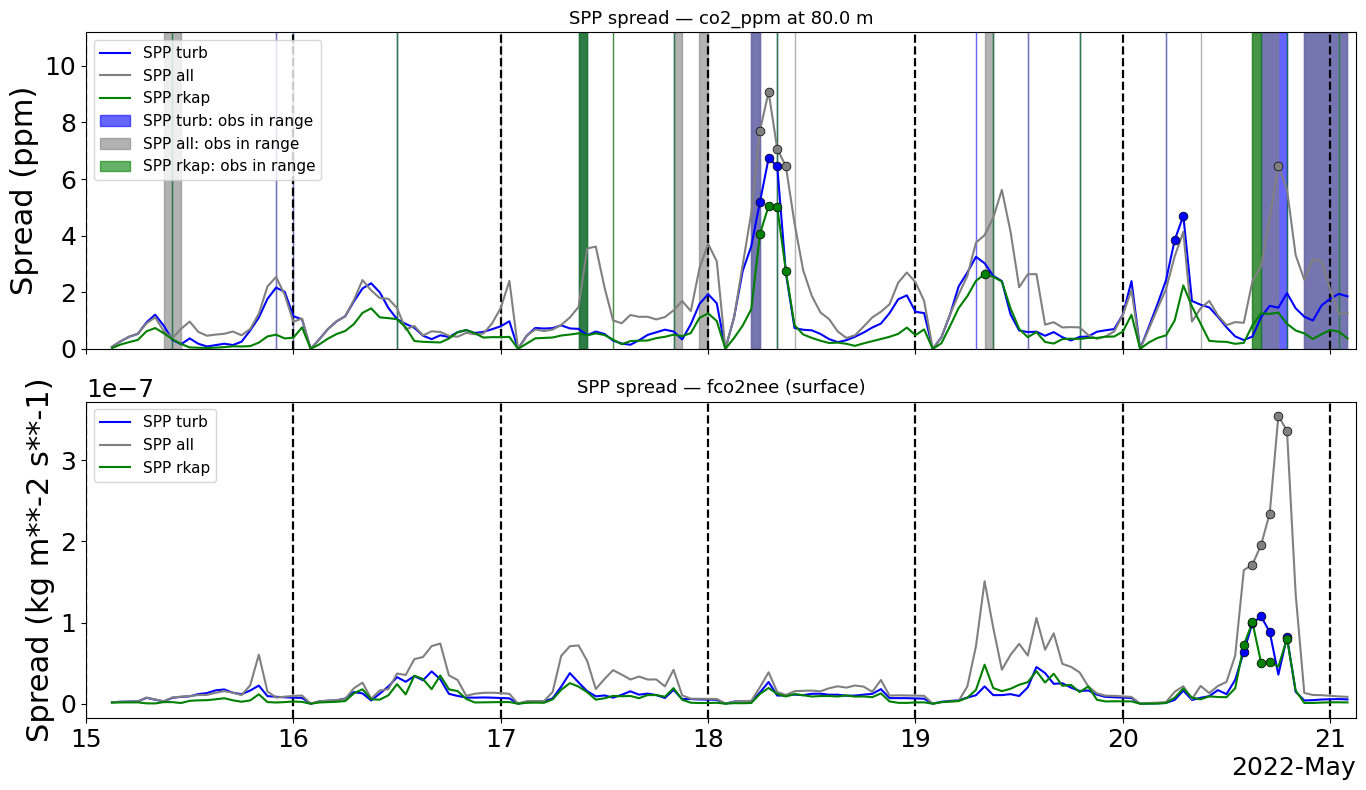

In [127]:
# Spread timeseries of SPP members (max - min) for two variables:
#   Panel 1: a 3D variable from IFS_nemo['slab']['z']   (e.g. co2_ppm at a given height)
#   Panel 2: a surface variable from IFS_nemo['slab']['srf'] (e.g. fco2nee)
#   Coloured shading on panel 1: for each experiment, hours where ANY Cabauw
#   tower height falls inside that experiment's ensemble [min, max].

plot_spp_exps = ['SPP_turb', 'SPP_all', 'SPP_rkap']

# --- panel 1: 3D variable ---
var_3d     = 'co2_ppm'
sel_height = 80        # metres, nearest match

# --- panel 2: surface variable ---
var_srf    = 'fco2nee'  # surface variable in IFS_nemo['slab']['srf']

top_n = 5   # top-N dates to print and highlight

# --- x-axis limits ---
xlim_start = pd.Timestamp('2022-05-15 00:00')
xlim_end   = pd.Timestamp('2022-05-21 03:00')

# Build lookup: exp → (label, color) from nemo_exp_names
nemo_meta = {exp: (label, color)
             for exp, _, label, color in nemo_exp_names
             if exp in plot_spp_exps}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

actual_height = None

for spp_exp in plot_spp_exps:
    label, color = nemo_meta.get(spp_exp, (spp_exp, None))

    # ---- Panel 1: 3D variable at sel_height ----
    if spp_exp in IFS_nemo['slab']['z']:
        da_3d = (IFS_nemo['slab']['z'][spp_exp][var_3d]
                 .sel(height=sel_height, method='nearest'))
        actual_height = float(da_3d['height'].values)
        spread_3d = da_3d.max('number') - da_3d.min('number')
        spread_3d.plot(ax=axes[0], color=color, lw=1.5, label=label)

        # top-N highlight and table
        s_sorted  = spread_3d.sortby(spread_3d, ascending=False)
        top_times = s_sorted['time'].values[:top_n]
        top_vals  = s_sorted.values[:top_n]
        axes[0].scatter(top_times, top_vals, color=color, zorder=5, s=40,
                        edgecolors='k', linewidths=0.5)

        print(f"\nTop {top_n} — {label} | {var_3d} at {actual_height} m:")
        print(f"  {'Rank':<5}{'Time':<22}{'Spread'}")
        print(f"  {'-'*40}")
        for rank, (t, s) in enumerate(zip(top_times, top_vals), 1):
            print(f"  {rank:<5}{str(t)[:19]:<22}{s:.4f}")

    # ---- Panel 2: surface variable ----
    if spp_exp in IFS_nemo['slab']['srf']:
        da_srf = IFS_nemo['slab']['srf'][spp_exp][var_srf]
        spread_srf = da_srf.max('number') - da_srf.min('number')
        spread_srf.plot(ax=axes[1], color=color, lw=1.5, label=label)

        s_sorted  = spread_srf.sortby(spread_srf, ascending=False)
        top_times = s_sorted['time'].values[:top_n]
        top_vals  = s_sorted.values[:top_n]
        axes[1].scatter(top_times, top_vals, color=color, zorder=5, s=40,
                        edgecolors='k', linewidths=0.5)

        print(f"\nTop {top_n} — {label} | {var_srf} (surface):")
        print(f"  {'Rank':<5}{'Time':<22}{'Spread'}")
        print(f"  {'-'*40}")
        for rank, (t, s) in enumerate(zip(top_times, top_vals), 1):
            print(f"  {rank:<5}{str(t)[:19]:<22}{s:.4e}")

# --- Cabauw obs within ensemble range — coloured shading per experiment ---
# For each SPP experiment: shade in the experiment's colour at every time step
# where ANY of the 4 Cabauw tower heights is inside that experiment's [min, max].
_cabauw_heights = np.array([27, 67, 127, 207])
# _cabauw_heights = np.array([ 67, 127])

for spp_exp in plot_spp_exps:
    if spp_exp not in IFS_nemo['slab']['z'] or actual_height is None:
        continue

    label, color = nemo_meta.get(spp_exp, (spp_exp, 'grey'))

    da_shad       = IFS_nemo['slab']['z'][spp_exp][var_3d].sel(height=sel_height, method='nearest')
    h_actual_shad = float(da_shad['height'].values)

    # --- bias correction ---
    # Use the nearest Cabauw obs height to the model height,
    # ensemble mean (not just member 0), over overlapping times only.
    nearest_obs_h = _cabauw_heights[np.argmin(np.abs(_cabauw_heights - h_actual_shad))]
    obs_for_bias  = ds_cabauw['Cabauw_CO2_May2022'][f'co2_{nearest_obs_h}m']
    mod_times_idx = pd.DatetimeIndex(da_shad['time'].values)
    obs_aligned   = obs_for_bias.to_series().reindex(mod_times_idx, method='nearest',
                                                     tolerance=pd.Timedelta('31min'))
    valid_mask = obs_aligned.notna()
    if valid_mask.any():
        mod_mean = float(da_shad.mean('number').values[valid_mask.values].mean())
        obs_mean = float(obs_aligned[valid_mask].values.mean())
        da_shad  = da_shad - (mod_mean - obs_mean)
        print(f"Bias correction for {label}: using obs at {nearest_obs_h} m, "
              f"bias = {mod_mean - obs_mean:.4f} ppm ({valid_mask.sum()} common times)")

    mod_min   = da_shad.min('number')
    mod_max   = da_shad.max('number')
    mod_times = pd.DatetimeIndex(mod_min['time'].values)

    any_within = np.zeros(len(mod_times), dtype=bool)
    for h in _cabauw_heights:
        obs_series    = ds_cabauw['Cabauw_CO2_May2022'][f'co2_{h}m'].to_series()
        obs_reindexed = obs_series.reindex(mod_times, method='nearest',
                                           tolerance=pd.Timedelta('31min'))
        in_range = (obs_reindexed.values >= mod_min.values) & \
                   (obs_reindexed.values <= mod_max.values)
        any_within |= in_range

    n_within = int(np.sum(any_within))
    print(f"\nAny Cabauw height inside {label} ({spp_exp}) range: "
          f"{n_within} / {len(mod_times)} time steps")

    axes[0].fill_between(
        mod_times, 0, 1,
        where=any_within,
        transform=axes[0].get_xaxis_transform(),
        color=color, alpha=0.6, zorder=0,
        label=f'{label}: obs in range',
    )

# --- midnight vertical lines ---
midnight = xlim_start.normalize()
while midnight <= xlim_end:
    for ax in axes:
        ax.axvline(midnight, color='k', lw=1.6, ls='--', zorder=0)
    midnight += pd.Timedelta('1D')

# --- axis styling ---
units_3d  = IFS_nemo['']['z'][plot_spp_exps[0]][var_3d].attrs.get('units', 'ppm')
units_srf = IFS_nemo['']['srf'][plot_spp_exps[0]][var_srf].attrs.get('units', '')

axes[0].set_title(f'SPP spread — {var_3d} at {actual_height} m', fontsize=13)
axes[0].set_ylabel(f'Spread ({units_3d})' if units_3d else 'Spread')
axes[0].set_xlabel('')
axes[0].legend(fontsize=11)
axes[0].set_xlim(xlim_start, xlim_end)
axes[0].set_ylim(0, None)

axes[1].set_title(f'SPP spread — {var_srf} (surface)', fontsize=13)
axes[1].set_ylabel(f'Spread ({units_srf})' if units_srf else 'Spread')
axes[1].set_xlabel('')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()


plotting SPP_all for variable co2_ppm
plotting SPP_turb for variable co2_ppm
plotting SPP_rkap for variable co2_ppm


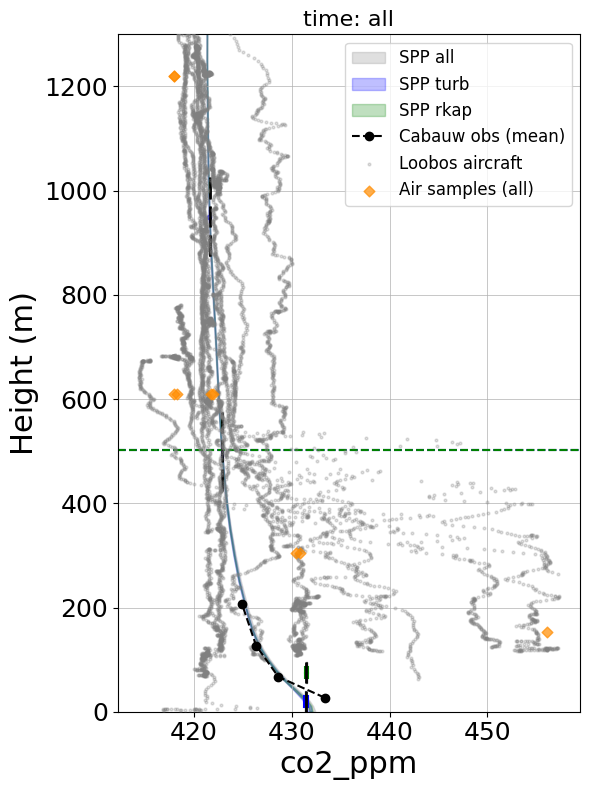

In [141]:
var_nemo = 'co2_ppm'
var_fc  = 'co2'
# var_nemo = 't'
# var_fc  = 'T'
time = 'all'  # or specify a time like '2022-05-16 23:00:00'
# time = '2022-05-18 06:00:00'
region = 'slab'  # or 'cabauw' or 'loobos'

plot_spp_exps = ['SPP_turb', 'SPP_all', 'SPP_rkap']

plot_exps     = ['ctrl_49r2b','half_diff_stable']
plot_exps     = []


box_heights = [20, 500, 1000, 2000]  # heights (m) at which to draw boxplots
box_offset  = 55   # vertical spacing (m) between experiments at same height

plot_memebr0 = False
# --- observation options ---
plot_obs_cabauw   = True   # overlay Cabauw tower CO2 profile (4 heights)
plot_obs_aircraft = True  # overlay Loobos Aircraft_co2_mol (continuous flight)
plot_obs_airsamples = True # overlay Loobos airsamples_vertical_all (discrete flask)
obs_tol = pd.Timedelta('38min')   # tolerance for Cabauw time matching

fig, ax = plt.subplots(figsize=(6, 8))

active_exps = [(exp, label, color)
               for exp, _, label, color in nemo_exp_names
               if exp in plot_spp_exps]
n_exps = len(active_exps)

for i_exp, (exp, label, color) in enumerate(active_exps):
    print(f"plotting {exp} for variable {var_nemo}")

    if time == 'all':
        spp_data = (IFS_nemo[region]['z'][exp][var_nemo]
                    .sel(height=slice(0, 3000))
                    .mean('time'))
    else:
        spp_data = (IFS_nemo[region]['z'][exp][var_nemo]
                    .sel(height=slice(0, 3000))
                    .sel(time=time))

    # --- shaded min/max envelope ---
    spp_min = spp_data.min('number')
    spp_max = spp_data.max('number')
    ax.fill_betweenx(
        spp_min['height'].values,
        spp_min.values,
        spp_max.values,
        color=color, alpha=0.25, label=label,
    )

    # --- member-0 line ---
    member0 = spp_data.sel(number=0)
    if plot_memebr0:
        member0.plot(y='height', c=color, lw=1.5, ax=ax, add_legend=False)
    blh_sel = IFS_nemo[region]['srf'][exp]['blh'].sel(time=time, number=0) if time != 'all' \
                else IFS_nemo[region]['srf'][exp]['blh'].sel(number=0).mean('time')
    ax.axhline(float(blh_sel), color=color, lw=1.5, ls='--')

    # --- horizontal boxplots at predefined heights ---
    heights_arr = spp_data['height'].values
    for h_target in box_heights:
        h_idx    = int(np.argmin(np.abs(heights_arr - h_target)))
        h_actual = float(heights_arr[h_idx])
        members  = spp_data.isel(height=h_idx).values   # (n_members,)

        # offset each experiment so boxes don't overlap
        y_pos = h_actual + (i_exp - (n_exps - 1) / 2) * box_offset

        ax.boxplot(
            members,
            positions=[y_pos],
            vert=False,
            widths=box_offset * 0.75,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.55),
            medianprops=dict(color='k', lw=2),
            whiskerprops=dict(color=color, lw=1.5),
            capprops=dict(color=color, lw=1.5),
            flierprops=dict(marker='o', markerfacecolor=color,
                            markeredgecolor=color, markersize=3, alpha=0.6),
            manage_ticks=False,
        )

# ------------------------------------------------------------
# Deterministic forecasts
# ------------------------------------------------------------
for exp,_, label, color in exp_names:
    if exp in plot_exps:
        _ctrl = IFS[region]['z'][exp][var_fc].sel(height=slice(0, 3000))
        _srf  = IFS[region]['srf'][exp]
        if time == 'all':
            _ctrl.mean('time').plot(y='height', c=color, label=label, ax=ax)
            ax.axhline(float(_srf['blh'].mean('time')), color=color, lw=1, ls='--')
        else:
            _ctrl.sel(time=time).plot(y='height', c=color, label=label, ax=ax)
            ax.axhline(float(_srf['blh'].sel(time=time)), color=color, lw=1, ls='--')

# ------------------------------------------------------------
# Cabauw tower CO2 observations (4-level tower: 27/67/127/207 m)
# ------------------------------------------------------------
if plot_obs_cabauw:
    obs_ds = ds_cabauw['Cabauw_CO2_May2022']
    _cabauw_heights = np.array([27, 67, 127, 207])

    if time == 'all':
        obs_vals = np.array([float(obs_ds[f'co2_{z}m'].mean('time').values)
                             for z in _cabauw_heights])
        ax.plot(obs_vals, _cabauw_heights, 'ko--', lw=1.5, ms=6,
                label='Cabauw obs (mean)', zorder=6)
    else:
        t_target  = pd.Timestamp(time)
        obs_times = pd.DatetimeIndex(obs_ds['time'].values)
        dt_vals   = np.abs(obs_times - t_target)
        idx       = int(dt_vals.argmin())
        if dt_vals[idx] <= obs_tol:
            obs_vals = np.array([float(obs_ds[f'co2_{z}m'].isel(time=idx).values)
                                 for z in _cabauw_heights])
            ax.plot(obs_vals, _cabauw_heights, 'ko--', lw=1.5, ms=6,
                    label=f'Cabauw obs ({str(obs_times[idx])[:16]})', zorder=6)
        else:
            print(f"No Cabauw obs within {obs_tol} of {time} (nearest: {dt_vals[idx]})")

# ------------------------------------------------------------
# Loobos Aircraft_co2_mol — continuous flight data, selected by leg
#   'all'         → scatter all legs
#   specific time → find the leg whose mid-time is closest; plot that leg
# ------------------------------------------------------------
if plot_obs_aircraft:
    air_ds = ds_loobos['Aircraft_co2_mol']

    if time == 'all':
        for leg in leg_names:
            sel = air_ds.sel(date=slice(legs[leg][0], legs[leg][1]))
            ax.scatter(sel['CO2_7815'].values, sel['Alt'].values,
                       c='grey', s=4, alpha=0.25,
                       label='Loobos aircraft' if leg == leg_names[0] else None,
                       zorder=5)
    else:
        t_target = pd.Timestamp(time)
        dt_legs  = {leg: abs(midd_times[leg] - t_target) for leg in leg_names}
        best_leg = min(dt_legs, key=dt_legs.get)
        best_dt  = dt_legs[best_leg]
        if best_dt <= obs_tol:
            sel = air_ds.sel(date=slice(legs[best_leg][0], legs[best_leg][1]))
            ax.scatter(sel['CO2_7815'].values, sel['Alt'].values,
                       c='grey', s=18, alpha=0.8,
                       label=f'Aircraft {best_leg} ({str(midd_times[best_leg])[:16]})',
                       zorder=5)
        else:
            print(f"No aircraft leg within {obs_tol} of {time} "
                  f"(nearest: {best_leg} at {best_dt})")

# ------------------------------------------------------------
# Loobos airsamples_vertical_all — discrete flask samples
#   columns: time (index), height_m, CO2 (ppm)
#   'all'         → scatter all samples
#   specific time → scatter samples within obs_tol, or nearest leg mid-time
# ------------------------------------------------------------
if plot_obs_airsamples:
    samp_ds = ds_loobos['airsamples_vertical_all']

    if time == 'all':
        ax.scatter(samp_ds['CO2'].values, samp_ds['height_m'].values,
                   marker='D', c='darkorange', s=30, alpha=0.7,
                   label='Air samples (all)', zorder=6)
    else:
        t_target   = pd.Timestamp(time)
        samp_times = pd.DatetimeIndex(samp_ds['time'].values)
        dt_samp    = np.abs(samp_times - t_target)
        mask_samp  = dt_samp <= obs_tol
        if mask_samp.sum() > 0:
            ax.scatter(samp_ds['CO2'].values[mask_samp],
                       samp_ds['height_m'].values[mask_samp],
                       marker='D', c='darkorange', s=50, alpha=0.9,
                       label=f'Air samples (±{obs_tol})', zorder=6)
        else:
            dt_legs  = {leg: abs(midd_times[leg] - t_target) for leg in leg_names}
            best_leg = min(dt_legs, key=dt_legs.get)
            t_leg    = midd_times[best_leg]
            dt_samp2 = np.abs(samp_times - t_leg)
            mask2    = dt_samp2 <= obs_tol
            if mask2.sum() > 0:
                ax.scatter(samp_ds['CO2'].values[mask2],
                           samp_ds['height_m'].values[mask2],
                           marker='D', c='darkorange', s=50, alpha=0.9,
                           label=f'Air samples ({best_leg})', zorder=6)
            else:
                print(f"No air samples within {obs_tol} of {time} or leg {best_leg}")

ax.set_ylim([0, 1300])
ax.set_xlabel(var_nemo)
ax.set_ylabel('Height (m)')
ax.set_title(f'time: {time}', fontsize=16)
ax.legend()
ax.grid(True, which='both', lw=0.5)
plt.tight_layout()
plt.show()


In [27]:
### Diurnal cycle of concentration and surface sources ###
#############################################

# --- Common times between IFS and Cabauw obs ---
def drop_duplicate_times(ds):
    """Remove duplicate timestamps from an xarray Dataset or DataArray."""
    _, unique_idx = np.unique(ds['time'], return_index=True)
    return ds.isel(time=np.sort(unique_idx))


IFS_ctrl_srf = drop_duplicate_times(IFS['cabauw']['srf']['ctrl'])
IFS_ctrl_z   = drop_duplicate_times(IFS['cabauw']['z']['ctrl'])

obs_ds = drop_duplicate_times(obs_ds)


common_times = np.intersect1d(IFS_ctrl_srf.time.values, obs_ds.time.values)

IFS_ctrl_srf = IFS_ctrl_srf.sel(time=common_times)
IFS_ctrl_z = IFS_ctrl_z.sel(time=common_times)
obs_ds = obs_ds.sel(time=common_times)


# --- Compute BLH and selected height ---
blh = IFS_ctrl_srf['blh']
h_sel = xr.where(blh < 200, blh, 200)

# Compute absolute differences between BLH/200 and each Cabauw height
diffs = np.abs(h_sel.expand_dims(cabauw_height=cabauw_heights_da) - cabauw_heights_da)

# Get index of nearest Cabauw level for each time
idx_min = diffs.argmin(dim="cabauw_height")

# Convert indices to actual heights
closest_obs_height = xr.DataArray(
    cabauw_heights_da[idx_min].values,
    coords={"time": h_sel["time"]},
    dims="time"
)

# --- Interpolate IFS CO₂ to h_sel or nearest obs height ---
co2_profile = IFS_ctrl_z['co2']
co2_at_h = co2_profile.interp(height=closest_obs_height)

# --- Select corresponding observation variable dynamically ---
obs_var_list = [f"co2_{int(h)}m" for h in cabauw_heights]

# Build an observation series matched in time
obs_matched = xr.full_like(co2_at_h, np.nan)
for t in obs_ds.time:
    h_now = float(closest_obs_height.sel(time=t))
    obs_var = f"co2_{int(h_now)}m"
    if obs_var in obs_ds:
        obs_matched.loc[dict(time=t)] = obs_ds[obs_var].sel(time=t)

# --- Get NEE ---
nee = -IFS_ctrl_srf['fco2nee']
antropogenic_flux = input['co2_antrop_emission']
ifs_tot_co2_flx = (-IFS_ctrl_z['co2flx_diff']).sel(height=0)
obs_tot_co2_flx = ds_cabauw['obs_surf_flx']['FC']

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# === CO₂ concentration ===
ax = axs[0]
co2_at_h.groupby('time.hour').mean().plot(ax=ax, lw=2.3, color='tab:blue', label='IFS CO₂')
obs_matched.groupby('time.hour').mean().plot(ax=ax, lw=2.3, color='tab:orange', label='Cabauw obs')
ax.set_title('CO₂ concentration at min(BLH, 200 m) or nearest observed height')
ax.set_ylabel('CO₂ (ppm)')
ax.set_xlim(-0.1, 24.1)
ax.grid(); ax.legend()

# === NEE ===
ax = axs[1]
# nee.groupby('time.hour').mean().plot(ax=ax, lw=1.5,ls='--', color='tab:green', label='IFS NEE')
# antropogenic_flux.groupby('time.hour').mean().plot(ax=ax, lw=1.5,ls='--', color='tab:red', label='Anthropogenic emission (wrong units!)')
ifs_tot_co2_flx.groupby('time.hour').mean().plot(ax=ax, lw=1.5,ls='--', color='tab:red', label='Total emission ')
obs_tot_co2_flx.groupby('time.hour').mean().plot(ax=ax, lw=2.3, color='tab:orange', label='Cabauw obs')
ax.set_title('Sources of CO₂ at the surface')
ax.set_ylabel('Flux (μmol m⁻² s⁻¹)')
ax.set_xlabel('Hour of day')
ax.axhline(0, color='k', lw=1)
ax.set_xlim(-0.1, 24.1)
ax.grid(); ax.legend()

plt.tight_layout()
plt.show()


NameError: name 'obs_ds' is not defined

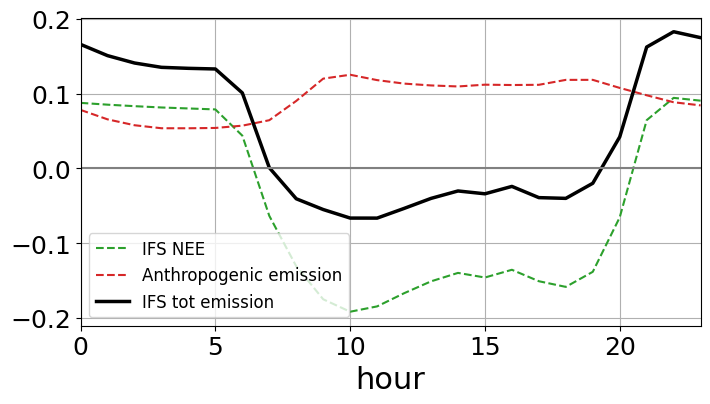

In [57]:
nee = -IFS_ctrl_srf['fco2nee']
antropogenic_flux = mfun.concentration_to_ppm('co2',input['co2_antrop_emission'])
plt.figure(figsize=(8,4))
nee.groupby('time.hour').mean().plot( lw=1.5,ls='--', color='tab:green', label='IFS NEE')
antropogenic_flux.groupby('time.hour').mean().plot(lw=1.5,ls='--', color='tab:red', label='Anthropogenic emission')
(nee.groupby('time.hour').mean()+antropogenic_flux.groupby('time.hour').mean()).plot( lw=2.5,ls='-', color='k', label='IFS tot emission')
plt.axhline(0,c='grey')
plt.grid()
plt.xlim(0,23)
plt.legend()

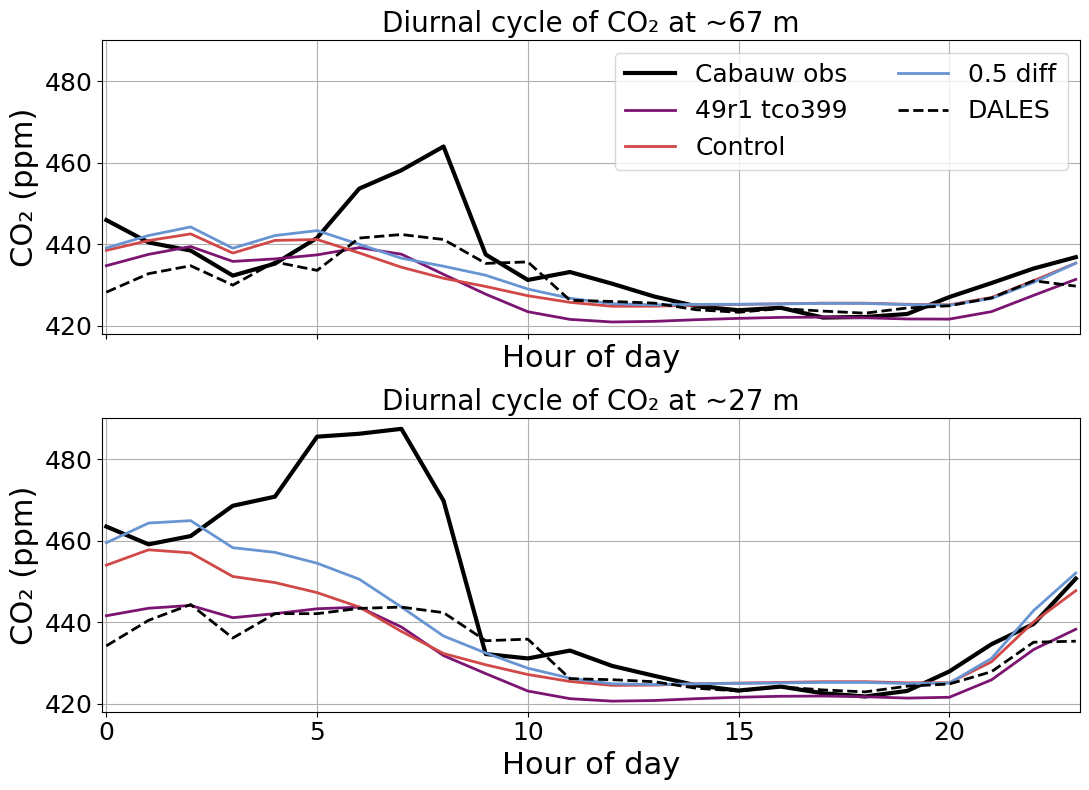

In [96]:
### Diurnal cycle of concentration at Cabauw (two heights)
# --------------------------------------------
# Settings
# --------------------------------------------
plot_exps = ['ctrl','ctrl_49r2b','half_diffusion']
cabauw_heights = np.array([27, 67, 127, 207])
site_key = 'cabauw'

obs_ds = ds_cabauw['Cabauw_CO2_May2022']
cabauw_time = obs_ds['time'].sel(time=slice('2022-05-16T02:00', '2022-05-21T00:00'))
obs_ds = obs_ds.sel(time=cabauw_time)

# Target heights: top=200 m (uses nearest obs level), bottom=27 m
target_heights = [67, 27]

# Use only times common to all datasets we plot
common_times = cabauw_time.values
dales_ds = globals().get('dales_cabauw', None)
dales_co2_var = None
if dales_ds is not None:
    for cand in ['sv004_ppm', 'co2_ppm', 'co2']:
        if cand in dales_ds.data_vars:
            dales_co2_var = cand
            break
    if dales_co2_var is not None:
        common_times = np.intersect1d(common_times, dales_ds['time'].values)

# --------------------------------------------
# Prepare figure: 2 subplots (top ~200 m, bottom 27 m)
# --------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11, 8), sharex=True)

for ax, z_target in zip(axes, target_heights):
    # Observations: pick nearest available tower level
    z_obs = float(cabauw_heights[np.argmin(np.abs(cabauw_heights - z_target))])
    obs_var = f'co2_{int(z_obs)}m'
    obs_diurnal = obs_ds[obs_var].sel(time=common_times).groupby('time.hour').mean('time')
    obs_diurnal.plot(x='hour', ax=ax, label=f'Cabauw obs', color='k', lw=3)

    # IFS experiments
    for ie, (exp, exp_longname, label, color) in enumerate(exp_names):
        if exp not in plot_exps:
            continue
        ifs_da = IFS[site_key]['z'][exp]['co2'].sel(time=common_times)
        # Prefer interpolation to requested height (e.g., 200 m)
        ifs_at_z = ifs_da.interp(height=float(z_target))
        ifs_diurnal = ifs_at_z.groupby('time.hour').mean('time')
        ifs_diurnal.plot(x='hour', ax=ax, label=f'{label}', color=color, lw=2)

    # DALES (optional)
    if (dales_ds is not None) and (dales_co2_var is not None):
        dales_da = dales_ds[dales_co2_var].sel(time=common_times)
        if 'zt' in dales_da.dims or 'zt' in dales_da.coords:
            dales_at_z = dales_da.sel(zt=float(z_target), method='nearest')
        else:
            dales_at_z = dales_da
        dales_diurnal = dales_at_z.groupby('time.hour').mean('time')
        dales_diurnal.plot(x='hour', ax=ax, label=f'DALES ', color='k', lw=2,ls='--')

    ax.set_xlim(-0.1, 23.1)
    ax.set_ylim(418,490)
    ax.grid(True)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('CO₂ (ppm)')
    ax.set_title(f'Diurnal cycle of CO₂ at ~{int(z_target)} m',fontsize=20)

# One legend (top axis)
axes[0].legend(ncol=2, fontsize=18)
plt.tight_layout()
plt.show()

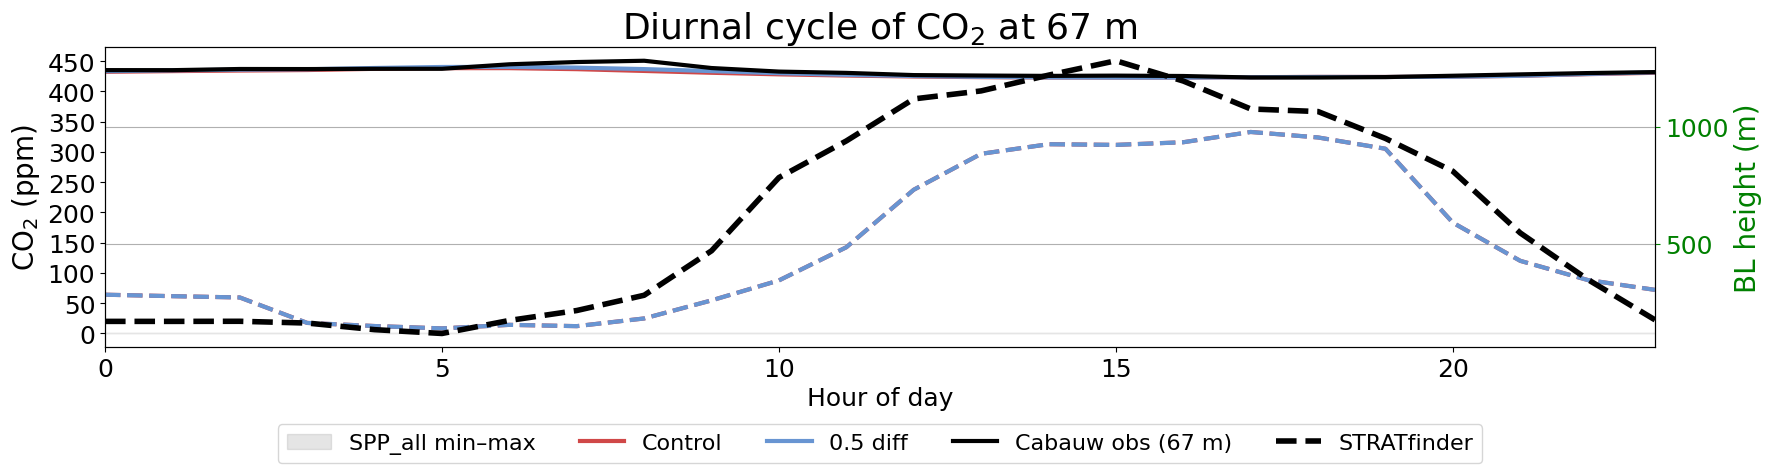

In [54]:
plot_exps = ['ctrl','ctrl_49r2b','TKEv2']  # experiments to plot
plot_exps = ['ctrl_49r2b','half_diffusion']

var = 'co2'
site_key = 'cabauw'
z_target = 67.0  # 2nd Cabauw tower level (m)

ds_z = IFS[site_key]['z']
ds_srf = IFS[site_key]['srf']
unit_conc = IFS['slab']['z'][plot_exps[0]][var].attrs.get('units', '')  # Default to an empty string if 'units' is missing

# Observations: Cabauw CO2 at 67 m
obs_ds = ds_cabauw['Cabauw_CO2_May2022']
cabauw_time = obs_ds['time'].sel(time=slice('2022-05-15T02:00', '2022-05-21T00:00'))
obs_ds = obs_ds.sel(time=cabauw_time)
obs_var = 'co2_67m'

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), sharex=True)
ax2 = axes.twinx()

# --------------------------------------------
# NEMO/ensemble envelope (min-max) at 67 m
# --------------------------------------------
try:
    nemo_exp = nemo_exp_names[0][0]  # e.g. 'SPP_all'
    nemo_color = nemo_exp_names[0][3] if len(nemo_exp_names[0]) >= 4 else 'grey'
    nemo_ds_z = IFS_nemo.get(site_key, {}).get('z', {}).get(nemo_exp, None)
    if nemo_ds_z is not None and var in nemo_ds_z:
        nemo_da = nemo_ds_z[var]
        if 'height' in nemo_da.dims or 'height' in nemo_da.coords:
            nemo_at_z = nemo_da.interp(height=z_target)
        else:
            nemo_at_z = nemo_da
        nemo_hr = nemo_at_z.groupby('time.hour').mean('time', skipna=True)
        if 'number' in nemo_hr.dims:
            nemo_min = nemo_hr.min('number', skipna=True)
            nemo_max = nemo_hr.max('number', skipna=True)
            axes.fill_between(
                nemo_hr['hour'].values,
                nemo_min.values,
                nemo_max.values,
                color=nemo_color,
                alpha=0.20,
                label=f"{nemo_exp} min–max",
            )
except Exception as e:
    print(f"Skipping NEMO min–max envelope: {e}")

# --------------------------------------------
# Model experiments (IFS)
# --------------------------------------------
for exp, _, exp_lab, color in exp_names:
    if exp not in plot_exps:
        continue
    ifs_da = ds_z[exp][var]
    if 'height' in ifs_da.dims or 'height' in ifs_da.coords:
        ifs_at_z = ifs_da.interp(height=z_target)
    else:
        ifs_at_z = ifs_da
    hourly_co2 = ifs_at_z.groupby('time.hour').mean(dim='time', skipna=True)
    hourly_srf = ds_srf[exp].groupby('time.hour').mean(dim='time', skipna=True)

    hourly_co2.plot(ax=axes, x='hour', label=exp_lab, c=color, lw=3)
    if 'blh' in hourly_srf:
        hourly_srf['blh'].plot(ax=ax2, x='hour', lw=3, c=color, ls='--')

# --------------------------------------------
# Observations (CO2 + BLH proxy)
# --------------------------------------------
if obs_var in obs_ds:
    obs_diurnal = obs_ds[obs_var].groupby('time.hour').mean('time', skipna=True)
    obs_diurnal.plot(ax=axes, x='hour', label='Cabauw obs (67 m)', color='k', lw=3)
else:
    print(f"Observation variable '{obs_var}' not found in Cabauw_CO2_May2022")

# BLH observation/proxy (STRATfinder)
blh_cabauw['MLH'].groupby('time.hour').mean(dim='time').sel(station_name='CABAUW,NETHERLANDS            ').plot(ax=ax2, c='k', ls='--', lw=4, label='STRATfinder')

# --------------------------------------------
# Cosmetics
# --------------------------------------------
axes.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
axes.set_xlim([0, 23])
axes.set_xlabel('Hour of day', fontsize=18)
axes.set_ylabel(f"CO$_2$ ({unit_conc.lower()})", fontsize=20)
ax2.set_ylabel('BL height (m)', fontsize=20, c='g')
ax2.tick_params(axis='y', colors='g')

# Remove any titles accidentally set by xarray on either axis
axes.set_title('')
ax2.set_title('')
ax2.grid()
axes.set_title(rf"Diurnal cycle of CO$_2$ at {int(z_target)} m", fontsize=26)

# Combined legend (CO2 + BLH) outside at the bottom
h1, l1 = axes.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = axes.legend(
    h1 + h2,
    l1 + l2,
    fontsize=16,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    frameon=True,
 )
fig.subplots_adjust(bottom=0.28)

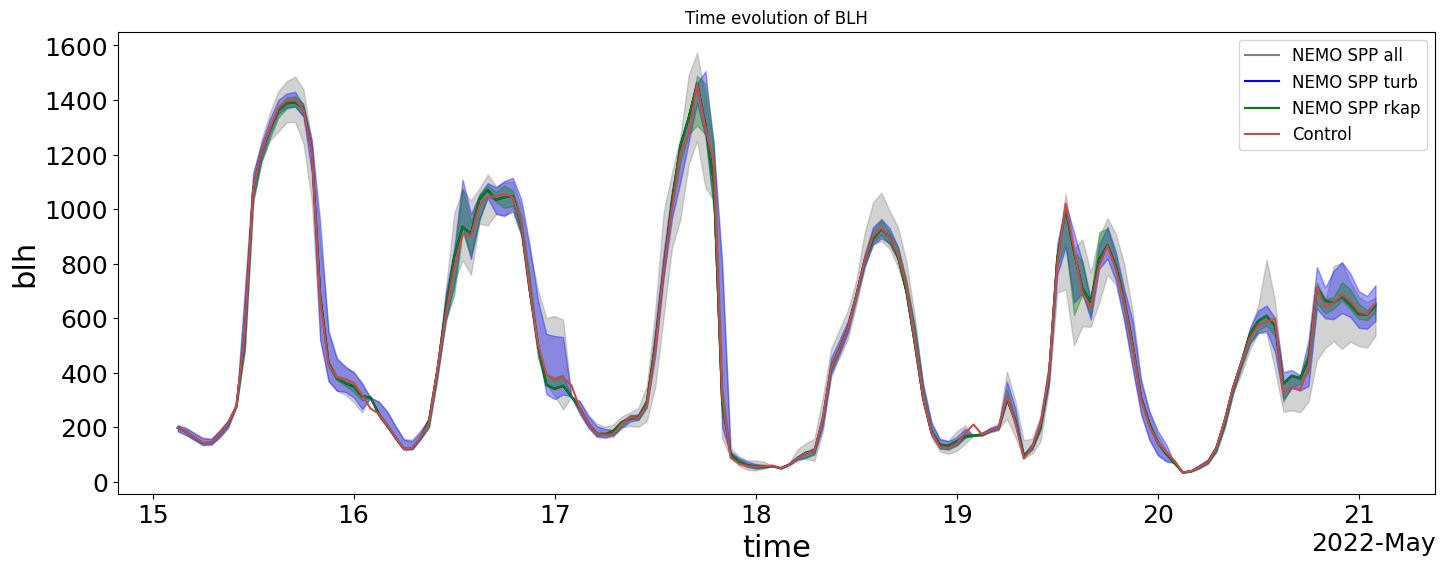

In [21]:
var = 'blh'
plot_exps = ['ctrl_49r2b']  # experiments to plot
plot_spp_exps = ['SPP_all','SPP_rkap','SPP_turb']
plt.figure(figsize=(17, 6))
for exp, _, exp_lab, color in nemo_exp_names:
    if exp not in plot_spp_exps:
        continue
    else:
        blh_nemo = IFS_nemo['cabauw']['srf'][exp][var]
        plt.fill_between(blh_nemo['time'], blh_nemo.min('number'), blh_nemo.max('number'), alpha=0.35, color=color)
        blh_nemo.sel(number=0).plot(c=color, label=f"NEMO {exp_lab}")
for exp, _, exp_lab, color in exp_names:
    if exp not in plot_exps:
        continue
    else:
        IFS['cabauw']['srf'][exp][var].plot(c=color, label=exp_lab)
plt.title(f'Time evolution of {var.upper()}')
plt.legend()
plt.show()


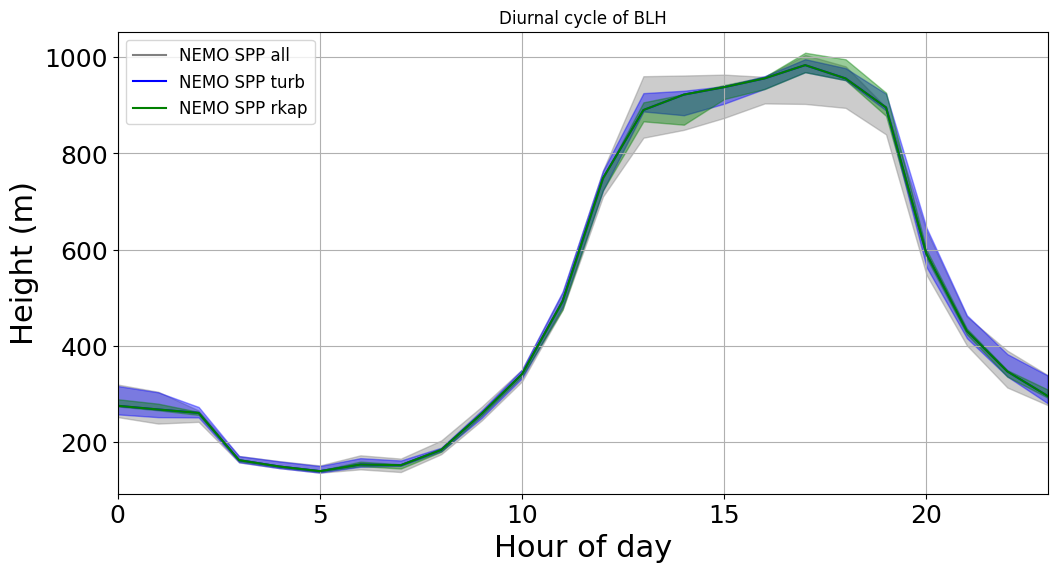

In [24]:
var = 'blh'
plot_exps = ['half_diffusion','ctrl_49r2b']  # experiments to plot
plot_exps = ['']  # experiments to plot
plot_spp_exps = ['SPP_turb','SPP_all','SPP_rkap']

plt.figure(figsize=(12, 6))
for exp, _, exp_lab, color in nemo_exp_names:
    if exp not in plot_spp_exps:
        continue
    else:
        hourly_nemo = IFS_nemo['cabauw']['srf'][exp][var].groupby('time.hour').mean('time')
        plt.fill_between(hourly_nemo['hour'], hourly_nemo.min('number'), hourly_nemo.max('number'), alpha=0.4,color=color)
        hourly_nemo.sel(number=0).plot(c=color, label=f"NEMO {exp_lab}")
for exp, _, exp_lab, color in exp_names:
    if exp not in plot_exps:
        continue
    else:
        IFS['cabauw']['srf'][exp][var].groupby('time.hour').mean('time').plot(c=color, label=exp_lab)
plt.grid()
plt.xlim(0, 23)
plt.ylabel('Height (m)')
plt.xlabel('Hour of day')
plt.title(f'Diurnal cycle of {var.upper()}')
plt.legend()
plt.show()

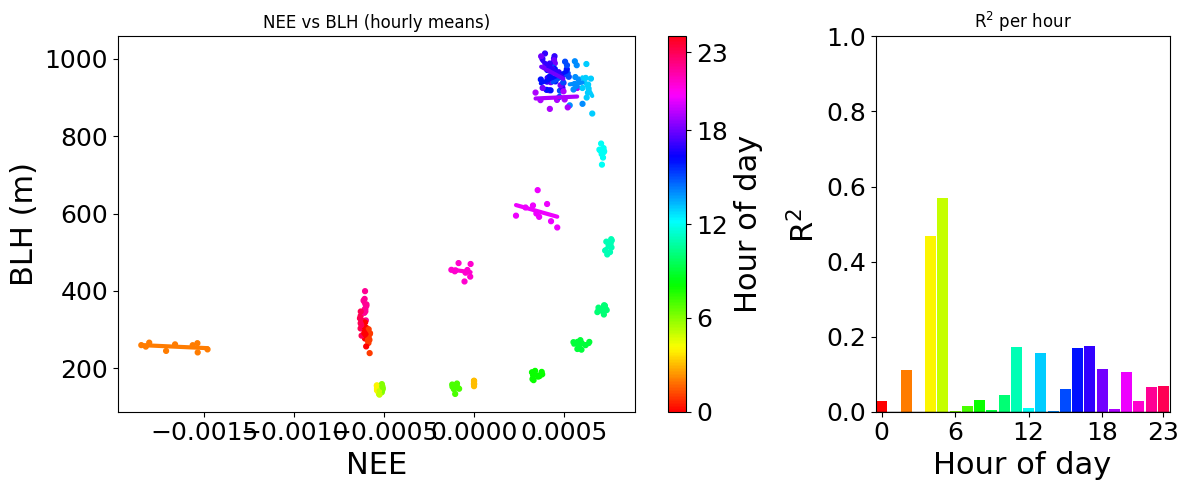

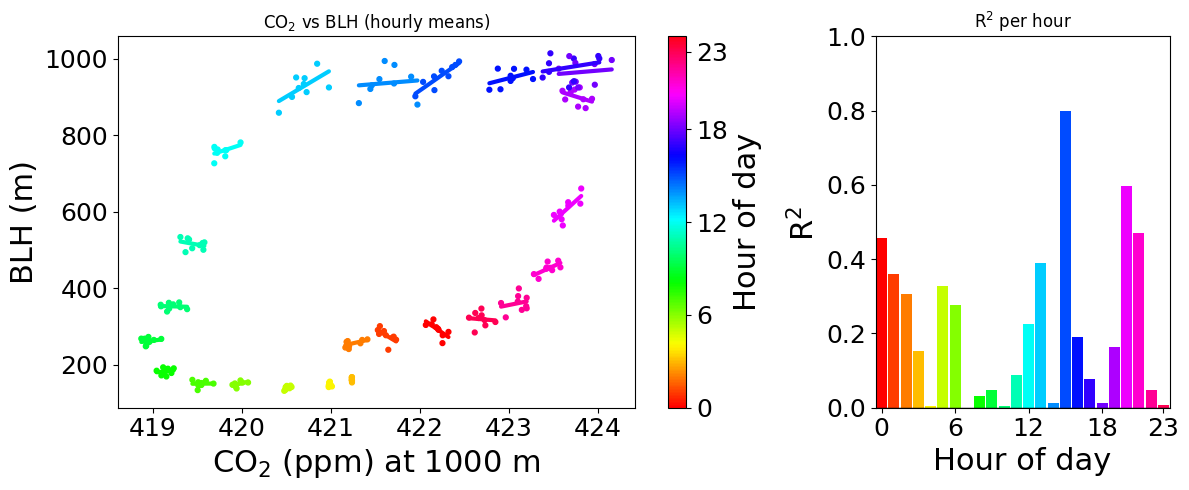

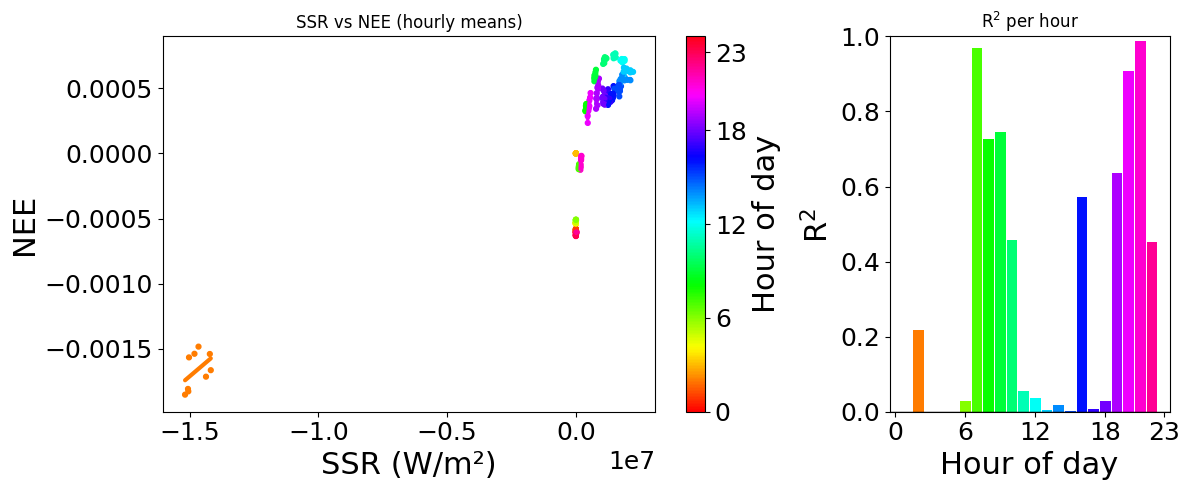

In [145]:
# correlation between NEE / CO2 and BLH (grouped by hour-of-day, colored by hour)

cmap = plt.get_cmap("hsv")  # cyclic
norm = mcolors.Normalize(vmin=0, vmax=24)  # make 0 and 24 the same color

nee = IFS_nemo['slab']['srf']['SPP_all']['aco2nee'].diff('time')
blh = IFS_nemo['slab']['srf']['SPP_all']['blh']
# co2_150 = mfun.concentration_to_ppm('co2',IFS_nemo['slab']['z']['SPP_all']['co2'].sel(height=150, method='nearest'))
co2_1000 = mfun.concentration_to_ppm('co2',IFS_nemo['slab']['z']['SPP_all']['co2'].sel(height=1000, method='nearest'))

ssr = IFS_nemo['slab']['srf']['SPP_all']['ssr'].diff('time')

nee_hr = nee.groupby('time.hour').mean('time', skipna=True)
blh_hr = blh.groupby('time.hour').mean('time', skipna=True)
# co2_hr = co2_150.groupby('time.hour').mean('time', skipna=True)
co2_hr = co2_1000.groupby('time.hour').mean('time', skipna=True)
ssr_hr = ssr.groupby('time.hour').mean('time', skipna=True)

ssr_hr = ssr_hr.where(ssr_hr['hour'] != 3, 0)
nee_hr = nee_hr.where(nee_hr['hour'] != 3, 0)


# Reduce any leftover dims but KEEP ensemble member dim ('number') if present
keep_dims = {"hour", "number"}
for d in list(nee_hr.dims):
    if d not in keep_dims:
        nee_hr = nee_hr.mean(d, skipna=True)
for d in list(blh_hr.dims):
    if d not in keep_dims:
        blh_hr = blh_hr.mean(d, skipna=True)
for d in list(co2_hr.dims):
    if d not in keep_dims:
        co2_hr = co2_hr.mean(d, skipna=True)
for d in list(ssr_hr.dims):
    if d not in keep_dims:
        ssr_hr = ssr_hr.mean(d, skipna=True)

# Align shapes (broadcast if BLH has no 'number', etc.)
nee_hr, blh_hr = xr.broadcast(nee_hr, blh_hr)
co2_hr, blh_hr2 = xr.broadcast(co2_hr, blh_hr)
ssr_hr, blh_hr3 = xr.broadcast(ssr_hr, blh_hr)

hours = nee_hr["hour"].values

def _r2_per_hour(x_mat: np.ndarray, y_mat: np.ndarray) -> np.ndarray:
    """R^2 per hour from linear fit across ensemble members."""
    n_hours = x_mat.shape[1]
    r2 = np.full(n_hours, np.nan, dtype="float64")
    for ih in range(n_hours):
        xh = x_mat[:, ih]
        yh = y_mat[:, ih]
        m = np.isfinite(xh) & np.isfinite(yh)
        if m.sum() < 2:
            continue
        xh = xh[m]
        yh = yh[m]
        if float(np.std(yh)) == 0.0:
            continue
        if float(np.std(xh)) == 0.0:
            # no x-variation -> best fit is constant mean(y); R^2 = 0 by definition here
            r2[ih] = 0.0
            continue
        slope, intercept = np.polyfit(xh, yh, deg=1)
        yhat = slope * xh + intercept
        ss_res = float(np.sum((yh - yhat) ** 2))
        ss_tot = float(np.sum((yh - np.mean(yh)) ** 2))
        if ss_tot == 0.0:
            continue
        r2[ih] = 1.0 - (ss_res / ss_tot)
    return r2

def _scatter_and_trends(ax, x_da, y_da, title, xlabel, ylabel):
    if "number" in x_da.dims:
        x_mat = x_da.transpose("number", "hour").values
        y_mat = y_da.transpose("number", "hour").values
        x = x_mat.reshape(-1)
        y = y_mat.reshape(-1)
        c = np.tile(hours, x_da.sizes["number"])
    else:
        x_mat = x_da.values[None, :]
        y_mat = y_da.values[None, :]
        x = x_da.values
        y = y_da.values
        c = hours

    sc = ax.scatter(x, y, c=c, cmap=cmap, norm=norm, s=12)
    n_hours = x_mat.shape[1]
    for ih in range(n_hours):
        xh = x_mat[:, ih]
        yh = y_mat[:, ih]
        m = np.isfinite(xh) & np.isfinite(yh)
        if m.sum() < 2:
            continue
        xh = xh[m]
        yh = yh[m]
        x_min = float(np.min(xh))
        x_max = float(np.max(xh))
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
            continue
        slope, intercept = np.polyfit(xh, yh, deg=1)
        y_min = slope * x_min + intercept
        y_max = slope * x_max + intercept
        hour_val = float(hours[ih])
        ax.plot([x_min, x_max], [y_min, y_max], color=cmap(norm(hour_val)), lw=3, solid_capstyle="round")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return sc, x_mat, y_mat

def _plot_scatter_plus_r2(x_da, y_da, title, xlabel, ylabel):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [2.2, 1]})
    sc, x_mat, y_mat = _scatter_and_trends(ax0, x_da, y_da, title, xlabel, ylabel)
    cb = fig.colorbar(sc, ax=ax0, ticks=[0, 6, 12, 18, 23])
    cb.set_label("Hour of day")

    r2 = _r2_per_hour(x_mat, y_mat)
    bar_colors = [cmap(norm(float(h))) for h in hours]
    ax1.bar(hours, r2, color=bar_colors, width=0.9)
    ax1.axhline(0, color="k", lw=1)
    ax1.set_ylim(0, 1)
    ax1.set_xlim(-0.5, 23.5)
    ax1.set_xticks([0, 6, 12, 18, 23])
    ax1.set_xlabel("Hour of day")
    ax1.set_ylabel("R$^2$ ")
    ax1.set_title("R$^2$ per hour")

    fig.tight_layout()
    return

# --- NEE vs BLH ---
_plot_scatter_plus_r2(nee_hr, blh_hr, "NEE vs BLH (hourly means)", "NEE", "BLH (m)")

# --- CO2 vs BLH ---
_plot_scatter_plus_r2(co2_hr, blh_hr2, "CO$_2$ vs BLH (hourly means)", "CO$_2$ (ppm) at 1000 m", "BLH (m)")

# --- SSR vs NEE ---
_plot_scatter_plus_r2(ssr_hr, nee_hr, "SSR vs NEE (hourly means)", "SSR (W/m²)", "NEE")

In [ ]:
####################################

In [58]:
## needed for next plot
var = 'co2'
times = IFS['slab']['srf']['ctrl'].time
tot_tend_abl, conv_tend_abl, diff_tend_abl, dyn_tend_abl = [], [], [], []
tot_tend_blh,  conv_tend_blh,  diff_tend_blh,  dyn_tend_blh  = [], [], [], []
tot_tend_ft,  conv_tend_ft,  diff_tend_ft,  dyn_tend_ft  = [], [], [], []

correct_blh = 100

for it in times:
    it_blh = IFS['slab']['srf']['ctrl']['blh'].sel(time=it)

    tot_tend_abl.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_tot'].sel(time = it,
                                height=slice(0, max(0,it_blh-correct_blh))).mean('height'))
    tot_tend_blh.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_tot'].sel(time = it,
                                height=slice(max(0,it_blh-correct_blh),it_blh)).mean('height'))
    tot_tend_ft.append(IFS['slab']['z']['ctrl']
                       [f'd{var}dt_tot'].sel(time = it,
                                height=slice(it_blh+correct_blh, it_blh+500)).mean('height'))

    conv_tend_abl.append(IFS['slab']['z']['ctrl']
                         [f'd{var}dt_conv'].sel(time = it,
                                height=slice(0, max(0,it_blh-correct_blh))).mean('height'))
    conv_tend_blh.append(IFS['slab']['z']['ctrl']
                         [f'd{var}dt_conv'].sel(time = it,
                                height=slice(max(0,it_blh-correct_blh),it_blh)).mean('height'))
    conv_tend_ft.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_conv'].sel(time = it,
                                height=slice(it_blh+correct_blh, it_blh+500)).mean('height'))

    diff_tend_abl.append(IFS['slab']['z']['ctrl']
                         [f'd{var}dt_diff'].sel(time = it,
                                height=slice(0, max(0,it_blh-correct_blh))).mean('height'))
    diff_tend_blh.append(IFS['slab']['z']['ctrl']
                         [f'd{var}dt_diff'].sel(time = it,
                                height=slice(max(0,it_blh-correct_blh),it_blh)).mean('height'))
    diff_tend_ft.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_diff'].sel(time = it,
                                height=slice(it_blh+correct_blh, it_blh+500)).mean('height'))

    dyn_tend_abl.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_dyn'].sel(time = it,
                                height=slice(0, max(0,it_blh-correct_blh))).mean('height'))
    dyn_tend_blh.append(IFS['slab']['z']['ctrl']
                        [f'd{var}dt_dyn'].sel(time = it,
                                height=slice(max(0,it_blh-correct_blh),it_blh)).mean('height'))
    dyn_tend_ft.append(IFS['slab']['z']['ctrl']
                       [f'd{var}dt_dyn'].sel(time = it,
                                height=slice(it_blh+correct_blh, it_blh+500)).mean('height'))

# concatenate over time
tot_tend_abl = xr.concat(tot_tend_abl, dim=times)
conv_tend_abl = xr.concat(conv_tend_abl, dim=times)
diff_tend_abl = xr.concat(diff_tend_abl, dim=times)
dyn_tend_abl  = xr.concat(dyn_tend_abl,  dim=times)

tot_tend_blh = xr.concat(tot_tend_blh, dim=times)
conv_tend_blh = xr.concat(conv_tend_blh, dim=times)
diff_tend_blh = xr.concat(diff_tend_blh, dim=times)
dyn_tend_blh  = xr.concat(dyn_tend_blh,  dim=times)

tot_tend_ft = xr.concat(tot_tend_ft, dim=times)
conv_tend_ft = xr.concat(conv_tend_ft, dim=times)
diff_tend_ft = xr.concat(diff_tend_ft, dim=times)
dyn_tend_ft  = xr.concat(dyn_tend_ft,  dim=times)

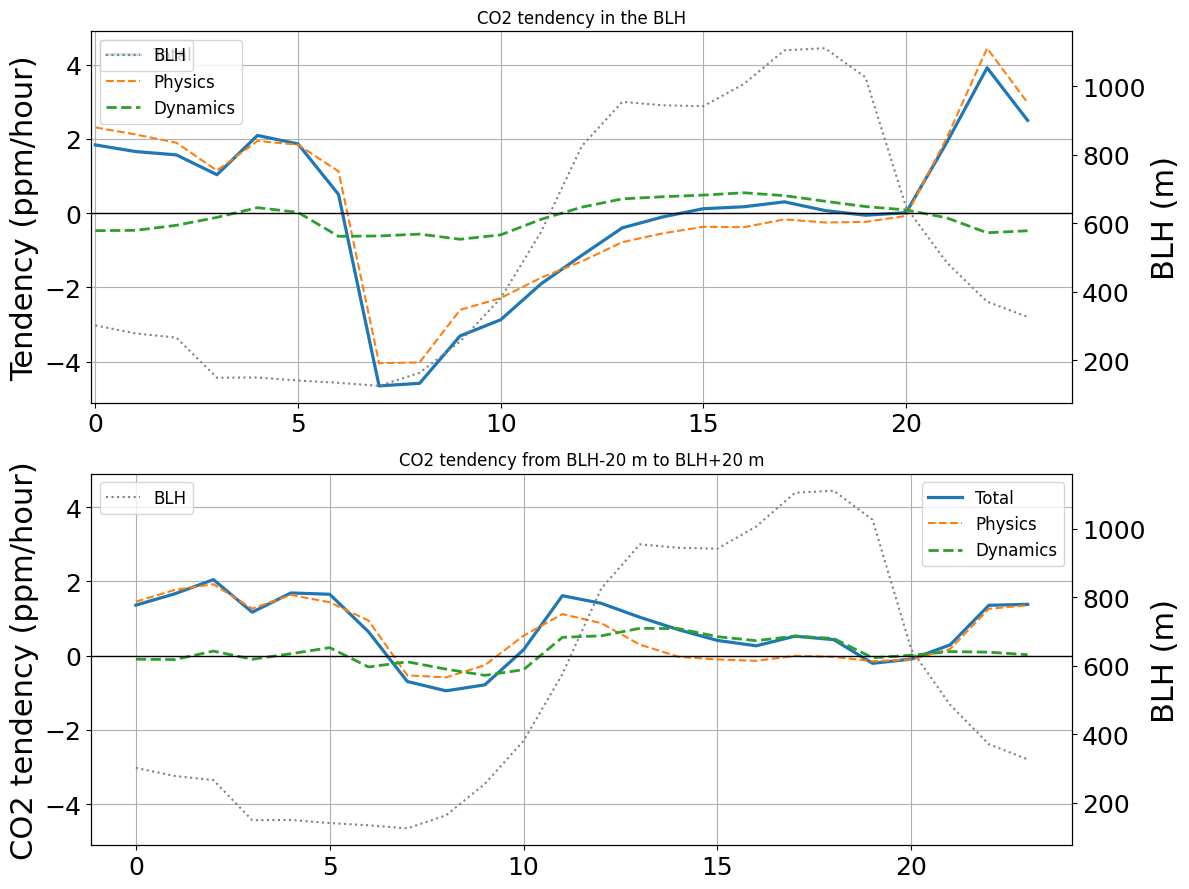

In [60]:
# Needs previous cell
# plot
fig, axs = plt.subplots(2, 1, figsize=(12,9), sharey=True)

# BLH
ax = axs[0]
tot_tend_abl.groupby('time.hour').mean().plot(ax=ax, label='Total', lw=2.3)
(diff_tend_abl + conv_tend_abl).groupby('time.hour').mean().plot(ax=ax, label='Physics', ls='--')
# diff_tend_abl.groupby('time.hour').mean().plot(ax=ax, label='Diffusion', ls='--',lw =2)
# conv_tend_abl.groupby('time.hour').mean().plot(ax=ax, label='Convection', ls='--',lw =2)
dyn_tend_abl.groupby('time.hour').mean().plot(ax=ax, label='Dynamics', ls='--',lw =2)
ax.set_title('CO2 tendency in the BLH')
ax.set_ylabel('Tendency (ppm/hour)')
ax.set_xlabel('')
ax.axhline(0, color='k', lw=1)
ax.legend(); ax.grid()
ax.set_xlim(-0.1,24.1)

# BLH±20
ax = axs[1]
tot_tend_blh.groupby('time.hour').mean().plot(ax=ax, label='Total', lw=2.3)
(diff_tend_blh + conv_tend_blh).groupby('time.hour').mean().plot(ax=ax, label='Physics', ls='--')
# diff_tend_blh.groupby('time.hour').mean().plot(ax=ax, label='Diffusion', ls='--',lw =2)
# conv_tend_blh.groupby('time.hour').mean().plot(ax=ax, label='Convection', ls='--',lw =2)
dyn_tend_blh.groupby('time.hour').mean().plot(ax=ax, label='Dynamics', ls='--',lw =2)
ax.set_title('CO2 tendency from BLH-20 m to BLH+20 m')
ax.set_ylabel('CO2 tendency (ppm/hour)')
ax.set_xlabel('')
ax.axhline(0, color='k', lw=1)
ax.legend(); ax.grid()

# # BLH–BLH+500
# ax = axs[1]
# tot_tend_ft.groupby('time.hour').mean().plot(ax=ax, label='Total', lw=2)
# (diff_tend_ft + conv_tend_ft).groupby('time.hour').mean().plot(ax=ax, label='Physics', ls='--')
# # diff_tend_ft.groupby('time.hour').mean().plot(ax=ax, label='Diffusion', ls='--')
# # conv_tend_ft.groupby('time.hour').mean().plot(ax=ax, label='Convection', ls='--')
# dyn_tend_ft.groupby('time.hour').mean().plot(ax=ax, label='Dynamics', ls='--')
# ax.set_title('CO2 tendency from BLH to BLH+500 m')
# ax.set_ylabel('Tendency (ppm/hour)')
# ax.set_xlabel('Hour of day')
# ax.axhline(0, color='k', lw=1)
# ax.legend(); ax.grid()
# ax.set_xlim(-0.1,24.1)


# on secondry y-axis, plot the mean BLH diurnal cycle
for iax in range(2):
    ax2 = axs[iax].twinx()
    mean_blh = IFS['slab']['srf']['ctrl']['blh'].groupby('time.hour').mean()
    mean_blh.plot(ax=ax2, color='grey', ls=':',lw  =1.5, label='BLH') 
    ax2.set_ylabel('BLH (m)')
    ax2.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


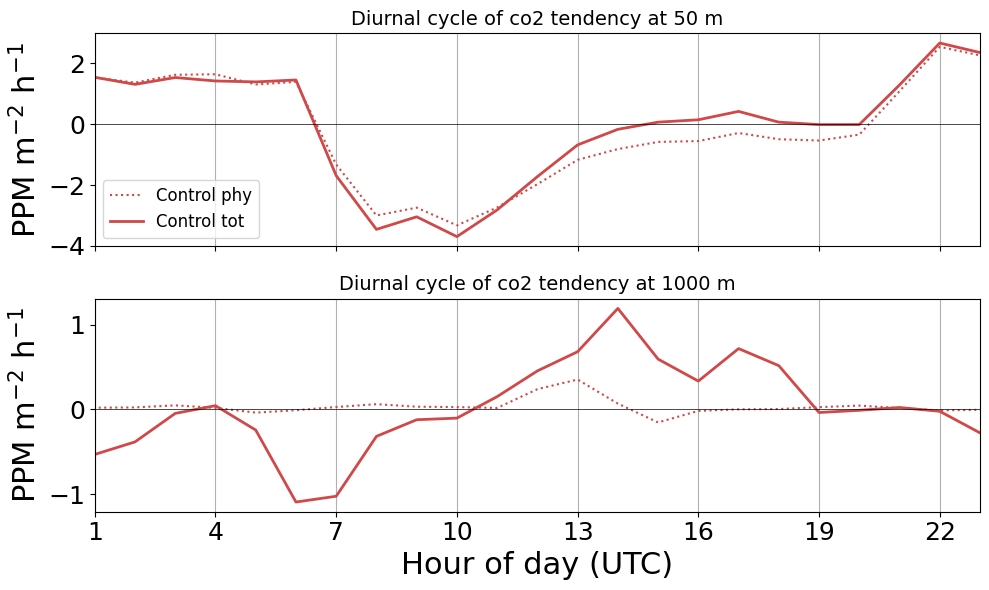

In [ ]:
### Diurnal cycle of CO₂ fluxes at Cabauw ###
heights = [50, 1000]   # heights in metres
plot_exps = ['ctrl',]       # experiments to plot
var = 'co2'
plot_flx = False
plot_tend =True

fig, axes = plt.subplots(len(heights), 1, figsize=(10, 3*len(heights)), sharex=True)

if len(heights) == 1:
    axes = [axes]

for i, h in enumerate(heights):
    ax = axes[i]

    for exp, exp_longname, label, color in exp_names:
        if exp not in plot_exps:
            continue

        ds = IFS['slab']['z'][exp]

        # select height
        if plot_flx:
            conv = ds[f'{var}flx_conv'].sel(height=h, method='nearest')
            diff = ds[f'{var}flx_diff'].sel(height=h, method='nearest')
            dyn  = ds[f'{var}flx_dyn'].sel(height=h, method='nearest')
            tot  = conv + diff + dyn
        elif plot_tend:
            conv = ds[f'd{var}dt_conv'].sel(height=h, method='nearest')
            diff = ds[f'd{var}dt_diff'].sel(height=h, method='nearest')
            dyn  = ds[f'd{var}dt_dyn'].sel(height=h, method='nearest')
            tot  = conv + diff + dyn
            

        # --- group by hour of day ---
        conv_diurnal = conv.groupby('time.hour').mean()
        diff_diurnal = diff.groupby('time.hour').mean()
        dyn_diurnal  = dyn.groupby('time.hour').mean()
        tot_diurnal  = tot.groupby('time.hour').mean()
        phy_diurnal  = (conv+diff).groupby('time.hour').mean()

        # plot
        phy_diurnal.plot(ax=ax, label=f'{label} phy', color=color, linestyle=':', lw=1.5)
        # conv_diurnal.plot(ax=ax, label=f'{label} conv', color=color, linestyle=':', lw=1.5)
        # diff_diurnal.plot(ax=ax, label=f'{label} diff', color=color, linestyle='--', lw=2)
        # dyn_diurnal.plot(ax=ax, label=f'{label} dyn', color=color, linestyle='--', lw=1.5)
        tot_diurnal.plot(ax=ax, label=f'{label} tot', color=color, linestyle='-', lw=2)

    ax.axhline(0, c='k', lw=0.5)
    unit_flx = ds[f'{var}flx_conv'].attrs.get("units", "")
    ax.set_ylabel(unit_flx)
    if plot_flx:
        ax.set_title(f'Diurnal cycle of {var} fluxes at {h} m', fontsize=14)
    elif plot_tend:
        ax.set_title(f'Diurnal cycle of {var} tendency at {h} m', fontsize=14)

    ax.grid(axis='x')
    ax.set_xlabel("")
    ax.set_xticks(range(1,24,3))  # ticks every 3 hours
    # ax.set_ylim(-0.003, 0.005)
    ax.set_xlim(1, 23)

    if i == 0:
        ax.legend(fontsize=12)
ax.set_xlabel("Hour of day (UTC)")

plt.tight_layout()
plt.show()

In [24]:
var = 'blh'
plot_exps = ['ctrl_49r2b', '9km_49r2b', 'half_diff_stable']


ctrl_var = IFS['slab']['srf'][plot_exps[0]][var]


fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for exp, exp_longname, label, color in exp_names:
    if exp not in plot_exps:
        continue
    grouped = IFS['slab']['srf'][exp][var].groupby('time.hour')
    grouped_norm = (IFS['slab']['srf'][exp][var] / ctrl_var).groupby('time.hour')
    diurnal = grouped.mean()
    diurnal_norm = grouped_norm.mean()
    # Panel 1: absolute values
    axes[0].plot(diurnal, label=exp, color=color)

# Formatting
axes[0].set_title(f"Diurnal cycle of {var}")
axes[1].set_title(f"Normalised diurnal cycle of {var}")
for ax in axes:
    ax.grid()

axes[0].legend()
axes[1].legend()
plt.xlabel("Hour of day")
plt.tight_layout()

[('ctrl_49r2b', 'iyw7_ctrl_49r2b', 'Control', '#D04848'),
 ('9km_49r2b', 'j1rw_9km_49r2b', 'tco1279', '#07AD78'),
 ('half_diffusion', 'j1kz_half_ZCFC_everywhere_49r2b', '0.5 diff', '#6895D2'),
 ('half_diff_stable',
  'j1m9_half_ZCFC_everywhere_stable',
  '0.5 diff, stable',
  '#F3B95F')]

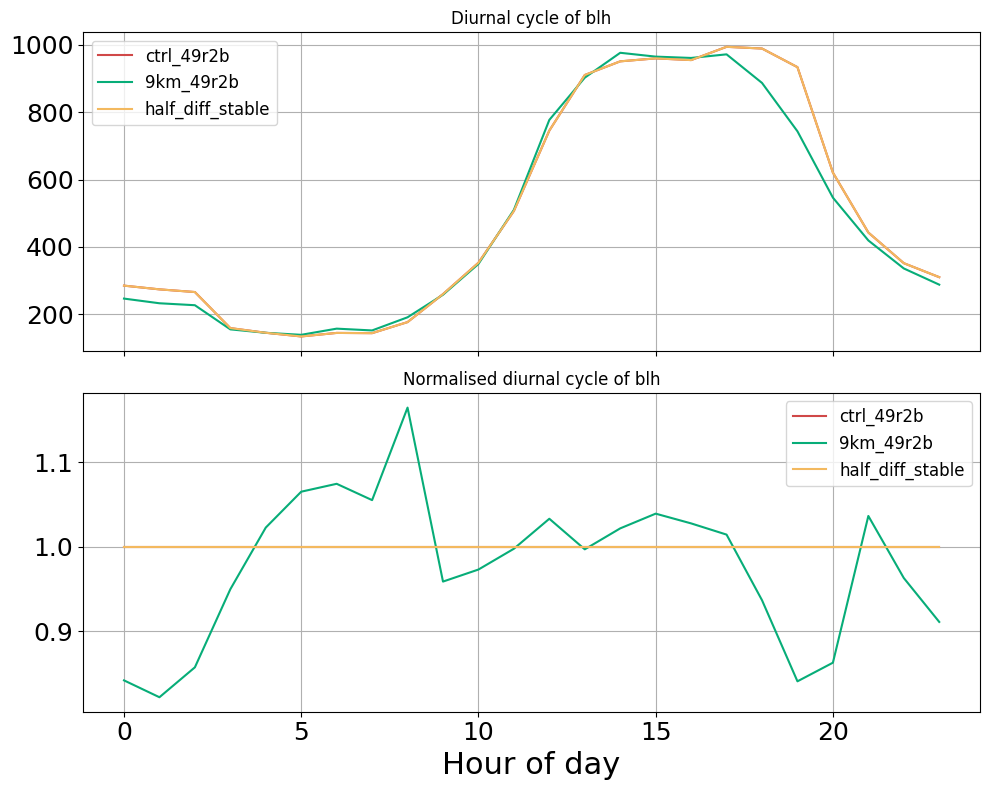

In [27]:
var = 'blh'
plot_exps = ['ctrl_49r2b', '9km_49r2b', 'half_diff_stable']

ctrl_var = IFS['slab']['srf'][plot_exps[0]][var]


fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for exp, exp_longname, label, color in exp_names:
    if exp not in plot_exps:
        continue
    grouped = IFS['slab']['srf'][exp][var].groupby('time.hour')
    grouped_norm = (IFS['slab']['srf'][exp][var] / ctrl_var).groupby('time.hour')
    diurnal = grouped.mean()
    diurnal_norm = grouped_norm.mean()
    # Panel 1: absolute values
    axes[0].plot(diurnal, label=exp, color=color)
    # Panel 2: normalised values
    axes[1].plot(diurnal_norm, label=exp, color=color)

# Formatting
axes[0].set_title(f"Diurnal cycle of {var}")
axes[1].set_title(f"Normalised diurnal cycle of {var}")
for ax in axes:
    ax.grid()

axes[0].legend()
axes[1].legend()
plt.xlabel("Hour of day")
plt.tight_layout()



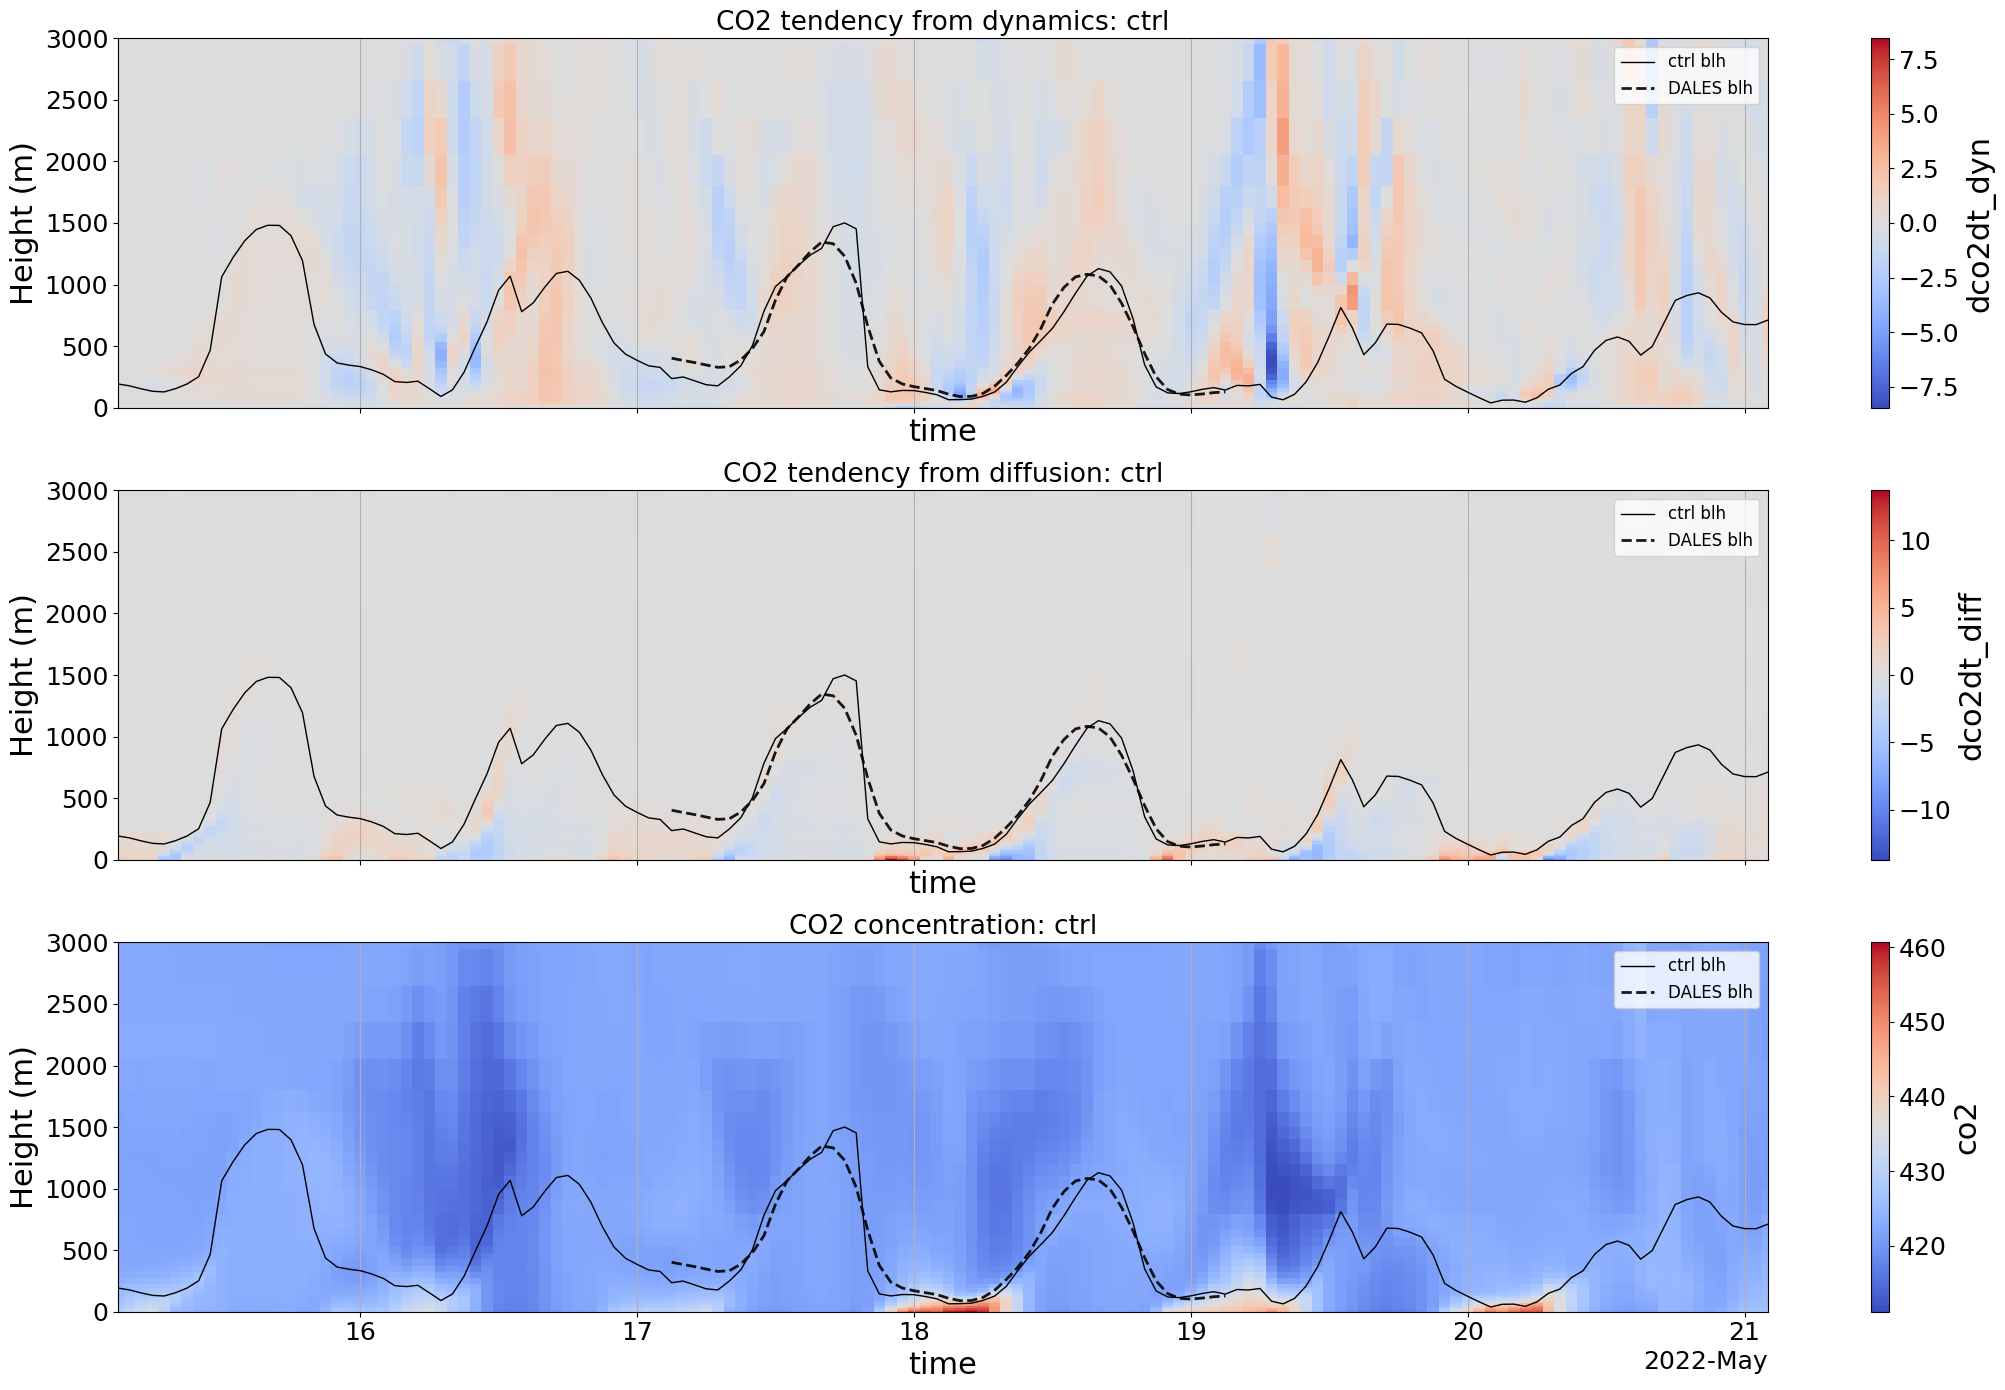

In [32]:
#####   3D fields of experiments  #####
##############################################
# Experiments to compare
exp = 'ctrl'
location ='cabauw'

# Variables to plot: (variable_name, plot title)
vars_to_plot = [
    ('dco2dt_dyn',  'CO2 tendency from dynamics'),
    # ('dco2dt_conv', 'CO2 tendency from convection'),
    ('dco2dt_diff', 'CO2 tendency from diffusion'),
    ('co2', 'CO2 concentration'),
    # ('clwc', 'cloud liquid water'),
    # ('T', 'Temperature'),
]

# Colormap limits (set to None for automatic scaling)
vmin = None
vmax = None

# Create a figure with rows equal to number of variables
fig, axes = plt.subplots(nrows=len(vars_to_plot), ncols=1, figsize=(22, len(vars_to_plot)*4+2), sharex=True)

# Make sure axes is always iterable
if len(vars_to_plot) == 1:
    axes = [axes]

# Loop through each variable
for ax, (var, title) in zip(axes, vars_to_plot):
    data = IFS[location]['z'][exp][var]
    # Plot 
    data.plot(
        ax=ax,
        y='height',
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax
    )

    # Add boundary layer height lines for both experiments
    IFS[location]['srf'][exp]['blh'].plot(ax=ax, x='time', c='k', lw=1, label=f'{exp} blh')
    # blh from DALES
    pblh.plot(ax=ax,x='time',label='DALES blh',lw=2,ls='--',c='k',alpha=0.9)

    # Formatting
    ax.set_ylim(0, 3000)
    ax.set_xlim(
        datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M"),
        datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")
    )
    ax.set_ylabel('Height (m)')
    ax.set_title(f'{title}: {exp}', fontsize=19)
    ax.legend()
    ax.grid(axis='x')

# Adjust layout for readability
plt.tight_layout()


Text(0.5, 1.0, 'CO2 flux from convection')

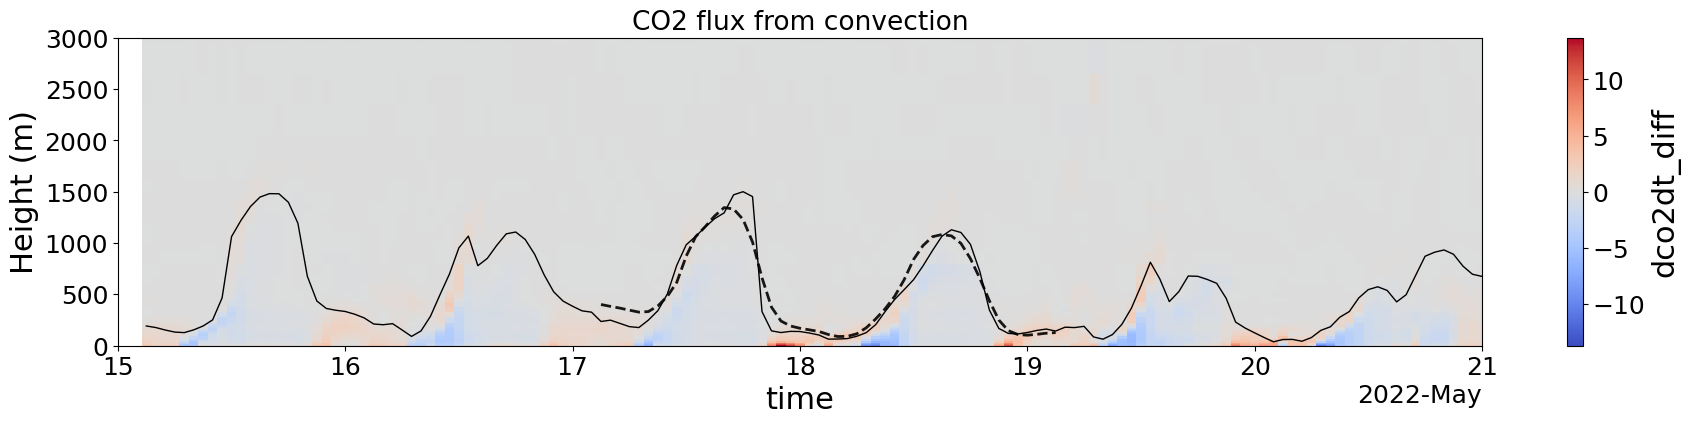

In [90]:

# var = 'co2' 
var = 'dco2dt_diff'
str_time = '2022-05-15'
end_time = '2022-05-21'
plt.figure(figsize=(22,4))
(IFS['cabauw']['z']['ctrl'][var]).plot( y='height',
                               cmap='coolwarm',
                # vmin=-3, vmax=3
                )
IFS['cabauw']['srf']['ctrl']['blh'].plot(x='time',c='k',lw=1)

# blh from DALES
pblh.plot(x='time',label='DALES',lw=2,ls='--',c='k',alpha=0.9)


plt.ylim((0,3000))
plt.xlim((datetime.datetime.strptime(str_time, "%Y-%m-%d"),datetime.datetime.strptime(end_time, "%Y-%m-%d")))
plt.ylabel('Height (m)')
# plt.title('CO2 concentration: dryMF - control',fontsize = 19)
plt.title('CO2 flux from convection',fontsize = 19)